In [1]:
import os, sys
sys.path.append(os.path.abspath(os.path.join("..")))
from src.data.chains import *
from src.models.heston import *
from src.models.dividends import *
import numpy as np
import pandas as pd
import QuantLib as ql
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data

## Inputs

In [2]:
# ---------- Universal Inputs ----------

TICKER          = "SPY"
MARKET_CAL      = "XNYS"
AS_OF           = '20251201'        # Date as 'YYYYMMDD'
 
# Options Data
N_EXP           = 15                # Number of expiries
N_LIQ_EXP       = 5                 # Number of liquid expiries
MIN_DAYS_TO_EXP = 7

# Dividends Data
START_DATE      = "2005-01-01"      # Date as 'YYYY-MM-DD'
N_RECENT        = 5

# ---------- Parameters ----------

MIN_TICK        = 0.01          # Equity options minimum tick
MIN_OI          = 10            # Minimum openInterest
AGE_HOURS       = 48            # Threshold to mark lastTradeDate as stale
MAX_SPREAD_BPS  = 75.0          # Maximum bid-ask spread width as basis points of mid: spread_bps = ((ask - bid) / mid) * 10000
TOL_MONEYNESS   = 0.005         # Maximum distance of a real contract from moneyness bin
TOL_DAYS        = 3             # Maximum distance of a real contract from tenor bin
LAMBDA_WING     = 0.5
CI_ALPHA        = 0.05

# Dividend Risk Premium Nelson-Siegel Curve Parameters (from literature)
BETA0_NS        = 0.03          # Long-run dividend risk premium
BETA1_NS        = 0.02          # Extra near-term premium
BETA2_NS        = 0.00          # Medium-term premium
LAMBDA_NS       = 1.0           # Rate of Decay
PREMIA_PARAMS   = NelsonSiegelParams(BETA0_NS, BETA1_NS, BETA2_NS, LAMBDA_NS)

# Heston Parameter Bounds
KAPPA_LB        = 0.05
KAPPA_UB        = 30.0
THETA_LB        = 1e-6
THETA_UB        = 2.0
SIGMA_LB        = 0.05
SIGMA_UB        = 5.00
RHO_LB          = -0.999
RHO_UB          = -1e-3
V0_LB           = 1e-6
V0_UB           = 1.0
PARAM_LB        = [KAPPA_LB, THETA_LB, SIGMA_LB, RHO_LB, V0_LB]
PARAM_UB        = [KAPPA_UB, THETA_UB, SIGMA_UB, RHO_UB, V0_UB]

## Load Raw Options Data

In [3]:
# ---------- Load Raw Options Data ----------

# Load raw option chains data from file
root_dir = os.path.abspath(os.path.join(".."))
data_dir = os.path.join(root_dir, "data", "options")
data_file = f"{TICKER}_{AS_OF}.csv"
data_path = os.path.join(data_dir, data_file)
raw_data = pd.read_csv(data_path)

# Subset to relevant expiries
chains_df = subset_expiries(raw_data, N_EXP, MIN_DAYS_TO_EXP)

# Spot & risk-free rate
S0 = float(chains_df["underlying"].iloc[-1])
r  = float(chains_df["rate"].iloc[-1])

# ---------- Basic Market Setup with QuantLib Objects ----------

# Evaluation date
date = pd.to_datetime(chains_df["date"].max()).tz_convert("UTC")
today = ql.Date(date.day, date.month, date.year)
ql.Settings.instance().evaluationDate = today
cal = ql.UnitedStates(ql.UnitedStates.NYSE)
day_counter = ql.Actual365Fixed()

# Spot & risk-free & QuantLib handles
S_quote = ql.QuoteHandle(ql.SimpleQuote(S0))
r_curve = ql.YieldTermStructureHandle(ql.FlatForward(today, r, day_counter, ql.Continuous, ql.Annual))

## Estimate Dividend Yield Term Structure

$\large{\text{Implied Price-Dividend Ratio from Nelson–Siegel Curves:}}$

$$ \frac{S_t}{D_0} = \Sigma_{n = 1}^{N} \, \text{exp} \left\{ \Sigma_{i = 1}^{n} (g_i - y_i + \theta_{i}) \right\}$$

* $g_i$: Expected dividend growth for year $i$.

* $y_i$: Risk-free zero-rate at tenor $i$.

* $\theta_{i}$: Dividend risk premium at tenor $i$.

$\large{\text{Nelson–Siegel Curve for Dividend Risk Premium Term Structure:}}$

$$ \theta(T) = \beta_0 + \beta_1 \cdot \frac{1 - e^{-\lambda \, T}}{\lambda \, T} + \beta_2 \left(\frac{1 - e^{-\lambda \, T}}{\lambda \, T} - e^{-\lambda \, T}\right) $$

* $\beta_0$: Long-run dividend risk premium.

* $\beta_1$: Short-term dividend risk premium (additional premium at short maturities, which gradually decays as maturity increases).

* $\beta_2$: Medium-term dividend risk premium.

* $\lambda$: Speed of decay.

$\large{\text{Nelson–Siegel Curve for Growth Term Structure:}}$

$$ g(T) = \beta_0 + \beta_1 \, x(T) + \beta_2 \, (x(T) - e^{-\lambda \, T})$$

Fit Growth Parameters via Least-Squares:

* **Price-Dividend Ratio Match:** $log(\text{PD}_\text{model}) = log(\text{PD}_\text{obs})$

* **Long-Run Growth Match:** Average of $g(T)$ over some horizon matches historical dividend growth.

* **Short-Run Growth Match:** Average of $g(T)$ over near-term horizon matches recent historical dividend growth.

In [4]:
# ---------- Pull Dividends Data ----------

yearly_div, yearly_growth, g_bar, g_recent =  get_dividends_data(TICKER, START_DATE, N_RECENT)

# Observed price–dividend ratio using last full-year dividend
D0_obs = float(yearly_div.iloc[-1])
pd_ratio_obs = S0 / D0_obs

# ---------- Fit Growth Nelson-Siegel Curve ----------

# Growth Nelson-Siegel Curve Parameter Seeds
BETA0_SEED      = float(g_bar)
BETA1_SEED      = float(g_recent - g_bar) 
BETA2_SEED      = 0.0 
LAMBDA_SEED     = 0.7
NS_GROWTH_SEEDS = [BETA0_SEED, BETA1_SEED, BETA2_SEED, LAMBDA_SEED]

growth_params_fitted = fit_ns_growth(g_bar, g_recent, pd_ratio_obs, r_curve, PREMIA_PARAMS, NS_GROWTH_SEEDS)
div_model = DividendNSModel(growth_params = growth_params_fitted, premia_params = PREMIA_PARAMS)
q_curve = build_dividend_yield_curve(today, cal, day_counter, r_curve, div_model)
chains_df = compute_div_yield_from_ts(chains_df, q_curve, day_counter)

## Clean Data

In [5]:
# ---------- Clean Data ----------

# Drop bad quotes
chains_df = clean_data(chains_df, MIN_TICK, MIN_OI, AGE_HOURS)
chains_df = most_liquid_quotes(chains_df)

# Exclude ITM Options
chains_df["type"] = chains_df["type"].astype(str).str.lower()
chains_df.loc[chains_df["type"].str.startswith("c"), "type"] = "call"
chains_df.loc[chains_df["type"].str.startswith("p"), "type"] = "put"
chains_df = chains_df[((chains_df["type"] == "call") & (chains_df["strike"] >= S0)) | 
                      ((chains_df["type"] == "put") & (chains_df["strike"] <= S0))]

# Time to maturity as year fraction (Actual/365)
if "T" not in chains_df.columns:
    chains_df["T"] = (pd.to_datetime(chains_df["expiry"]) - pd.to_datetime(chains_df["date"])).dt.days.clip(lower = 0).astype(float) / 365.0

# Days to maturity
if "T_days" not in chains_df.columns:
    chains_df["T_days"] = (pd.to_datetime(chains_df["expiry"]) - pd.to_datetime(chains_df["date"])).dt.days.clip(lower = 0).astype(int)
    # T_days = int(max(1, (pd.to_datetime(df_row["expiry"]) - pd.to_datetime(df_row["date"])).days))
chains_df["trading_days_to_exp"] = chains_df.apply(compute_trading_days_to_exp, axis=1)

# Forward price
if "F" not in chains_df.columns:
    chains_df["F"] = chains_df["underlying"] * np.exp((chains_df["rate"] - chains_df["div_yield"]) * chains_df["T"])

# Spot moneyness & log-moneyness
chains_df["moneyness_spot"] = chains_df["strike"] / chains_df["underlying"]
chains_df["log_moneyness_spot"] = np.log(chains_df["moneyness_spot"])

# Forward moneyness & log-moneyness
chains_df["moneyness_fwd"] = chains_df["strike"] / chains_df["F"]
chains_df["log_moneyness_fwd"] = np.log(chains_df["moneyness_fwd"])

# Keep only quotes ~ATM
chains_df = chains_df[(chains_df["moneyness_spot"] >= 0.8) & (chains_df["moneyness_spot"] <= 1.2)]

# ---------- Subsets ----------

# All Expiries
all_chains = chains_df.copy()
all_calls = chains_df[chains_df["type"] == "call"]
all_puts = chains_df[chains_df["type"] == "put"]

# Single Expiry (2026-01-16)
EXPIRY = "2026-01-16 00:00:00+00:00"
chains_single_exp = chains_df[chains_df["expiry"] == EXPIRY]
calls_single_exp = chains_single_exp[chains_single_exp["type"] == "call"]
puts_single_exp = chains_single_exp[chains_single_exp["type"] == "put"]

# Most Liquid Expiries
liq_chains_df = select_most_liquid_expiries(chains_df, N_LIQ_EXP)
liq_calls_df = select_most_liquid_expiries(all_calls, N_LIQ_EXP)
liq_puts_df = select_most_liquid_expiries(all_puts, N_LIQ_EXP)
most_liquid_expiries = liq_chains_df["expiry"].unique().tolist()
most_liquid_call_expiries = liq_calls_df["expiry"].unique().tolist()
most_liquid_put_expiries = liq_puts_df["expiry"].unique().tolist()

# Simulate Heston SDE Dynamics

$\Large{\text{Heston SDE Dynamics:}}$

$$
\begin{aligned}
    dS_t &= (r - q) S_t \, dt + \sqrt{v_t} \, S_t \, dW_t^{(S)} \\
    dv_t &= \kappa \left( \theta- v_t \right) dt + \sigma \, \sqrt{v_t} \, dW_t^{(v)} \\
    dW_t^{(S)} \, dW_t^{(v)} &= \rho \, dt \\
\end{aligned}
$$

**Parameter set:** 

* $v_{0}$: Initial variance ($t = 0$).

* $\theta$: Long-run average variance of the price.

* $\kappa$: The rate at which $v_t$ reverts to $\theta$.

* $\sigma$: Volatility of volatility (variance of $v_t$).

* $\rho$: Correlation of the Weiner processes $W_t^{(S)}$, $W_t^{(v)}$.

$\large{\text{Calibration Weighting:}}$

Since not all quotes are equally trustworthy (e.g. options with tight bid-ask spreads are more reliable than illliquid ones, far OTM/ITM options may be more noisy than near-ATM options), we apply the following per-point weights to ensure that less reliable quotes don't overpower or distort the model calibration: 

$$w_i = w_i^{\text{IV}} \cdot w_i^{\text{wing}} = \frac{\exp{(-\lambda \left| k_i \right|)}}{(\Delta \sigma_i)^2}$$

**Inverse-IV-Variance Weights:** $\hspace{5pt} w_i^{\text{IV}} = \frac{1}{(\Delta \sigma_i)^2}$, $\hspace{5pt} \Delta \sigma_i \approx \frac{(\text{bid} - \text{ask})/2}{\text{vega}}$

* Tight Spread $\to$ Low Variance $\to$ High Weight
* Wide Spread $\to$ High Variance $\to$ Low Weight

**Wing Damping Weights:** $\hspace{5pt} w_i^{\text{wing}} = \exp{(-\lambda \left| k_i \right|)}$, $\hspace{5pt} k_i = \ln(K_i/F_i)$

* Down-weight options far from forward, which usually have noisy quotes and very low vega.

**Per-Expiry Normalization:** $\hspace{5pt} \Sigma_{j \in \text{expiry}}w_j^{\text{norm}} = 1$


## Single Expiry Calls (2026-01-16)

### Calibrate Heston

In [ ]:
# ---------- Input Arguments ----------

option_chain_df = calls_single_exp
NUM_EXPIRIES = 1
OPTION_TYPE = "c"

# ---------- Calibrate Heston ----------

# Compute Option Greeks
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)
option_chain_df = compute_greeks_and_bs_price(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve)

# Calibration weighting
option_chain_df = calibration_weighting(option_chain_df, LAMBDA_WING)
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)

# Initial Heston Parameter Seeds
atm_option_chain_df = option_chain_df[(option_chain_df["moneyness_spot"] >= 0.95) & 
                                      (option_chain_df["moneyness_spot"] <= 1.05)].copy()
atm_iv  = float(atm_option_chain_df["iv_mkt"].median())

KAPPA_SEED  = 2.0                               # [0.05, 30]
THETA_SEED  = max(1e-4, (atm_iv * 1.1) ** 2)    # [1e-6, 2]
SIGMA_SEED  = 0.5                               # [0.05, 5.00]
RHO_SEED    = -0.5                              # [-0.999, -1e-3]
V0_SEED     = max(1e-4, atm_iv ** 2)            # [1e-6, 1.0]
HESTON_PARAM_SEEDS = [KAPPA_SEED, THETA_SEED, SIGMA_SEED, RHO_SEED, V0_SEED]

# Fit Heston Model
heston_params, params_ci, std_errors = fit_heston_ls(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve, 
                                                     HESTON_PARAM_SEEDS, PARAM_LB, PARAM_UB, CI_ALPHA) 
kappa, theta, sigma, rho, v0 = heston_params
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()

# Compute Model Prices & IV
option_chain_df = compute_model_prices_and_ivs(option_chain_df, heston_pricing_engine, today, S_quote, r_curve, q_curve)
option_chain_df = compute_residuals(option_chain_df)
rmse_price = compute_price_rmse(option_chain_df) 

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f},   \n          [{float(params_ci["kappa"][0]):.4f}, {float(params_ci["kappa"][1]):.4f}]")
print(f"  theta = {float(theta):.8f},   \n          [{float(params_ci["theta"][0]):.4f}, {float(params_ci["theta"][1]):.4f}]")
print(f"  sigma = {float(sigma):.8f},   \n          [{float(params_ci["sigma"][0]):.4f}, {float(params_ci["sigma"][1]):.4f}]")
print(f"  rho   = {float(rho):.8f},     \n          [{float(params_ci["rho"][0]):.4f}, {float(params_ci["rho"][1]):.4f}]")
print(f"  v0    = {float(v0):.8f},      \n          [{float(params_ci["v0"][0]):.4f}, {float(params_ci["v0"][1]):.4f}]")
print(f"\nPrice RMSE: {float(rmse_price):.8f}")
print(f"Mean Option Price: {float(np.nanmean(option_chain_df["mid"])):.8f}")

Calibrated Heston Parameters:
  kappa = 25.64894009,   
          [-1648.8714, 1700.1693]
  theta = 0.04273163,   
          [-2.6262, 2.7117]
  sigma = 2.67097188,   
          [-168.8720, 174.2140]
  rho   = -0.64337018,     
          [-0.7876, -0.4991]
  v0    = 0.00257061,      
          [-8.3478, 8.3529]

Price RMSE: 0.01947256
Mean Option Price: 2.09833333


#### Plots

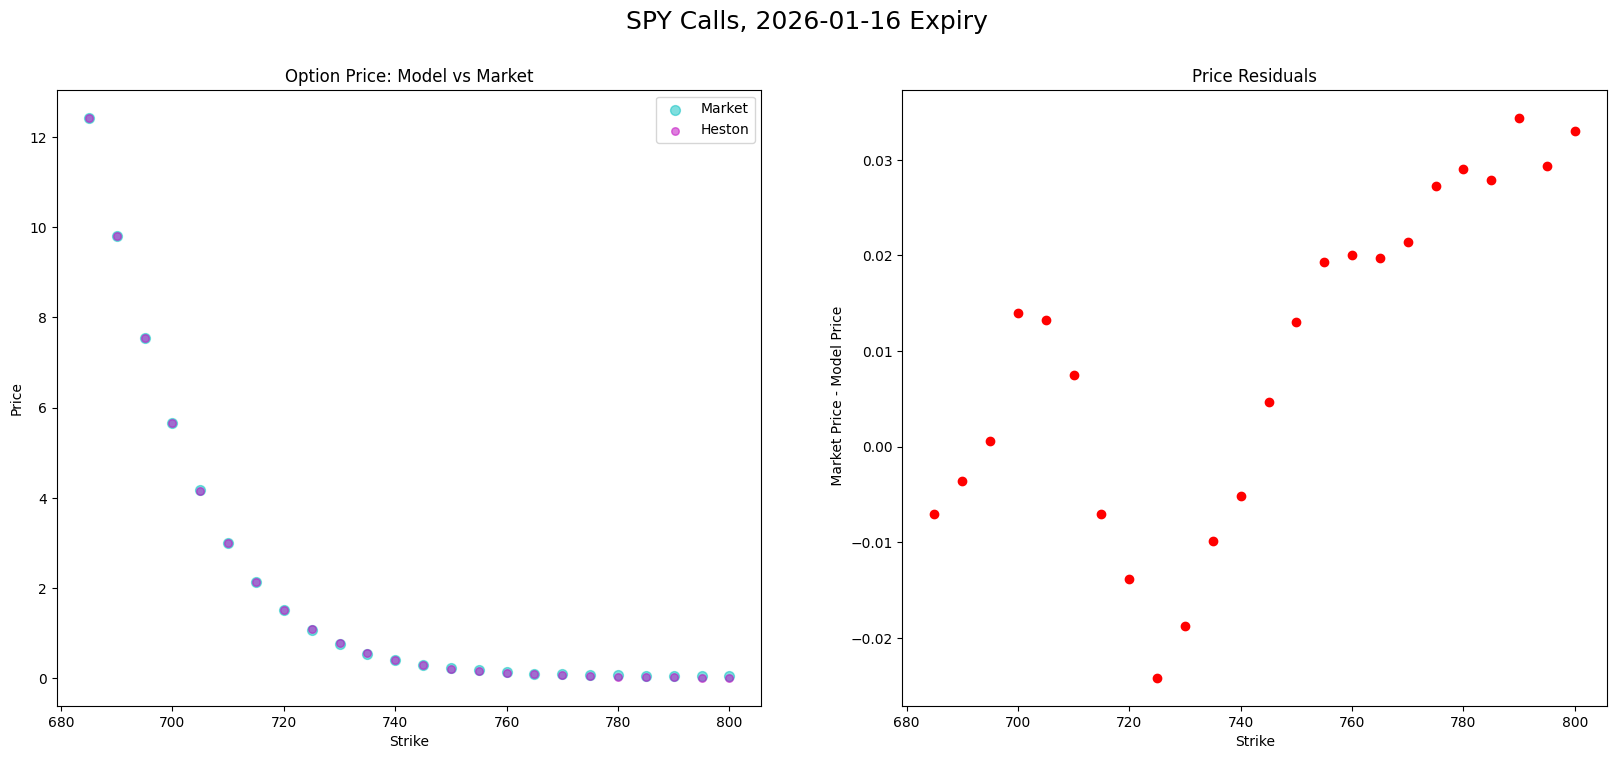

In [ ]:
plot_model_prices(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE, EXPIRY)

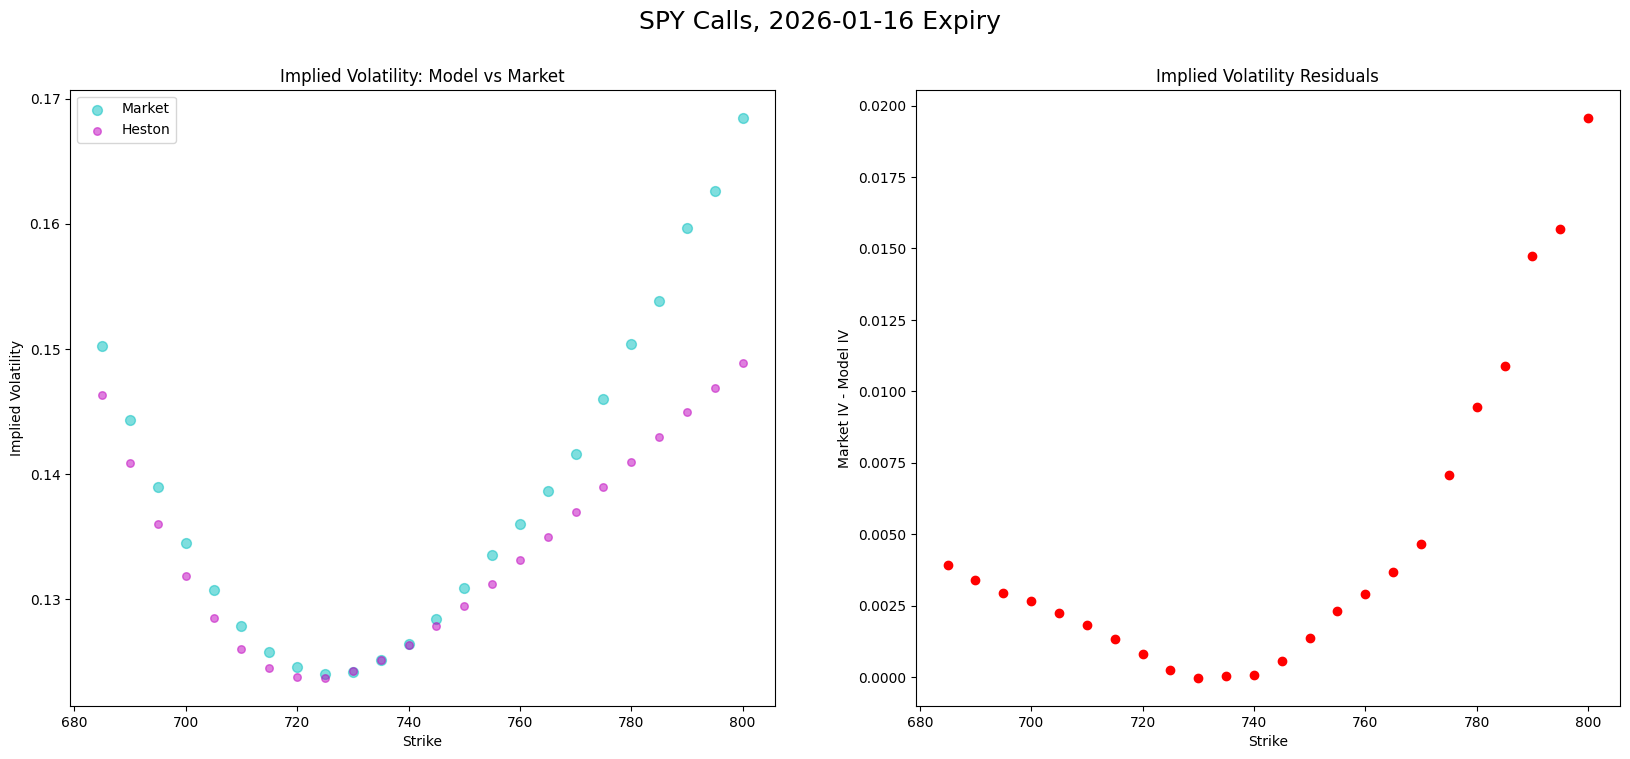

In [ ]:
plot_model_iv(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE, EXPIRY)

### Simulate Volatility Paths

In [ ]:
# ---------- Simulate Volatility Paths from Calibrated Heston ----------

# Simulation horizon
T_sim = float(option_chain_df["T"].max())

# Trading days to expiry
trading_days_to_exp = int(option_chain_df["trading_days_to_exp"].max())

# Monte Carlo settings
N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
N_PATHS_MC = 10000                              # number of simulated paths

# Simulate under today’s calibrated risk-neutral Heston dynamics
time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
vol_paths = np.sqrt(v_paths)

# Simulated spot prices and instantaneous vol at maturity
S_T = S_paths[:, -1]
sigma_T = vol_paths[:, -1]

# Distribution of future spot prices at maturity
S_T_mean = S_T.mean()
S_T_p05  = np.percentile(S_T, 5)
S_T_p95  = np.percentile(S_T, 95)

# Distribution of instantaneous vol at maturity
sigma_T_mean = sigma_T.mean()
sigma_T_p05  = np.percentile(sigma_T, 5)
sigma_T_p95  = np.percentile(sigma_T, 95)

# ---------- Monte Carlo Option Price Estimates & CI ----------

option_chain_df = est_mc_option_prices(option_chain_df, S_T, T_sim, r_curve, N_PATHS_MC, 1 - CI_ALPHA)

# ---------- 5%–95% Quantile Bands for Simulated Paths ----------

# Spot price paths
S_path_p05 = np.percentile(S_paths, 5, axis = 0)
S_path_p50 = np.percentile(S_paths, 50, axis = 0)
S_path_p95 = np.percentile(S_paths, 95, axis = 0)
S_path_quantiles = (S_path_p05, S_path_p50, S_path_p95)

# Variance paths
v_path_p05 = np.percentile(v_paths, 5, axis = 0)
v_path_p50 = np.percentile(v_paths, 50, axis = 0)
v_path_p95 = np.percentile(v_paths, 95, axis = 0)
v_path_quantiles = (v_path_p05, v_path_p50, v_path_p95)

# Volatility paths
vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)
vol_path_quantiles = (vol_path_p05, vol_path_p50, vol_path_p95)

#### Plots

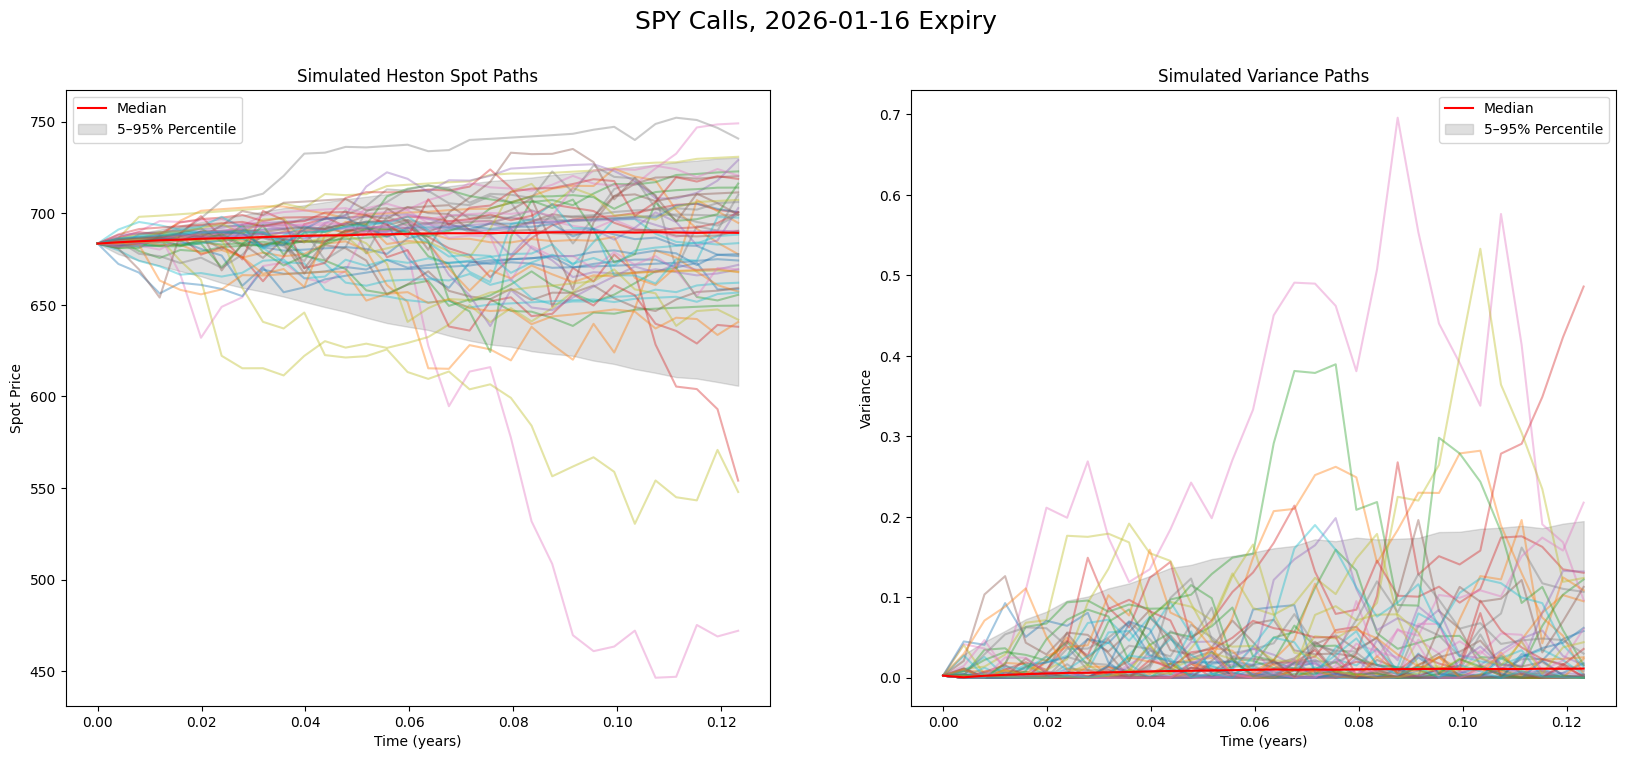

In [10]:
plot_sim_paths(time_grid, S_paths, v_paths, S_path_quantiles, v_path_quantiles, TICKER, EXPIRY, OPTION_TYPE)

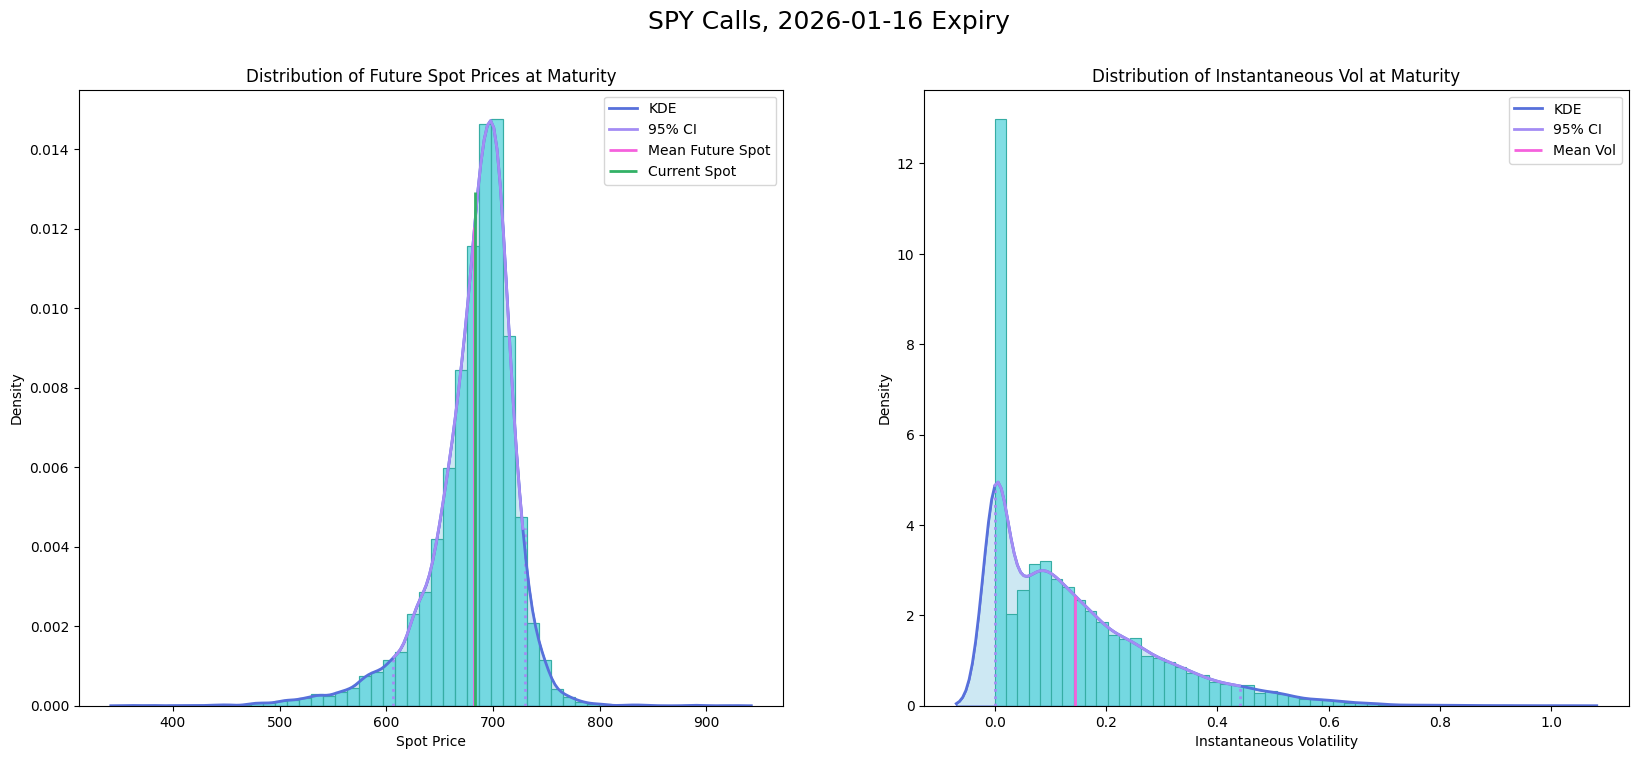

In [11]:
plot_distr_at_maturity(S_T, sigma_T, S0, TICKER, EXPIRY, OPTION_TYPE)

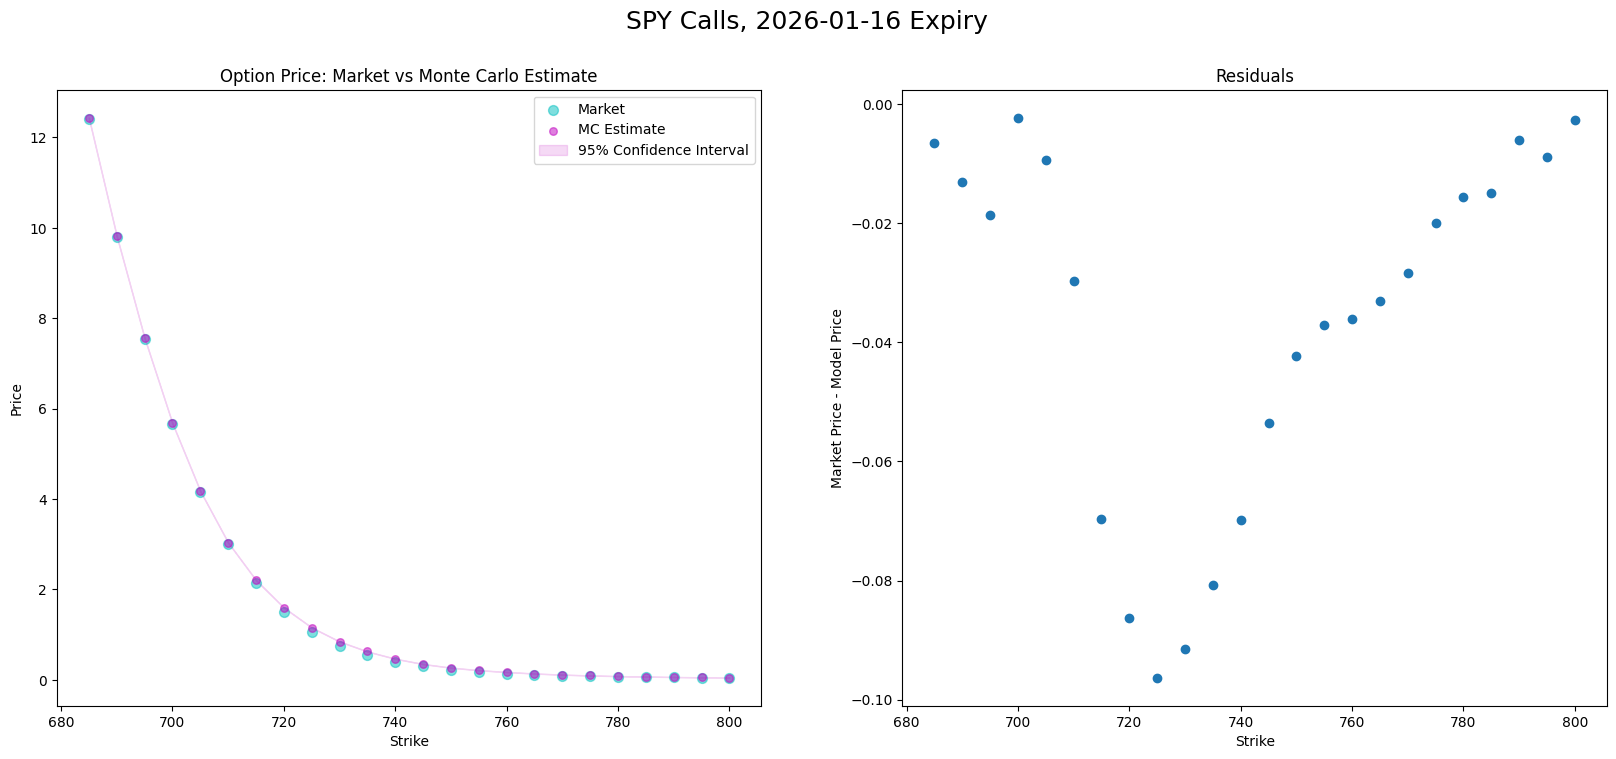

In [ ]:
plot_mc_est_prices(option_chain_df, TICKER, EXPIRY, OPTION_TYPE)

## Single Expiry Puts (2026-01-16)

### Calibrate Heston

In [ ]:
# ---------- Input Arguments ----------

option_chain_df = puts_single_exp
NUM_EXPIRIES = 1
OPTION_TYPE = "p"

# ---------- Calibrate Heston ----------

# Compute Option Greeks
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)
option_chain_df = compute_greeks_and_bs_price(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve)

# Calibration weighting
option_chain_df = calibration_weighting(option_chain_df, LAMBDA_WING)
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)

# Initial Heston Parameter Seeds
atm_option_chain_df = option_chain_df[(option_chain_df["moneyness_spot"] >= 0.95) & 
                                      (option_chain_df["moneyness_spot"] <= 1.05)].copy()
atm_iv  = float(atm_option_chain_df["iv_mkt"].median())

KAPPA_SEED  = 2.0                               # [0.05, 30]
THETA_SEED  = max(1e-4, (atm_iv * 1.1) ** 2)    # [1e-6, 2]
SIGMA_SEED  = 0.5                               # [0.05, 5.00]
RHO_SEED    = -0.5                              # [-0.999, -1e-3]
V0_SEED     = max(1e-4, atm_iv ** 2)            # [1e-6, 1.0]
HESTON_PARAM_SEEDS = [KAPPA_SEED, THETA_SEED, SIGMA_SEED, RHO_SEED, V0_SEED]

# Fit Heston Model
heston_params, params_ci, std_errors = fit_heston_ls(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve, 
                                                     HESTON_PARAM_SEEDS, PARAM_LB, PARAM_UB, CI_ALPHA) 
kappa, theta, sigma, rho, v0 = heston_params
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()

# Compute Model Prices & IV
option_chain_df = compute_model_prices_and_ivs(option_chain_df, heston_pricing_engine, today, S_quote, r_curve, q_curve)
option_chain_df = compute_residuals(option_chain_df)
rmse_price = compute_price_rmse(option_chain_df) 

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f},   \n          [{float(params_ci["kappa"][0]):.4f}, {float(params_ci["kappa"][1]):.4f}]")
print(f"  theta = {float(theta):.8f},   \n          [{float(params_ci["theta"][0]):.4f}, {float(params_ci["theta"][1]):.4f}]")
print(f"  sigma = {float(sigma):.8f},   \n          [{float(params_ci["sigma"][0]):.4f}, {float(params_ci["sigma"][1]):.4f}]")
print(f"  rho   = {float(rho):.8f},     \n          [{float(params_ci["rho"][0]):.4f}, {float(params_ci["rho"][1]):.4f}]")
print(f"  v0    = {float(v0):.8f},      \n          [{float(params_ci["v0"][0]):.4f}, {float(params_ci["v0"][1]):.4f}]")
print(f"\nPrice RMSE: {float(rmse_price):.8f}")
print(f"Mean Option Price: {float(np.nanmean(option_chain_df["mid"])):.8f}")

Calibrated Heston Parameters:
  kappa = 29.99999973,   
          [-104.0314, 164.0314]
  theta = 0.03206006,   
          [-2.5852, 2.6493]
  sigma = 4.90532475,   
          [-74.4076, 84.2183]
  rho   = -0.26082764,     
          [-0.3907, -0.1310]
  v0    = 0.04938359,      
          [-7.1871, 7.2859]

Price RMSE: 0.06709494
Mean Option Price: 3.96962963


#### Plots

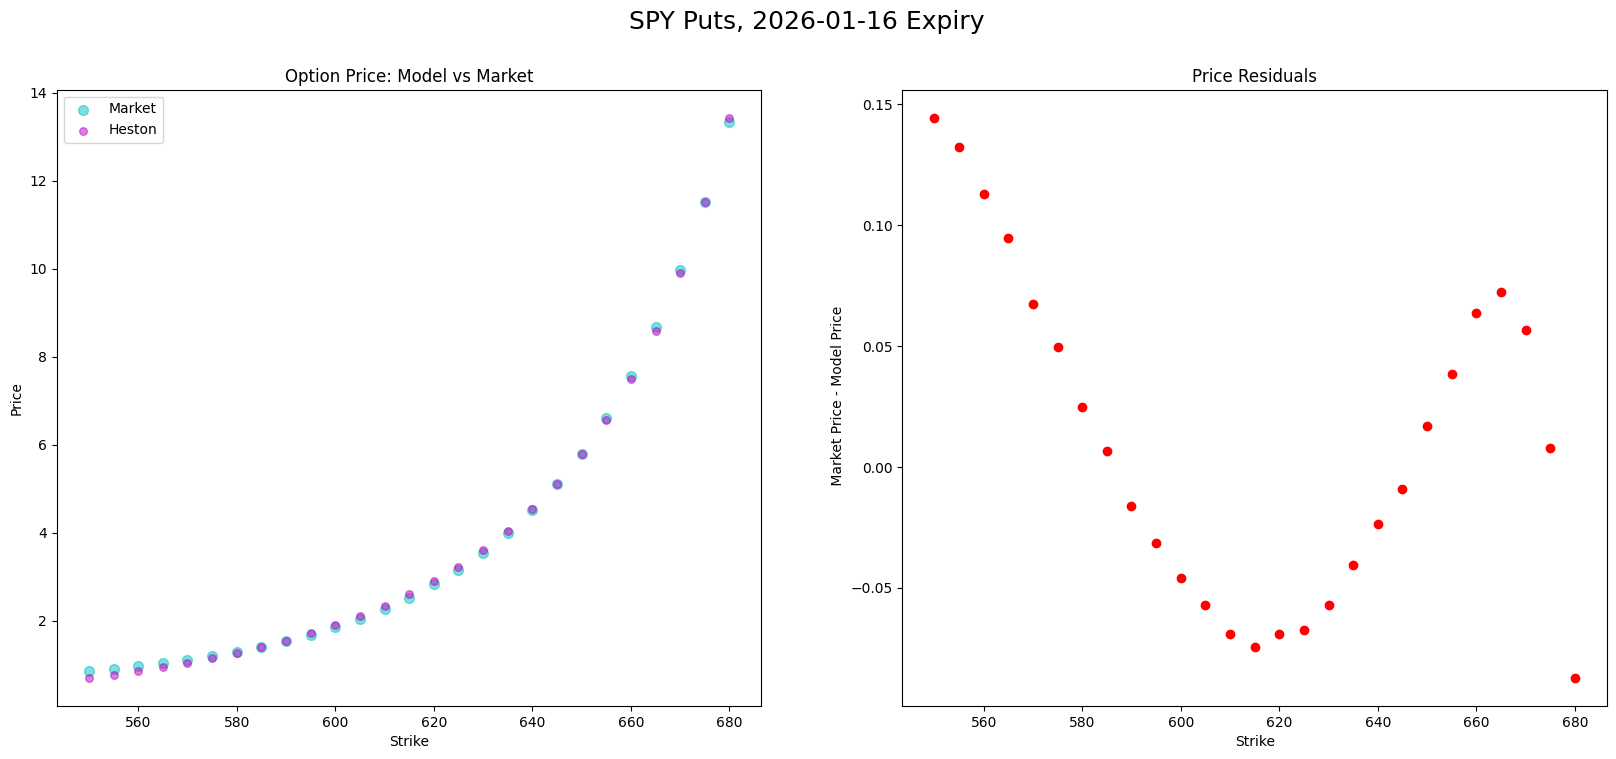

In [ ]:
plot_model_prices(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE, EXPIRY)

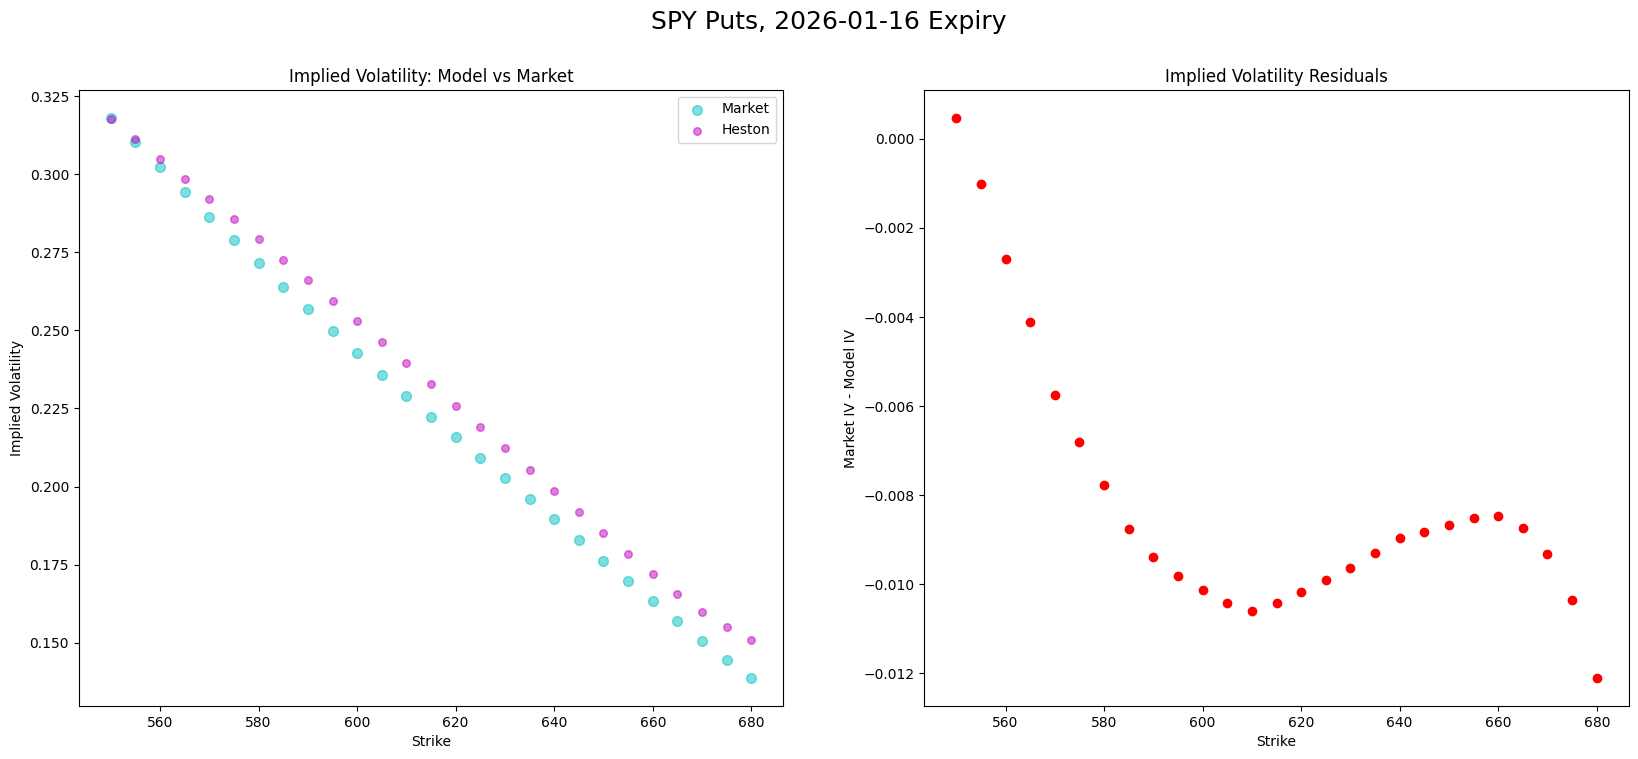

In [ ]:
plot_model_iv(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE, EXPIRY)

### Simulate Volatility Paths

In [ ]:
# ---------- Simulate Volatility Paths from Calibrated Heston ----------

# Simulation horizon
T_sim = float(option_chain_df["T"].max())

# Trading days to expiry
trading_days_to_exp = int(option_chain_df["trading_days_to_exp"].max())

# Monte Carlo settings
N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
N_PATHS_MC = 10000                              # number of simulated paths

# Simulate under today’s calibrated risk-neutral Heston dynamics
time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
vol_paths = np.sqrt(v_paths)

# Simulated spot prices and instantaneous vol at maturity
S_T = S_paths[:, -1]
sigma_T = vol_paths[:, -1]

# Distribution of future spot prices at maturity
S_T_mean = S_T.mean()
S_T_p05  = np.percentile(S_T, 5)
S_T_p95  = np.percentile(S_T, 95)

# Distribution of instantaneous vol at maturity
sigma_T_mean = sigma_T.mean()
sigma_T_p05  = np.percentile(sigma_T, 5)
sigma_T_p95  = np.percentile(sigma_T, 95)

# ---------- Monte Carlo Option Price Estimates & CI ----------

option_chain_df = est_mc_option_prices(option_chain_df, S_T, T_sim, r_curve, N_PATHS_MC, 1 - CI_ALPHA)

# ---------- 5%–95% Quantile Bands for Simulated Paths ----------

# Spot price paths
S_path_p05 = np.percentile(S_paths, 5, axis = 0)
S_path_p50 = np.percentile(S_paths, 50, axis = 0)
S_path_p95 = np.percentile(S_paths, 95, axis = 0)
S_path_quantiles = (S_path_p05, S_path_p50, S_path_p95)

# Variance paths
v_path_p05 = np.percentile(v_paths, 5, axis = 0)
v_path_p50 = np.percentile(v_paths, 50, axis = 0)
v_path_p95 = np.percentile(v_paths, 95, axis = 0)
v_path_quantiles = (v_path_p05, v_path_p50, v_path_p95)

# Volatility paths
vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)
vol_path_quantiles = (vol_path_p05, vol_path_p50, vol_path_p95)

#### Plots

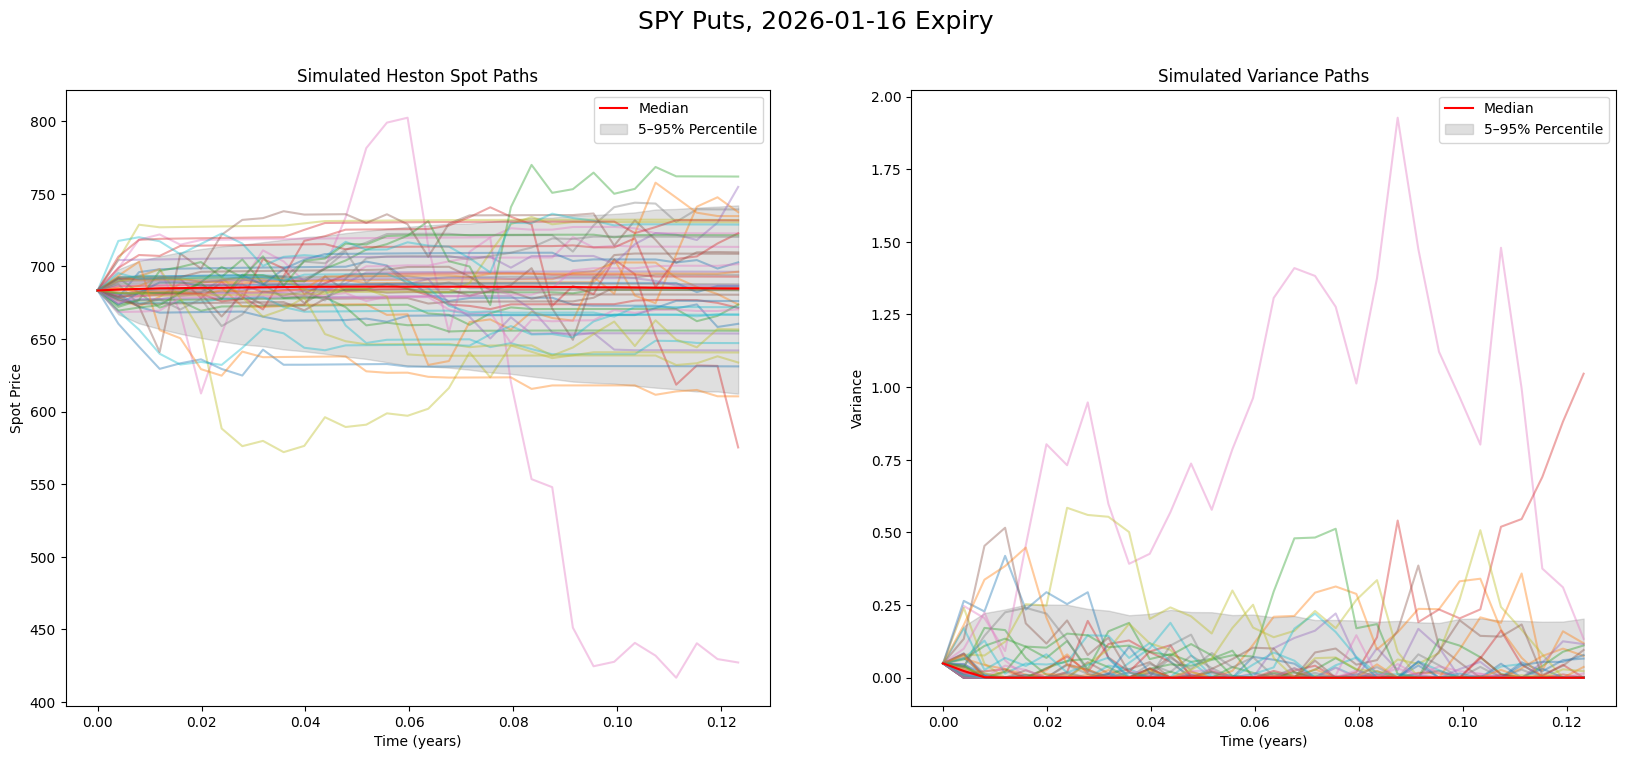

In [17]:
plot_sim_paths(time_grid, S_paths, v_paths, S_path_quantiles, v_path_quantiles, TICKER, EXPIRY, OPTION_TYPE)

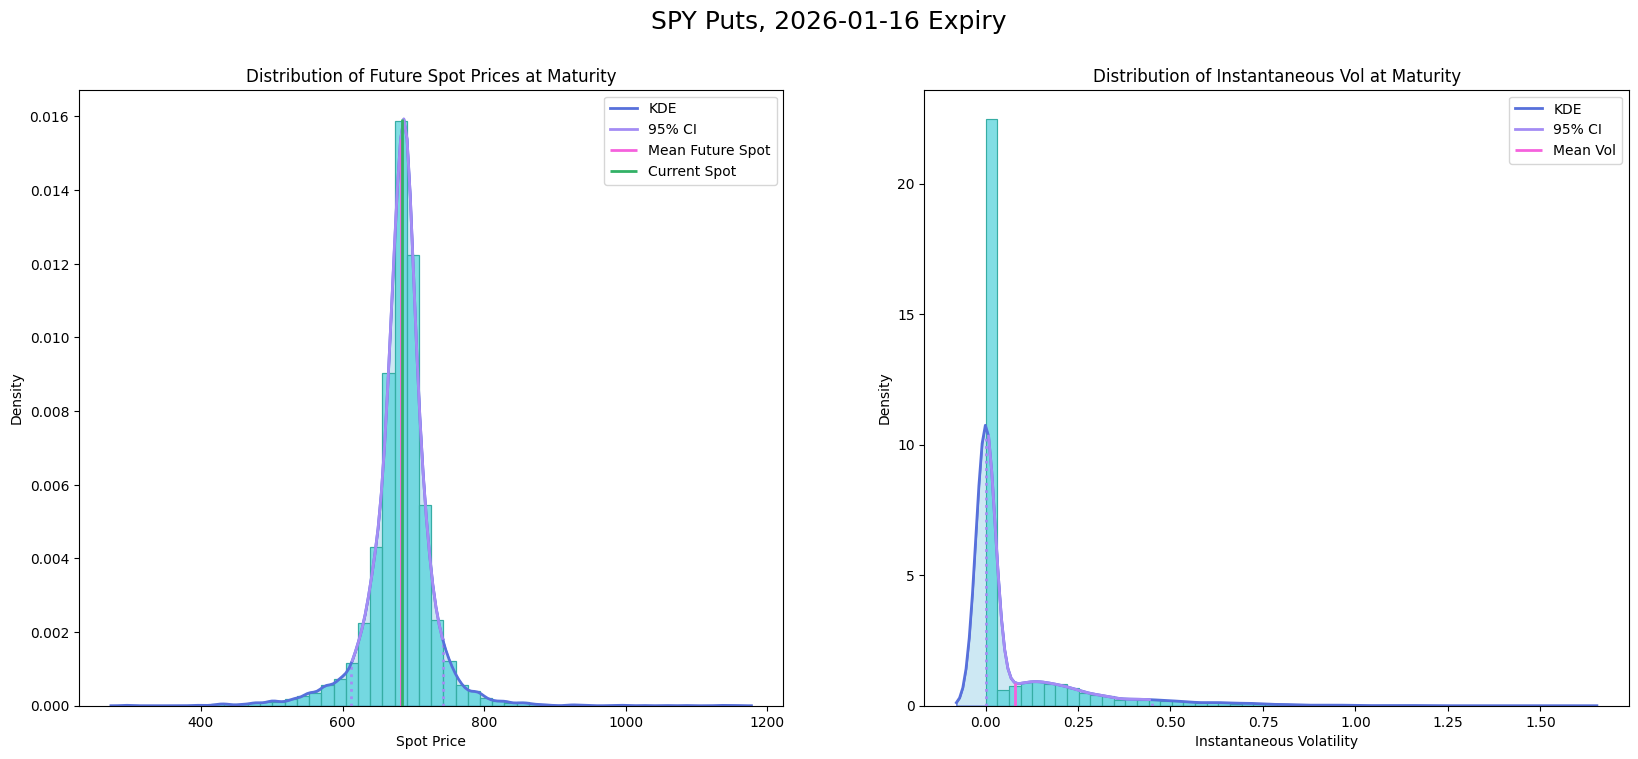

In [18]:
plot_distr_at_maturity(S_T, sigma_T, S0, TICKER, EXPIRY, OPTION_TYPE)

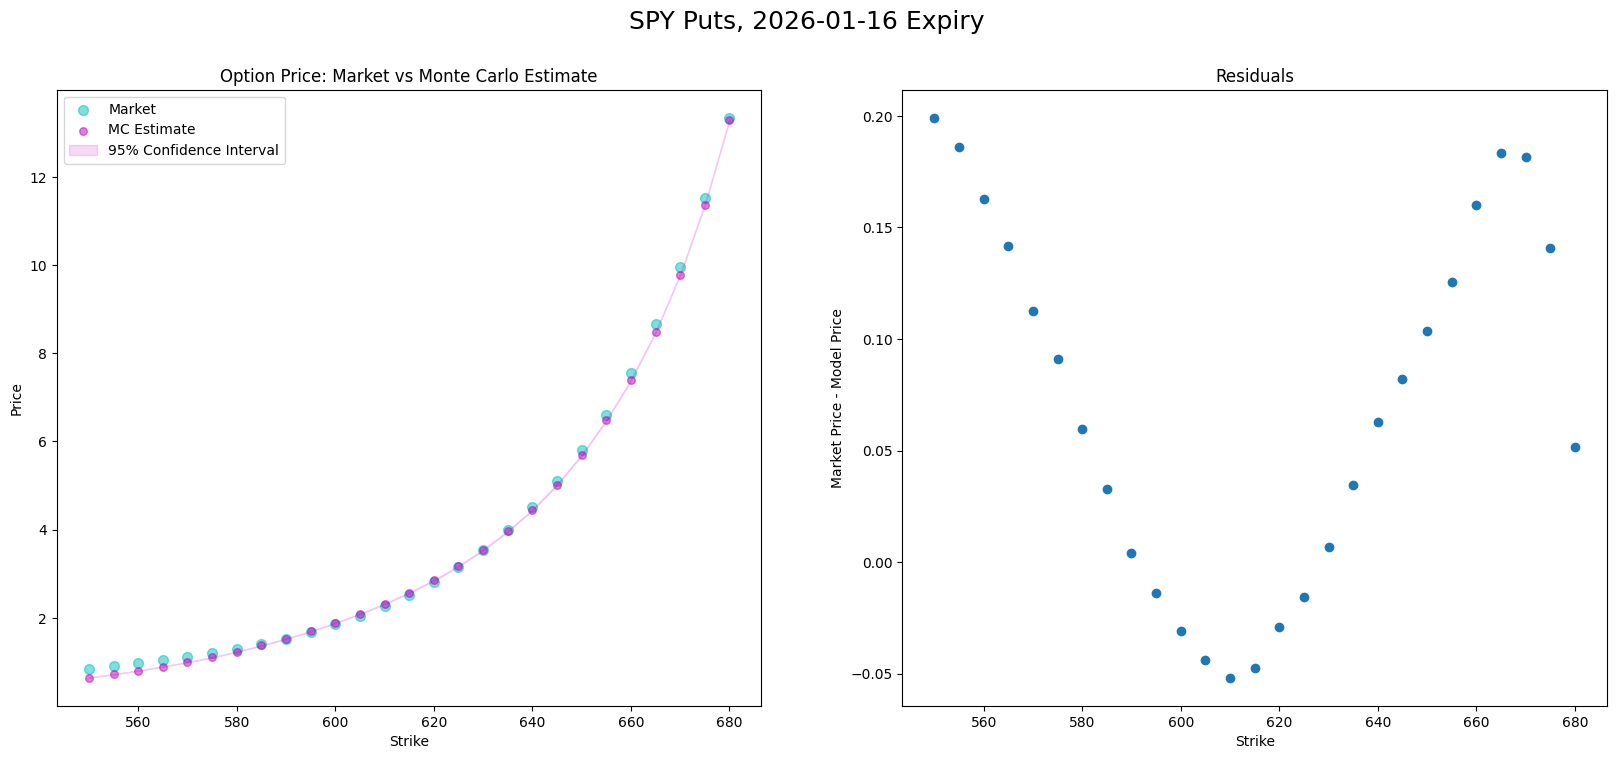

In [ ]:
plot_mc_est_prices(option_chain_df, TICKER, EXPIRY, OPTION_TYPE)

## Single Expiry Options (2026-01-16)

### Calibrate Heston

In [ ]:
# ---------- Input Arguments ----------

option_chain_df = chains_single_exp
NUM_EXPIRIES = 1
OPTION_TYPE = None

# ---------- Calibrate Heston ----------

# Compute Option Greeks
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)
option_chain_df = compute_greeks_and_bs_price(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve)

# Calibration weighting
option_chain_df = calibration_weighting(option_chain_df, LAMBDA_WING)
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)

# Initial Heston Parameter Seeds
atm_option_chain_df = option_chain_df[(option_chain_df["moneyness_spot"] >= 0.95) & 
                                      (option_chain_df["moneyness_spot"] <= 1.05)].copy()
atm_iv  = float(atm_option_chain_df["iv_mkt"].median())

KAPPA_SEED  = 2.0                               # [0.05, 30]
THETA_SEED  = max(1e-4, (atm_iv * 1.1) ** 2)    # [1e-6, 2]
SIGMA_SEED  = 0.5                               # [0.05, 5.00]
RHO_SEED    = -0.5                              # [-0.999, -1e-3]
V0_SEED     = max(1e-4, atm_iv ** 2)            # [1e-6, 1.0]
HESTON_PARAM_SEEDS = [KAPPA_SEED, THETA_SEED, SIGMA_SEED, RHO_SEED, V0_SEED]

# Fit Heston Model
heston_params, params_ci, std_errors = fit_heston_ls(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve, 
                                                     HESTON_PARAM_SEEDS, PARAM_LB, PARAM_UB, CI_ALPHA) 
kappa, theta, sigma, rho, v0 = heston_params
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()

# Compute Model Prices & IV
option_chain_df = compute_model_prices_and_ivs(option_chain_df, heston_pricing_engine, today, S_quote, r_curve, q_curve)
option_chain_df = compute_residuals(option_chain_df)
rmse_price = compute_price_rmse(option_chain_df) 

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f},   \n          [{float(params_ci["kappa"][0]):.4f}, {float(params_ci["kappa"][1]):.4f}]")
print(f"  theta = {float(theta):.8f},   \n          [{float(params_ci["theta"][0]):.4f}, {float(params_ci["theta"][1]):.4f}]")
print(f"  sigma = {float(sigma):.8f},   \n          [{float(params_ci["sigma"][0]):.4f}, {float(params_ci["sigma"][1]):.4f}]")
print(f"  rho   = {float(rho):.8f},     \n          [{float(params_ci["rho"][0]):.4f}, {float(params_ci["rho"][1]):.4f}]")
print(f"  v0    = {float(v0):.8f},      \n          [{float(params_ci["v0"][0]):.4f}, {float(params_ci["v0"][1]):.4f}]")
print(f"\nPrice RMSE: {float(rmse_price):.8f}")
print(f"Mean Option Price: {float(np.nanmean(option_chain_df["mid"])):.8f}")

Calibrated Heston Parameters:
  kappa = 29.99994354,   
          [-17.2678, 77.2677]
  theta = 0.02099342,   
          [-0.2179, 0.2599]
  sigma = 2.84613156,   
          [-3.3688, 9.0610]
  rho   = -0.59535185,     
          [-0.7057, -0.4850]
  v0    = 0.05765501,      
          [-0.6020, 0.7173]

Price RMSE: 0.12790763
Mean Option Price: 3.08901961


#### Plots

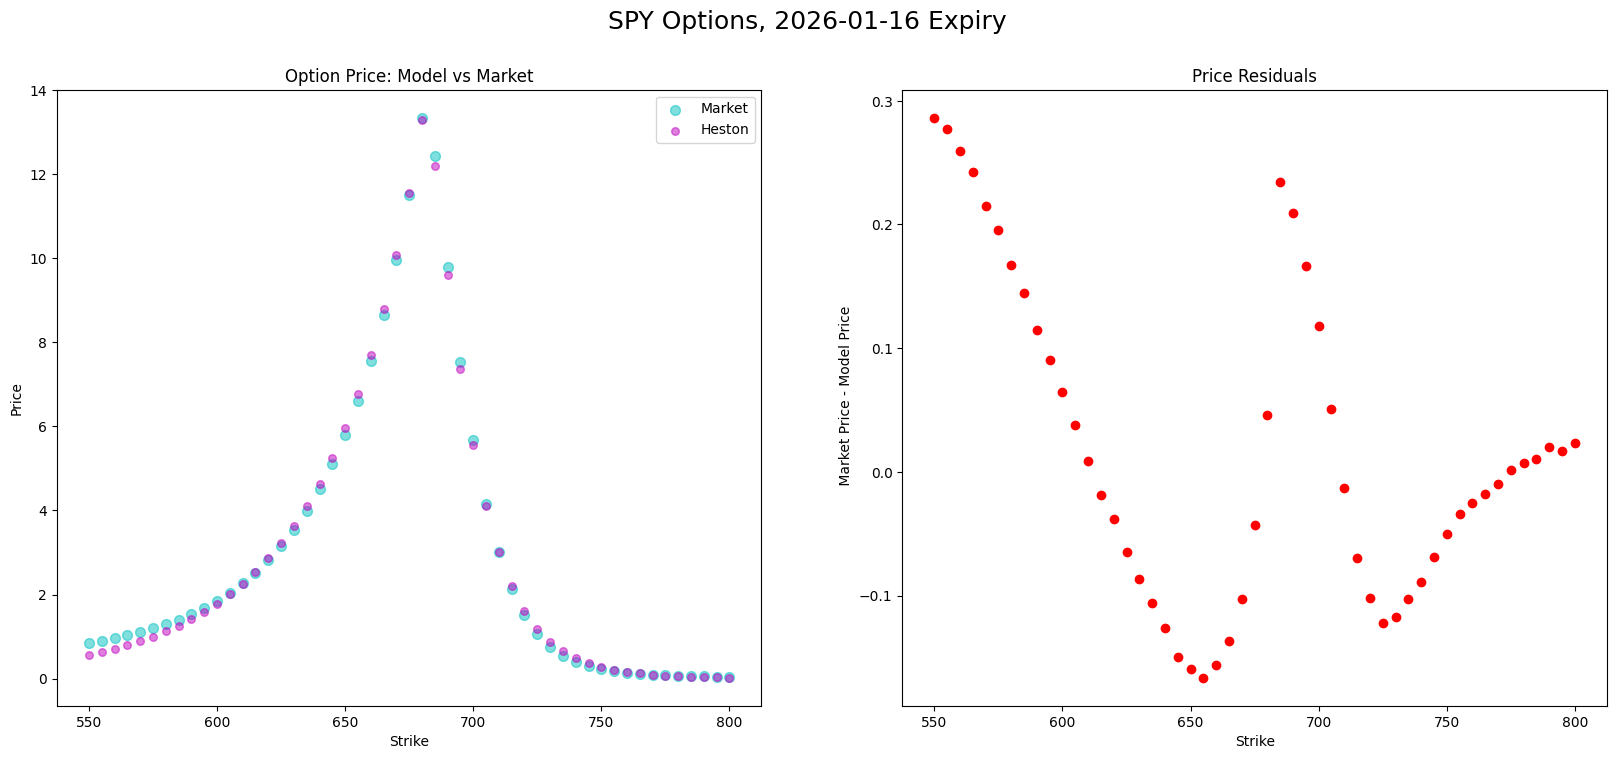

In [ ]:
plot_model_prices(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE, EXPIRY)

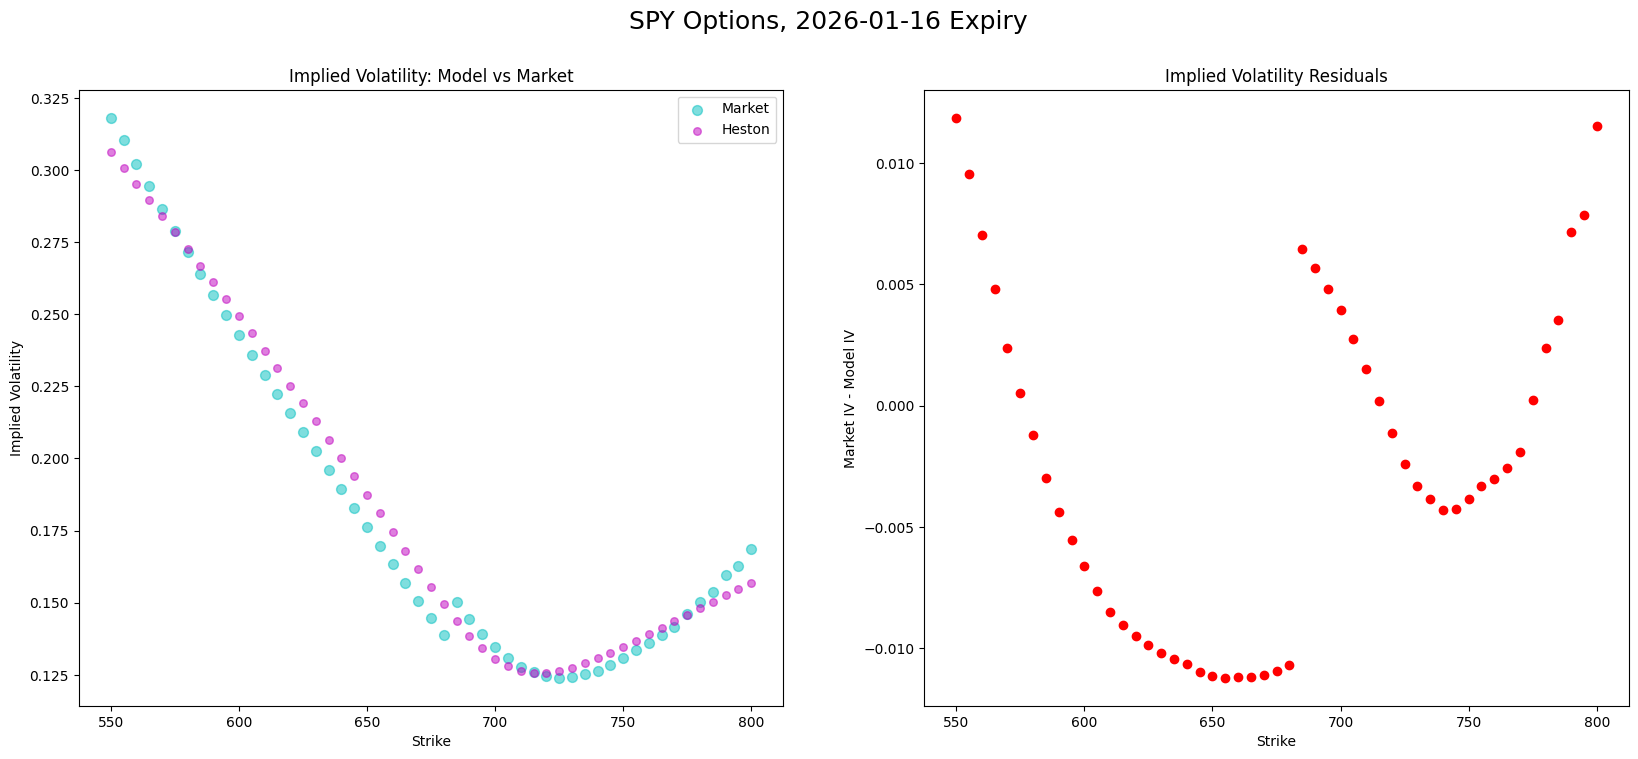

In [ ]:
plot_model_iv(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE, EXPIRY)

### Simulate Volatility Paths

In [ ]:
# ---------- Simulate Volatility Paths from Calibrated Heston ----------

# Simulation horizon
T_sim = float(option_chain_df["T"].max())

# Trading days to expiry
trading_days_to_exp = int(option_chain_df["trading_days_to_exp"].max())

# Monte Carlo settings
N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
N_PATHS_MC = 10000                              # number of simulated paths

# Simulate under today’s calibrated risk-neutral Heston dynamics
time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
vol_paths = np.sqrt(v_paths)

# Simulated spot prices and instantaneous vol at maturity
S_T = S_paths[:, -1]
sigma_T = vol_paths[:, -1]

# Distribution of future spot prices at maturity
S_T_mean = S_T.mean()
S_T_p05  = np.percentile(S_T, 5)
S_T_p95  = np.percentile(S_T, 95)

# Distribution of instantaneous vol at maturity
sigma_T_mean = sigma_T.mean()
sigma_T_p05  = np.percentile(sigma_T, 5)
sigma_T_p95  = np.percentile(sigma_T, 95)

# ---------- Monte Carlo Option Price Estimates & CI ----------

option_chain_df = est_mc_option_prices(option_chain_df, S_T, T_sim, r_curve, N_PATHS_MC, 1 - CI_ALPHA)

# ---------- 5%–95% Quantile Bands for Simulated Paths ----------

# Spot price paths
S_path_p05 = np.percentile(S_paths, 5, axis = 0)
S_path_p50 = np.percentile(S_paths, 50, axis = 0)
S_path_p95 = np.percentile(S_paths, 95, axis = 0)
S_path_quantiles = (S_path_p05, S_path_p50, S_path_p95)

# Variance paths
v_path_p05 = np.percentile(v_paths, 5, axis = 0)
v_path_p50 = np.percentile(v_paths, 50, axis = 0)
v_path_p95 = np.percentile(v_paths, 95, axis = 0)
v_path_quantiles = (v_path_p05, v_path_p50, v_path_p95)

# Volatility paths
vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)
vol_path_quantiles = (vol_path_p05, vol_path_p50, vol_path_p95)

#### Plots

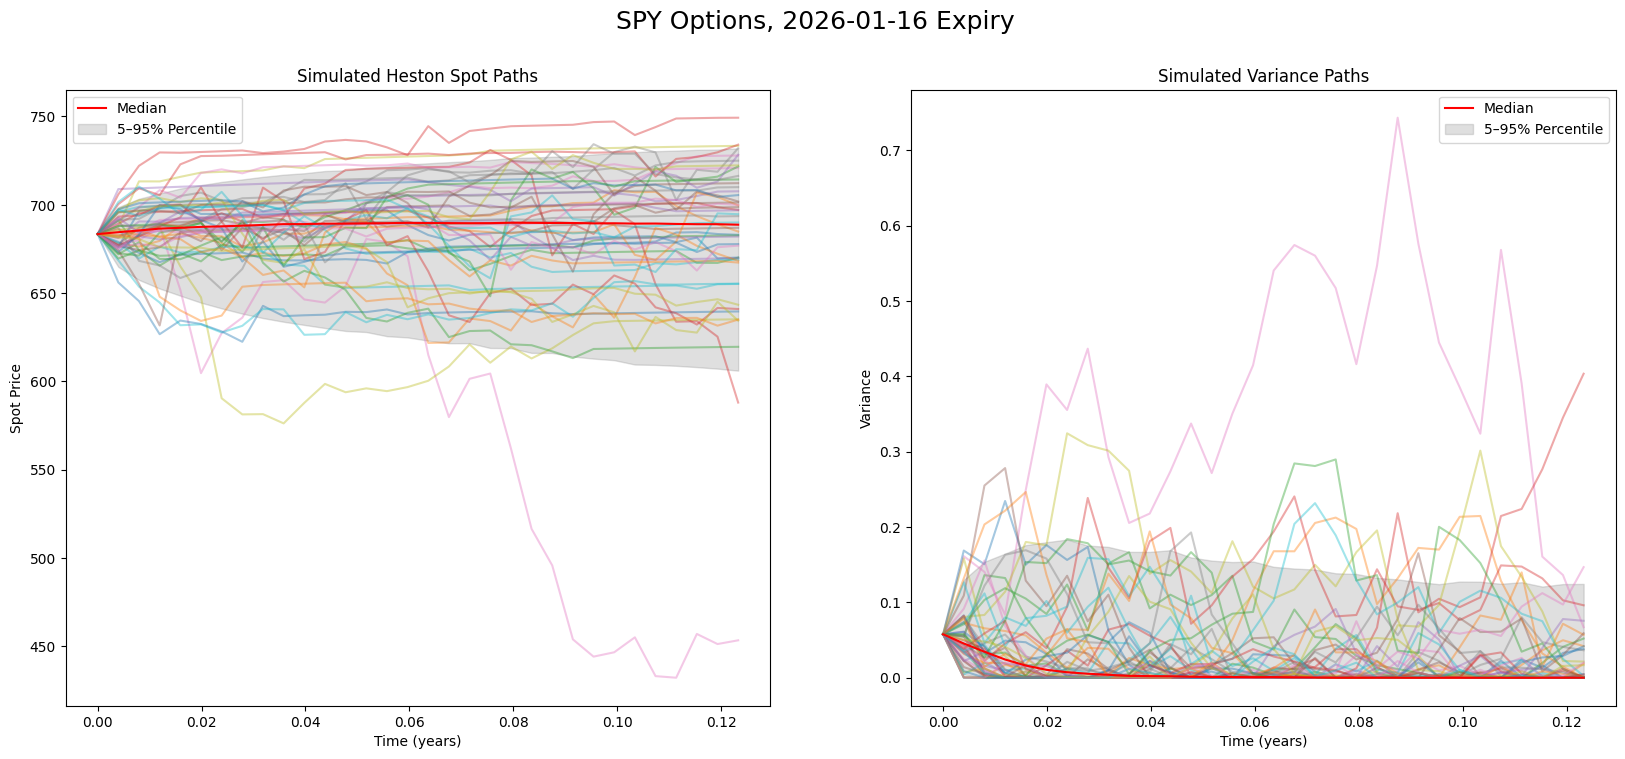

In [24]:
plot_sim_paths(time_grid, S_paths, v_paths, S_path_quantiles, v_path_quantiles, TICKER, EXPIRY, OPTION_TYPE)

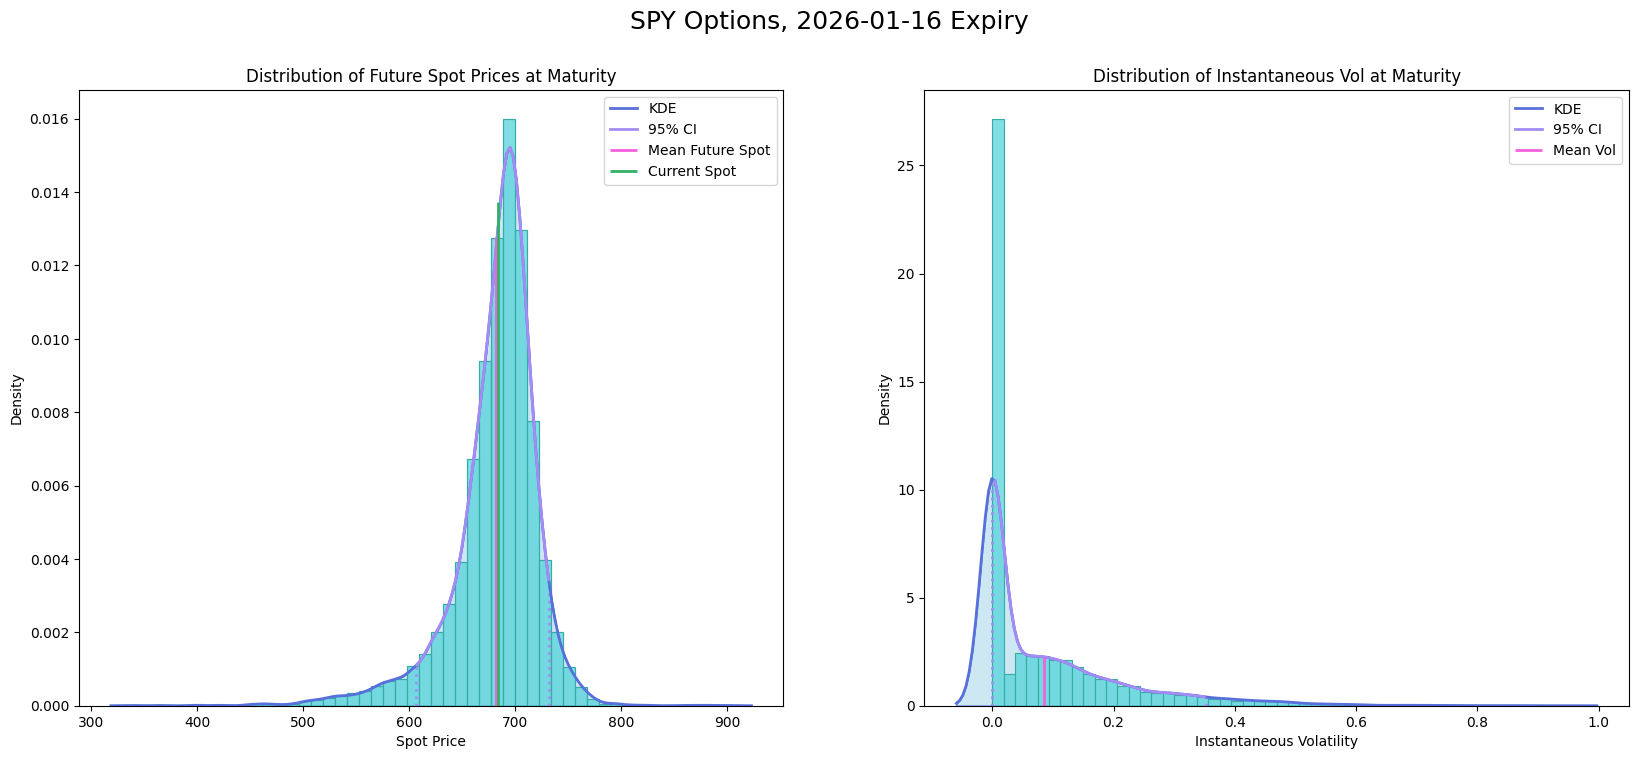

In [25]:
plot_distr_at_maturity(S_T, sigma_T, S0, TICKER, EXPIRY, OPTION_TYPE)

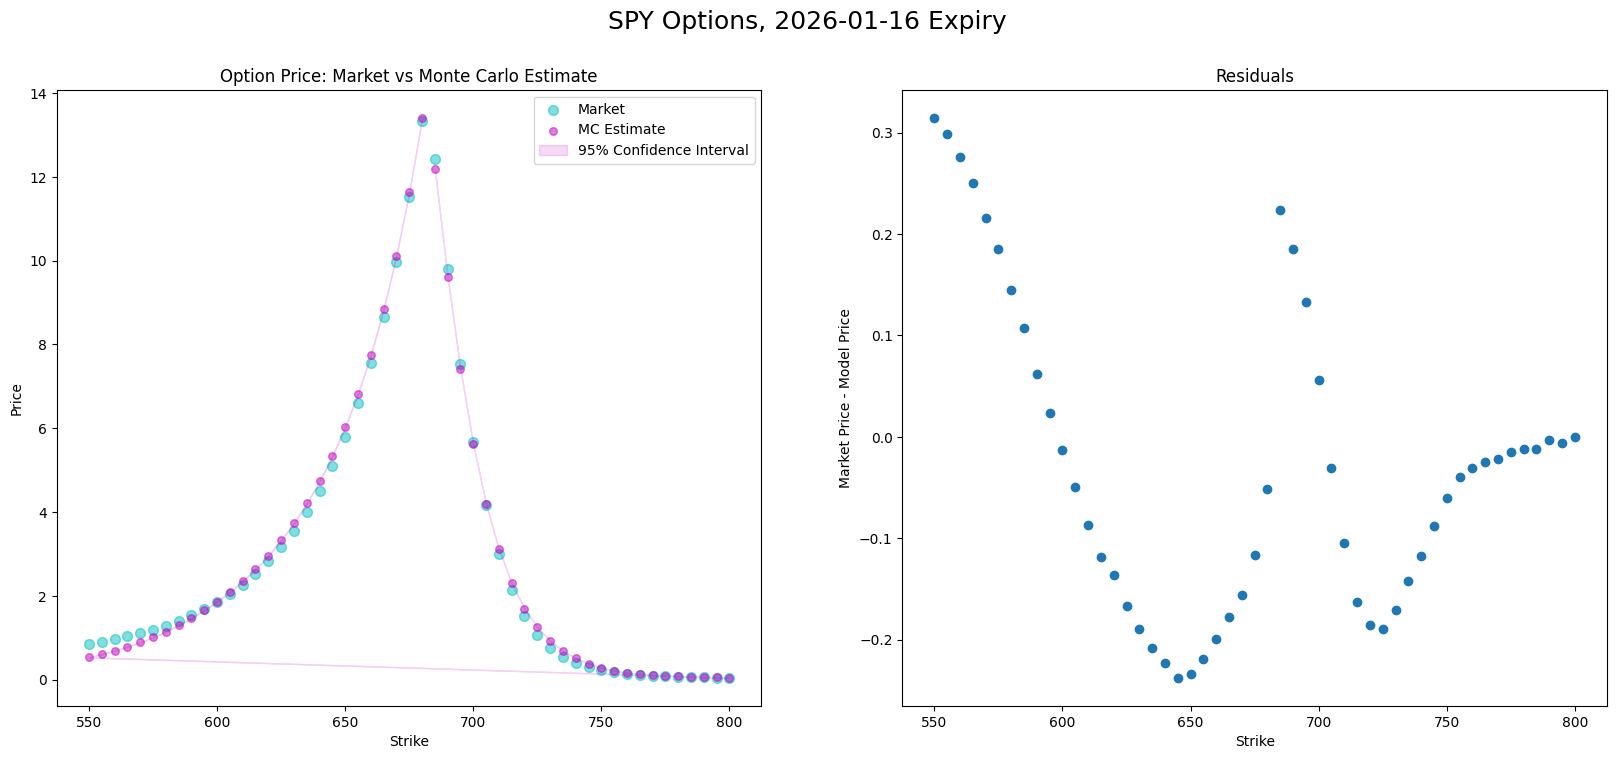

In [ ]:
plot_mc_est_prices(option_chain_df, TICKER, EXPIRY, OPTION_TYPE)

## All Options

### Calibrate Heston

In [ ]:
# ---------- Input Arguments ----------

option_chain_df = all_chains
NUM_EXPIRIES = N_EXP
OPTION_TYPE = None

# ---------- Calibrate Heston ----------

# Compute Option Greeks
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)
option_chain_df = compute_greeks_and_bs_price(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve)

# Calibration weighting
option_chain_df = calibration_weighting(option_chain_df, LAMBDA_WING)
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)

# Initial Heston Parameter Seeds
atm_option_chain_df = option_chain_df[(option_chain_df["moneyness_spot"] >= 0.95) & 
                                      (option_chain_df["moneyness_spot"] <= 1.05)].copy()
atm_iv  = float(atm_option_chain_df["iv_mkt"].median())

KAPPA_SEED  = 2.0                               # [0.05, 30]
THETA_SEED  = max(1e-4, (atm_iv * 1.1) ** 2)    # [1e-6, 2]
SIGMA_SEED  = 0.5                               # [0.05, 5.00]
RHO_SEED    = -0.5                              # [-0.999, -1e-3]
V0_SEED     = max(1e-4, atm_iv ** 2)            # [1e-6, 1.0]
HESTON_PARAM_SEEDS = [KAPPA_SEED, THETA_SEED, SIGMA_SEED, RHO_SEED, V0_SEED]

# Fit Heston Model
heston_params, params_ci, std_errors = fit_heston_ls(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve, 
                                                     HESTON_PARAM_SEEDS, PARAM_LB, PARAM_UB, CI_ALPHA) 
kappa, theta, sigma, rho, v0 = heston_params
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()

# Compute Model Prices & IV
option_chain_df = compute_model_prices_and_ivs(option_chain_df, heston_pricing_engine, today, S_quote, r_curve, q_curve)
option_chain_df = compute_residuals(option_chain_df)
rmse_price = compute_price_rmse(option_chain_df) 

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f},   \n          [{float(params_ci["kappa"][0]):.4f}, {float(params_ci["kappa"][1]):.4f}]")
print(f"  theta = {float(theta):.8f},   \n          [{float(params_ci["theta"][0]):.4f}, {float(params_ci["theta"][1]):.4f}]")
print(f"  sigma = {float(sigma):.8f},   \n          [{float(params_ci["sigma"][0]):.4f}, {float(params_ci["sigma"][1]):.4f}]")
print(f"  rho   = {float(rho):.8f},     \n          [{float(params_ci["rho"][0]):.4f}, {float(params_ci["rho"][1]):.4f}]")
print(f"  v0    = {float(v0):.8f},      \n          [{float(params_ci["v0"][0]):.4f}, {float(params_ci["v0"][1]):.4f}]")
print(f"\nPrice RMSE: {float(rmse_price):.8f}")
print(f"Mean Option Price: {float(np.nanmean(option_chain_df["mid"])):.8f}")

Calibrated Heston Parameters:
  kappa = 2.79545144,   
          [-0.1652, 5.7561]
  theta = 0.06168947,   
          [0.0278, 0.0956]
  sigma = 1.77935039,   
          [1.2830, 2.2757]
  rho   = -0.26979164,     
          [-0.3087, -0.2308]
  v0    = 0.02637607,      
          [0.0242, 0.0286]

Price RMSE: 1.66542043
Mean Option Price: 4.32599699


#### Plots

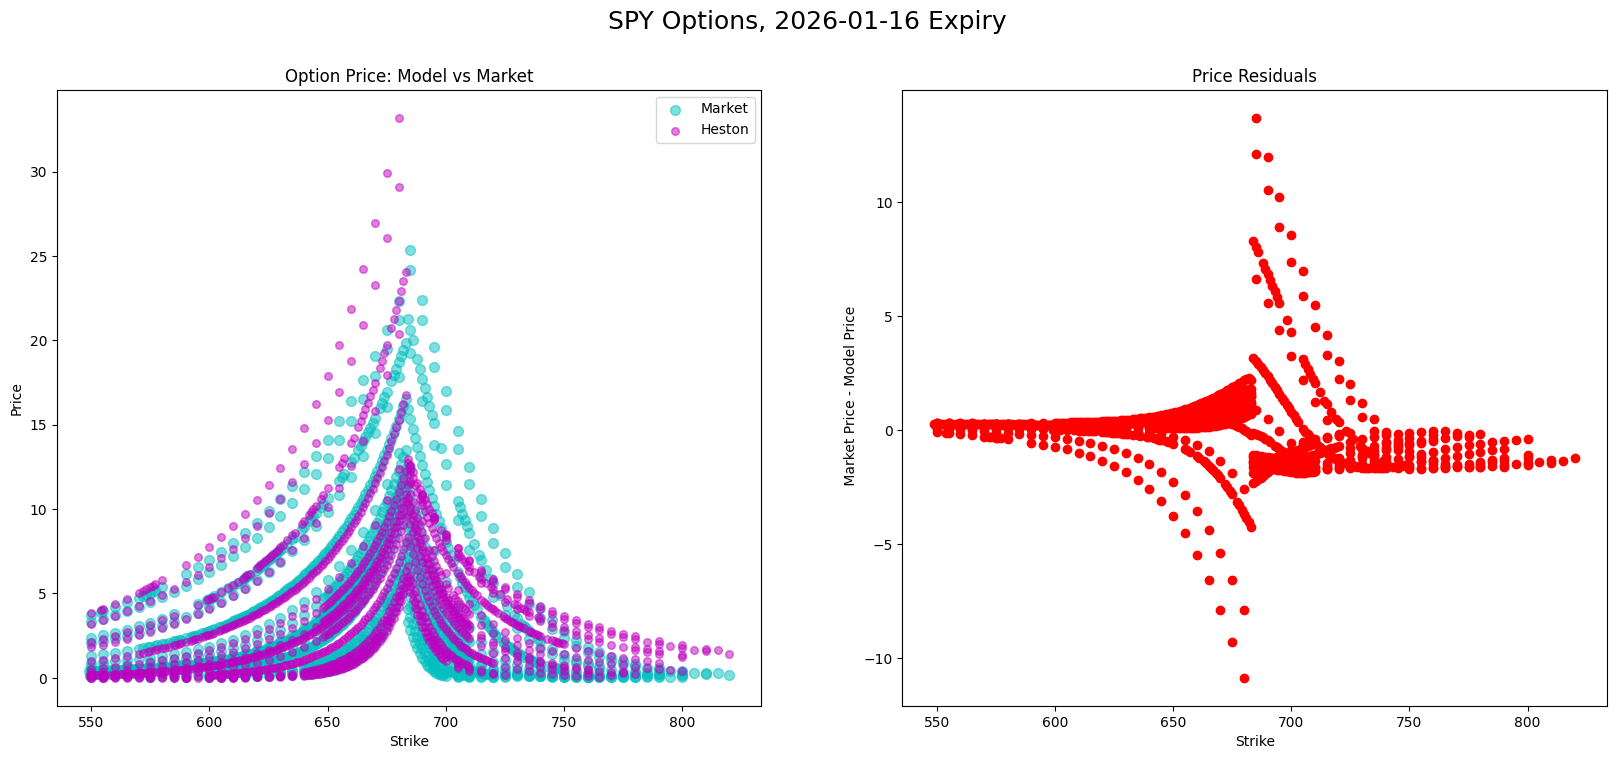

In [ ]:
plot_model_prices(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE, EXPIRY)

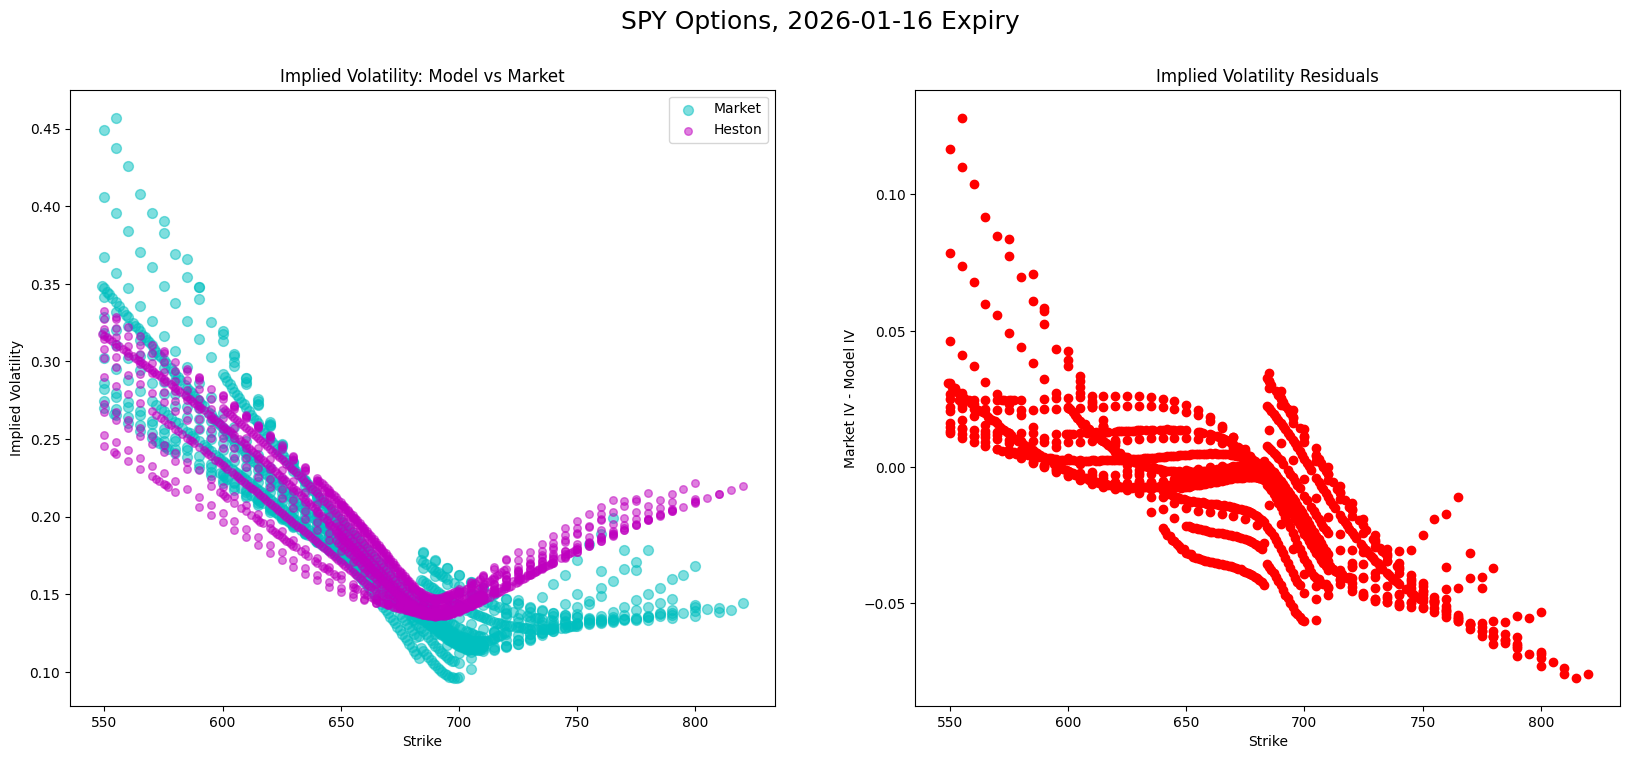

In [ ]:
plot_model_iv(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE, EXPIRY)

## Most Liquid Expiries

### Calibrate Heston

In [6]:
# ---------- Input Arguments ----------

option_chain_df = liq_chains_df
NUM_EXPIRIES = N_LIQ_EXP
OPTION_TYPE = None

# ---------- Calibrate Heston ----------

# Compute Option Greeks
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)
option_chain_df = compute_greeks_and_bs_price(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve)

# Calibration weighting
option_chain_df = calibration_weighting(option_chain_df, LAMBDA_WING)
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)

# Initial Heston Parameter Seeds
atm_option_chain_df = option_chain_df[(option_chain_df["moneyness_spot"] >= 0.95) & 
                                      (option_chain_df["moneyness_spot"] <= 1.05)].copy()
atm_iv  = float(atm_option_chain_df["iv_mkt"].median())

KAPPA_SEED  = 2.0                               # [0.05, 30]
THETA_SEED  = max(1e-4, (atm_iv * 1.1) ** 2)    # [1e-6, 2]
SIGMA_SEED  = 0.5                               # [0.05, 5.00]
RHO_SEED    = -0.5                              # [-0.999, -1e-3]
V0_SEED     = max(1e-4, atm_iv ** 2)            # [1e-6, 1.0]
HESTON_PARAM_SEEDS = [KAPPA_SEED, THETA_SEED, SIGMA_SEED, RHO_SEED, V0_SEED]

# Fit Heston Model
heston_params, params_ci, std_errors = fit_heston_ls(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve, 
                                                     HESTON_PARAM_SEEDS, PARAM_LB, PARAM_UB, CI_ALPHA) 
kappa, theta, sigma, rho, v0 = heston_params
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()

# Compute Model Prices & IV
option_chain_df = compute_model_prices_and_ivs(option_chain_df, heston_pricing_engine, today, S_quote, r_curve, q_curve)
option_chain_df = compute_residuals(option_chain_df)
rmse_price = compute_price_rmse(option_chain_df) 

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f},   \n          [{float(params_ci["kappa"][0]):.4f}, {float(params_ci["kappa"][1]):.4f}]")
print(f"  theta = {float(theta):.8f},   \n          [{float(params_ci["theta"][0]):.4f}, {float(params_ci["theta"][1]):.4f}]")
print(f"  sigma = {float(sigma):.8f},   \n          [{float(params_ci["sigma"][0]):.4f}, {float(params_ci["sigma"][1]):.4f}]")
print(f"  rho   = {float(rho):.8f},     \n          [{float(params_ci["rho"][0]):.4f}, {float(params_ci["rho"][1]):.4f}]")
print(f"  v0    = {float(v0):.8f},      \n          [{float(params_ci["v0"][0]):.4f}, {float(params_ci["v0"][1]):.4f}]")

Calibrated Heston Parameters:
  kappa = 30.00000000,   
          [20.6220, 39.3780]
  theta = 0.03102245,   
          [0.0297, 0.0323]
  sigma = 2.93473273,   
          [2.3083, 3.5612]
  rho   = -0.62483973,     
          [-0.6546, -0.5951]
  v0    = 0.03039275,      
          [0.0279, 0.0329]


#### Plots

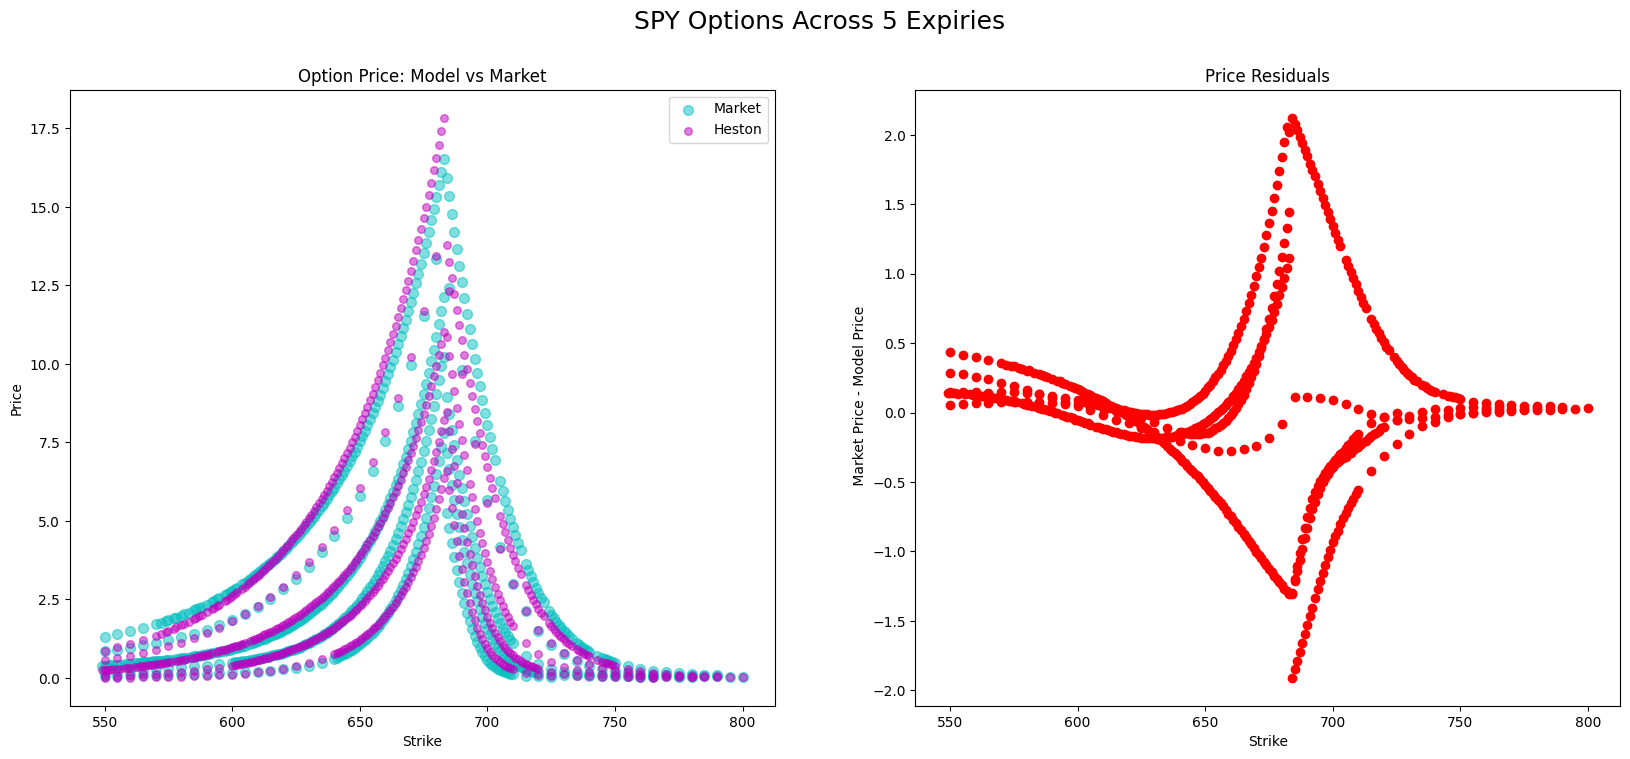

In [7]:
plot_model_prices(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE)

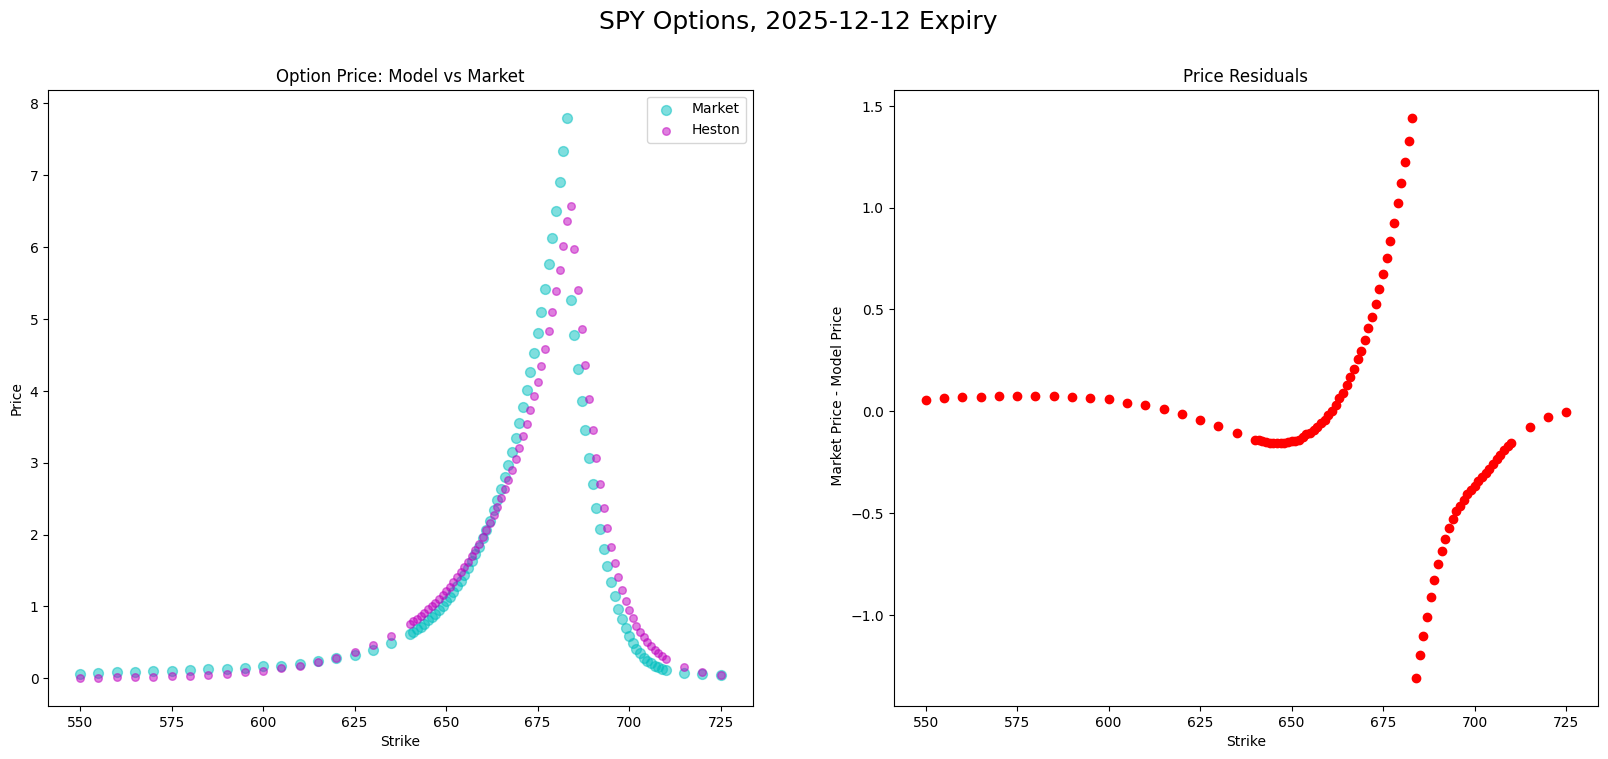

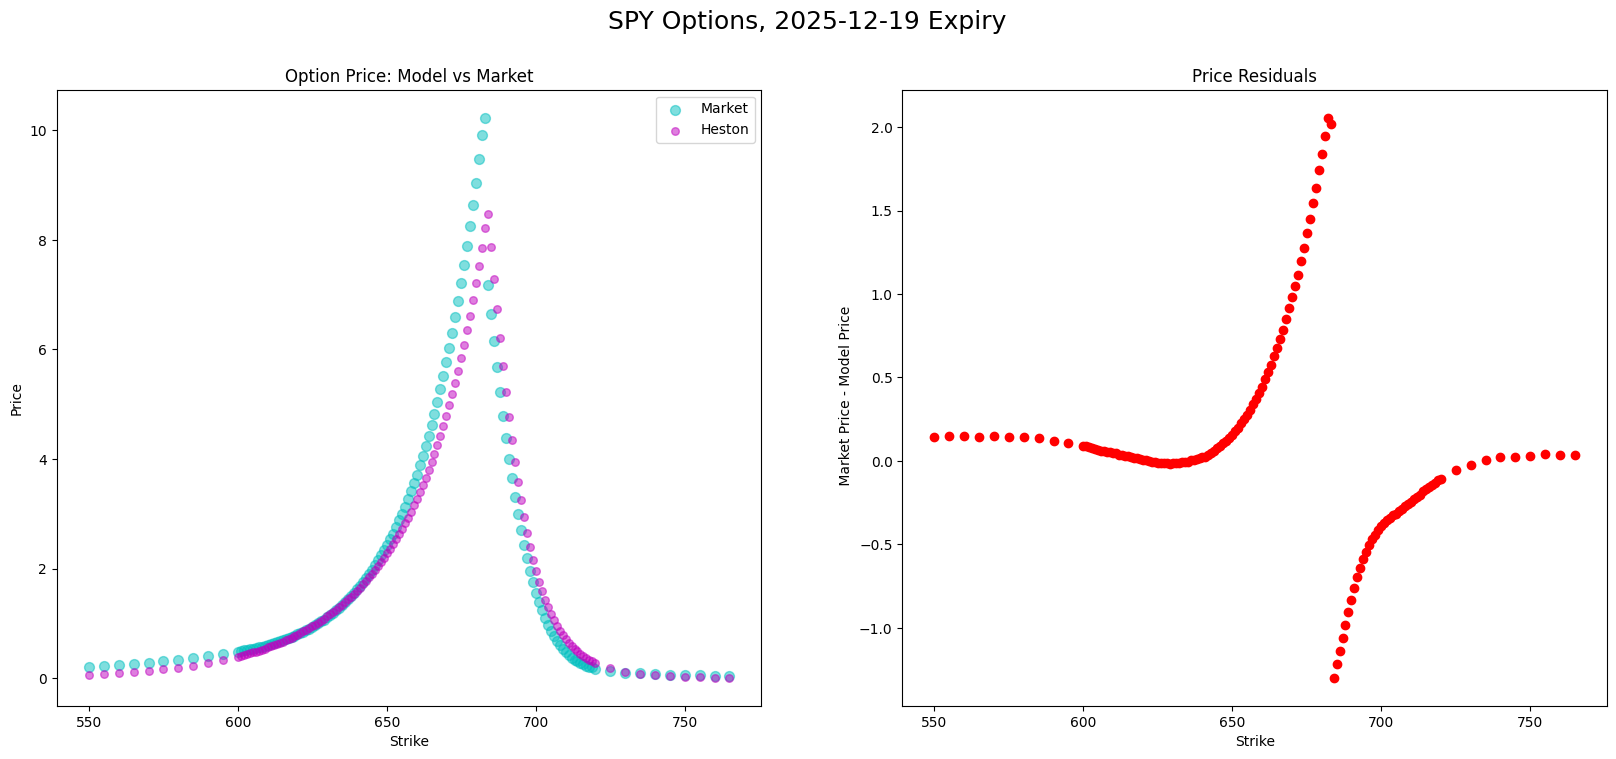

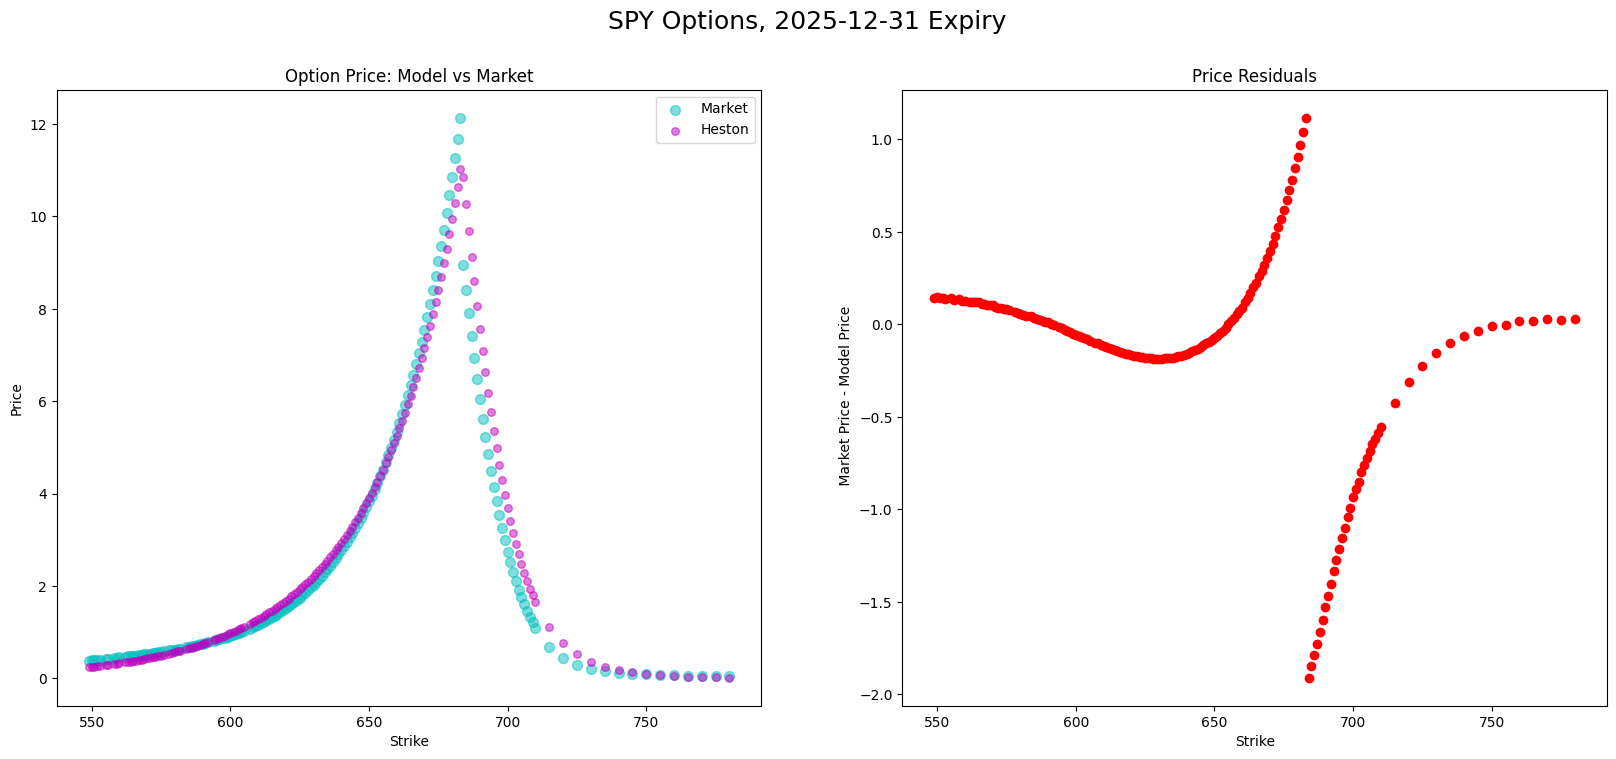

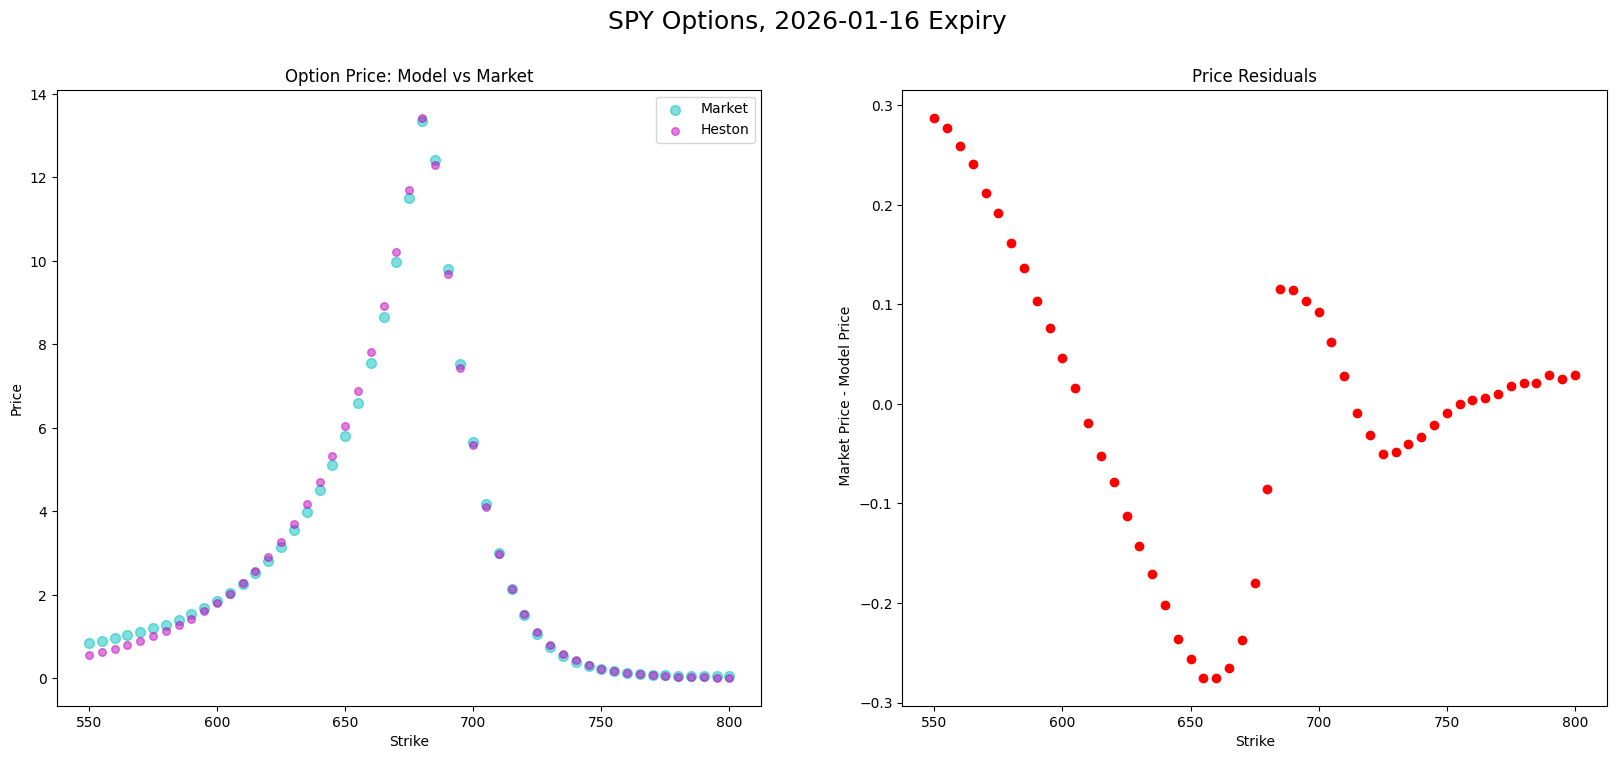

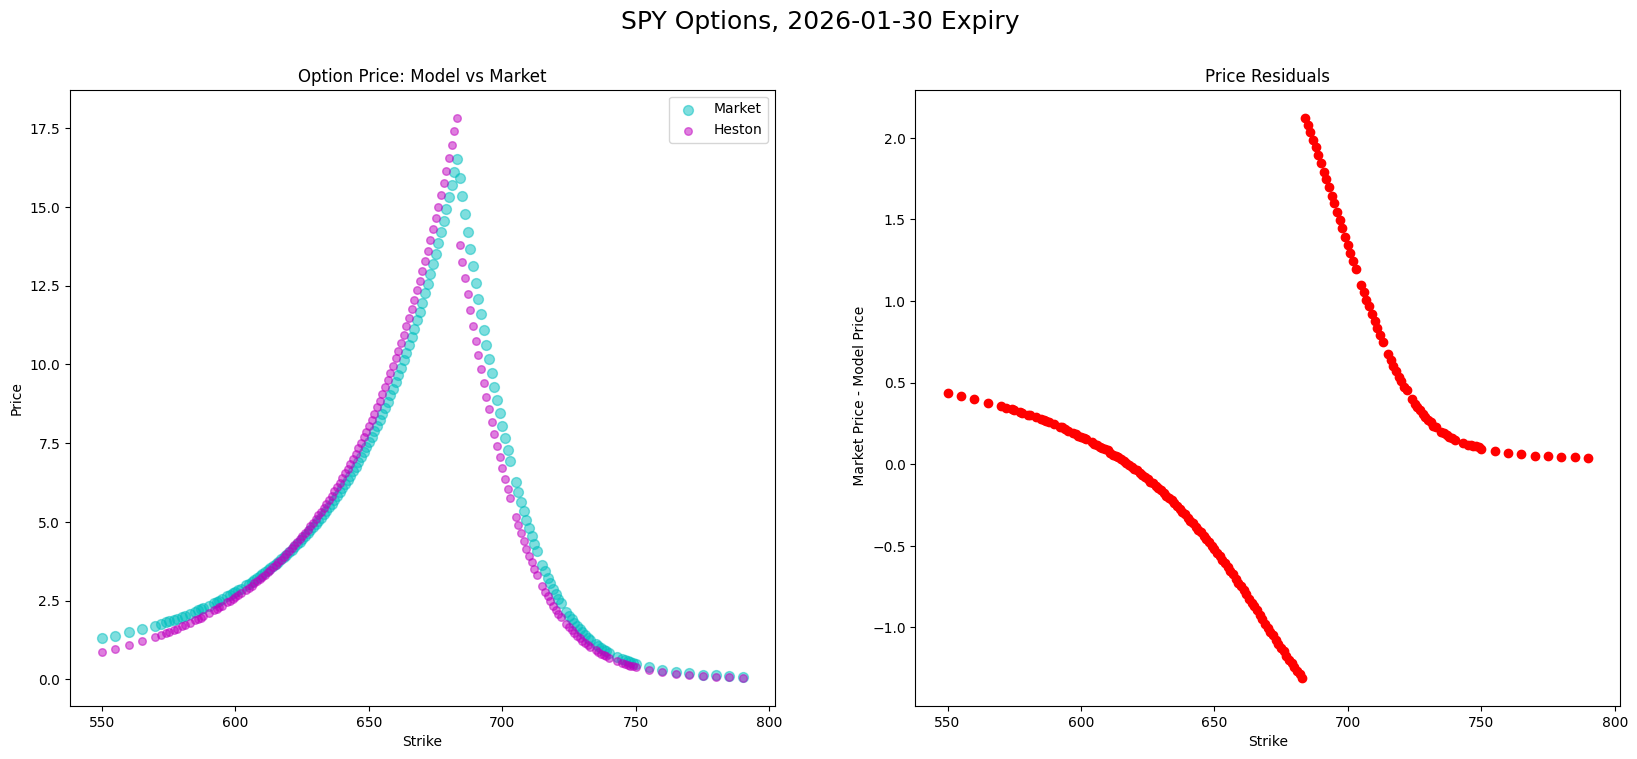

In [8]:
for liq_expiry in most_liquid_expiries: 
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]
    plot_model_prices(exp_option_chain_df, TICKER, 1, OPTION_TYPE, liq_expiry)

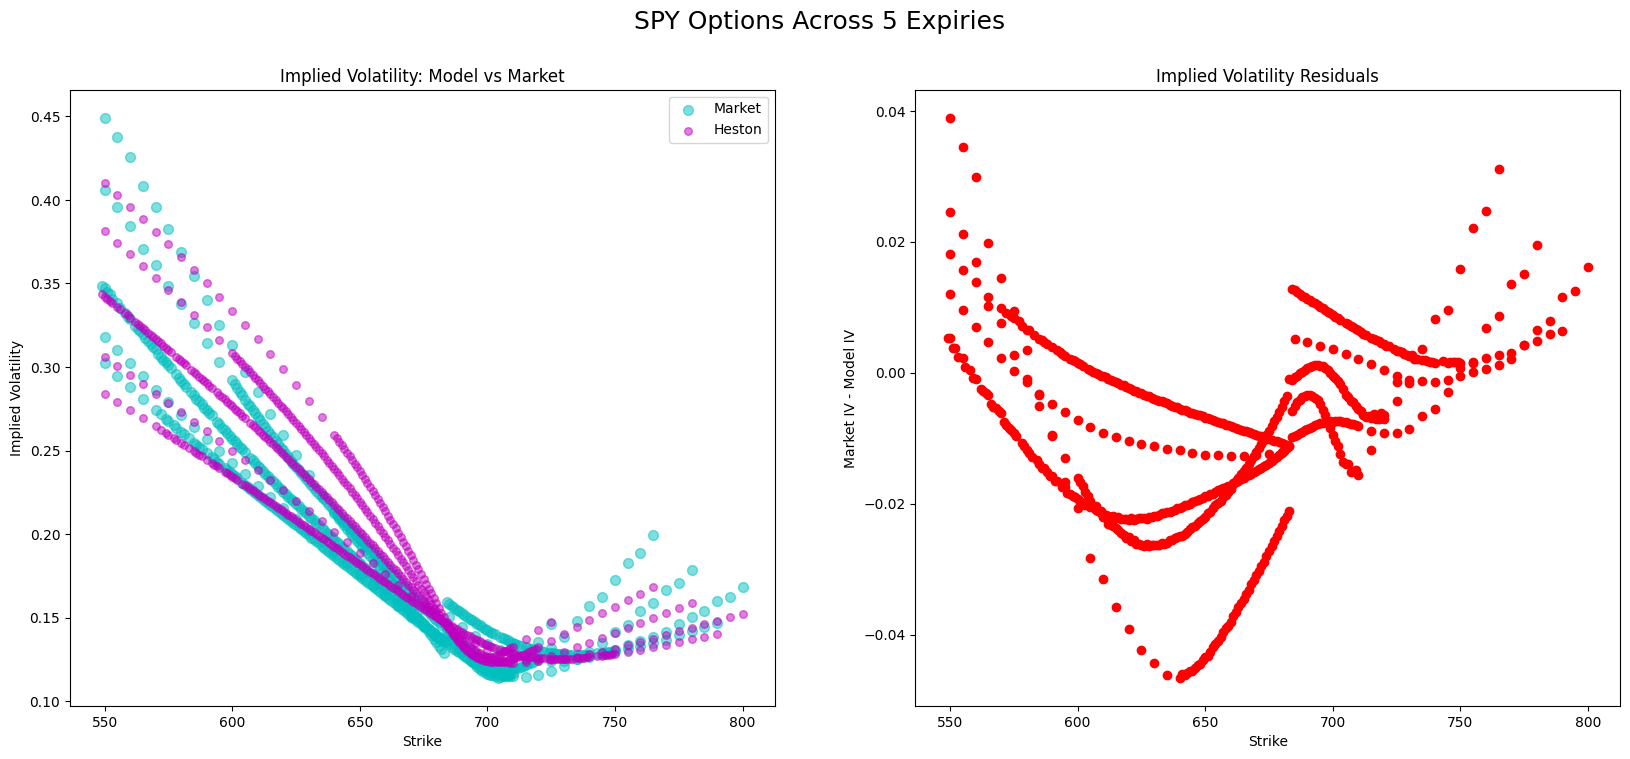

In [9]:
plot_model_iv(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE)

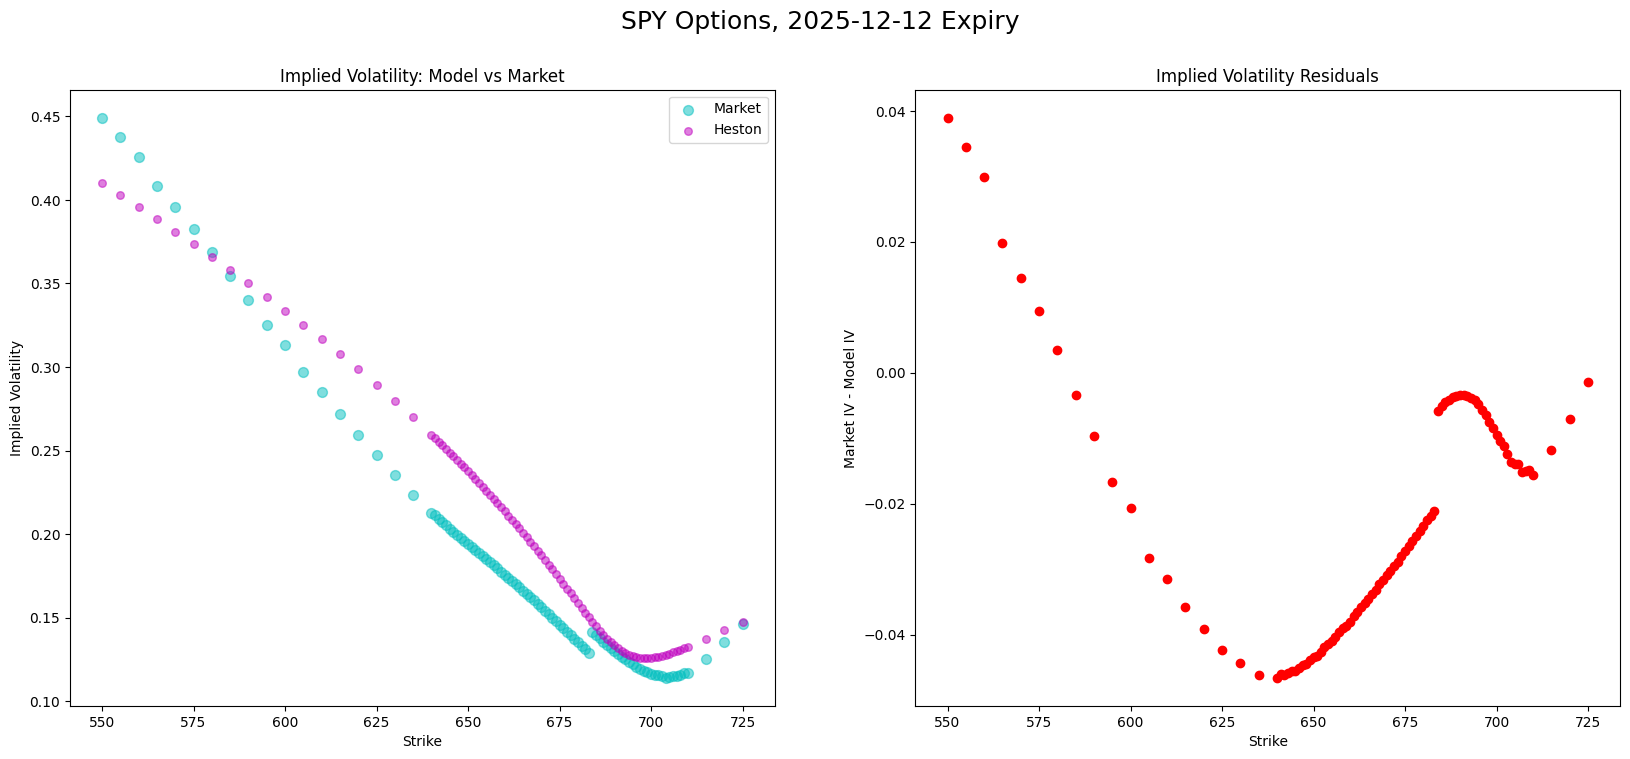

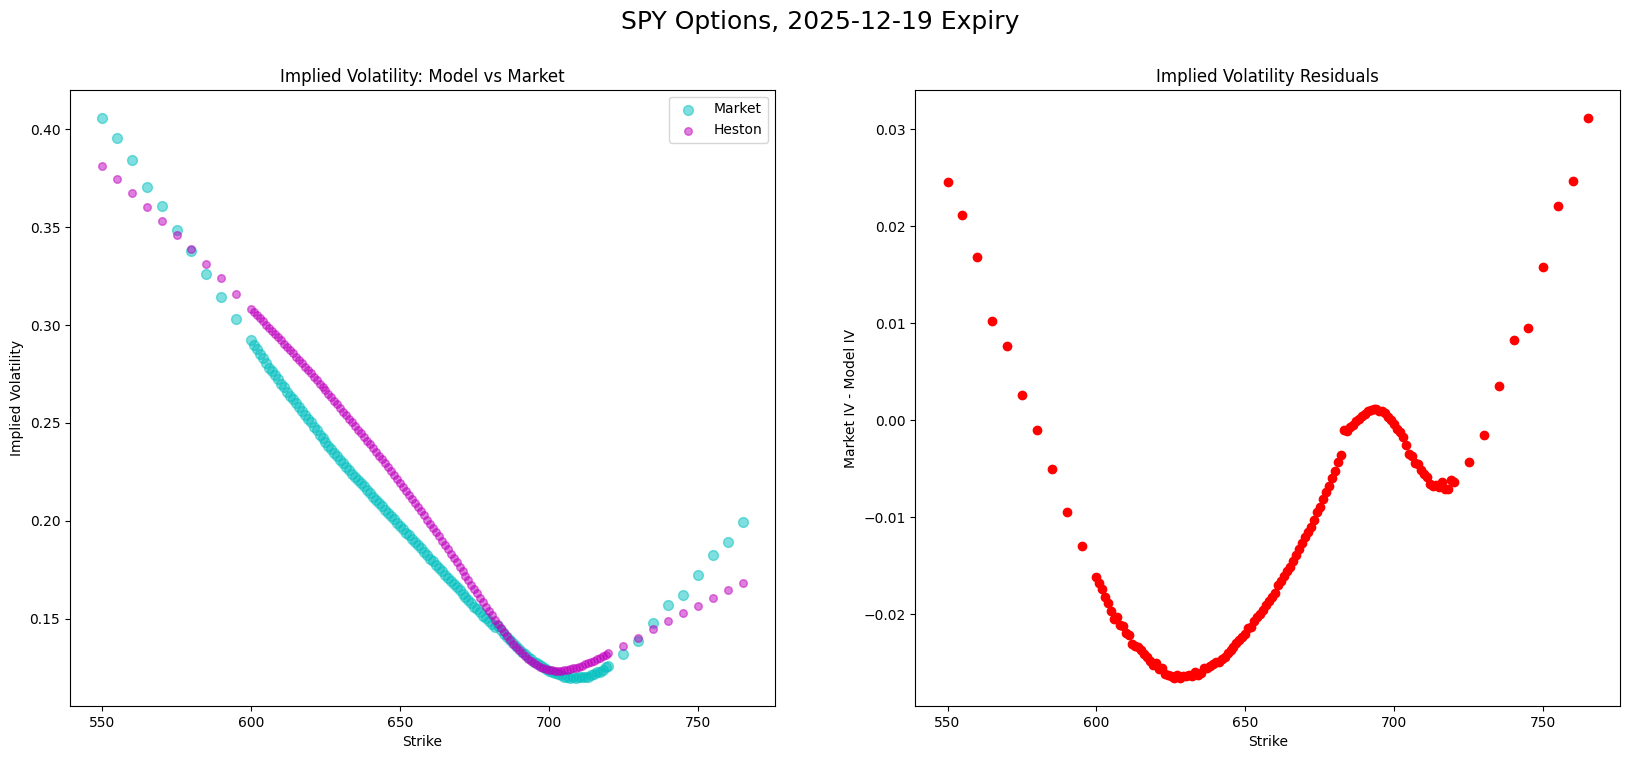

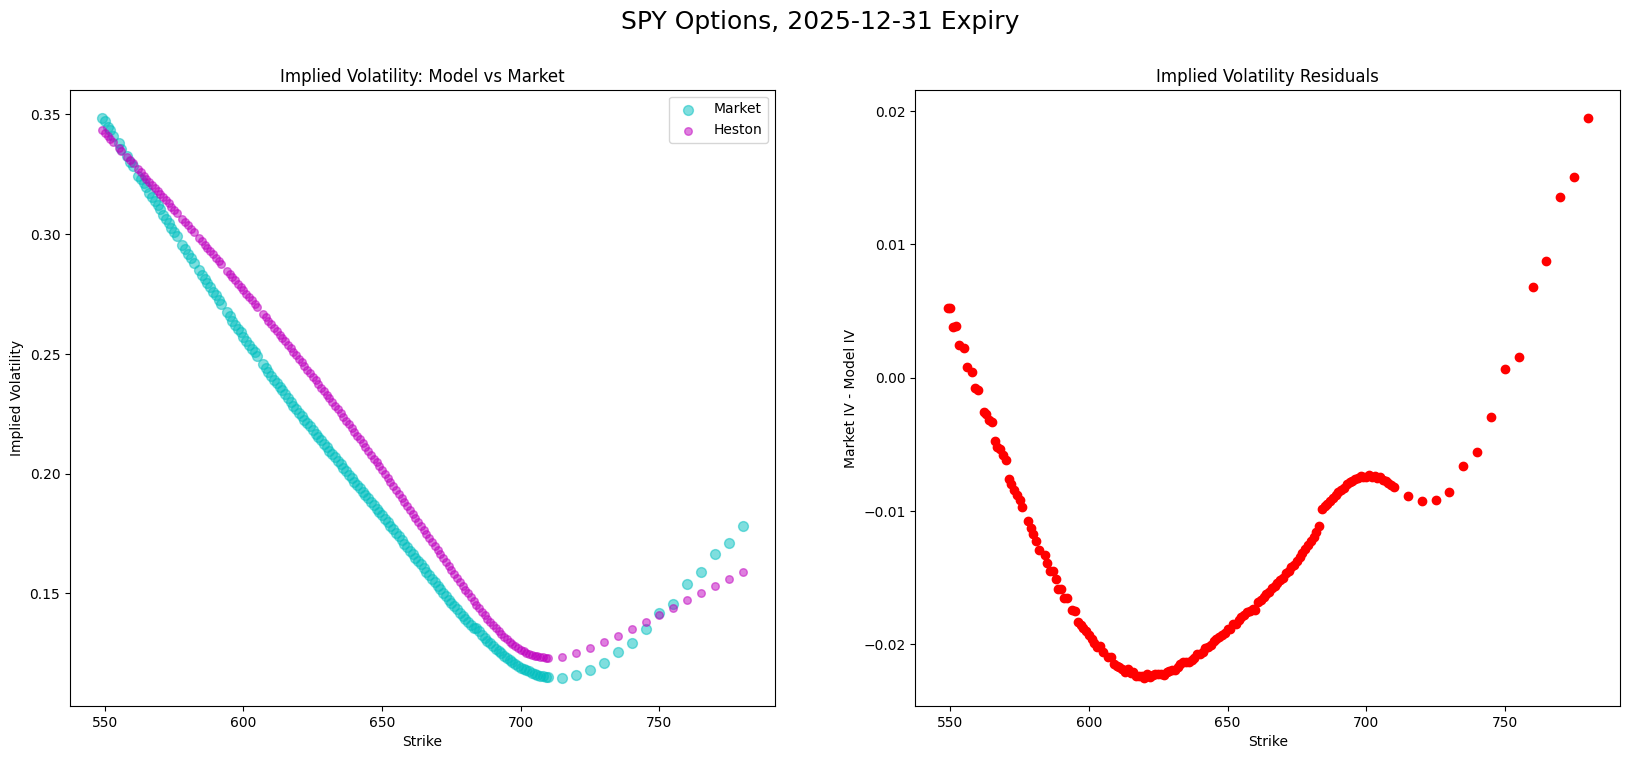

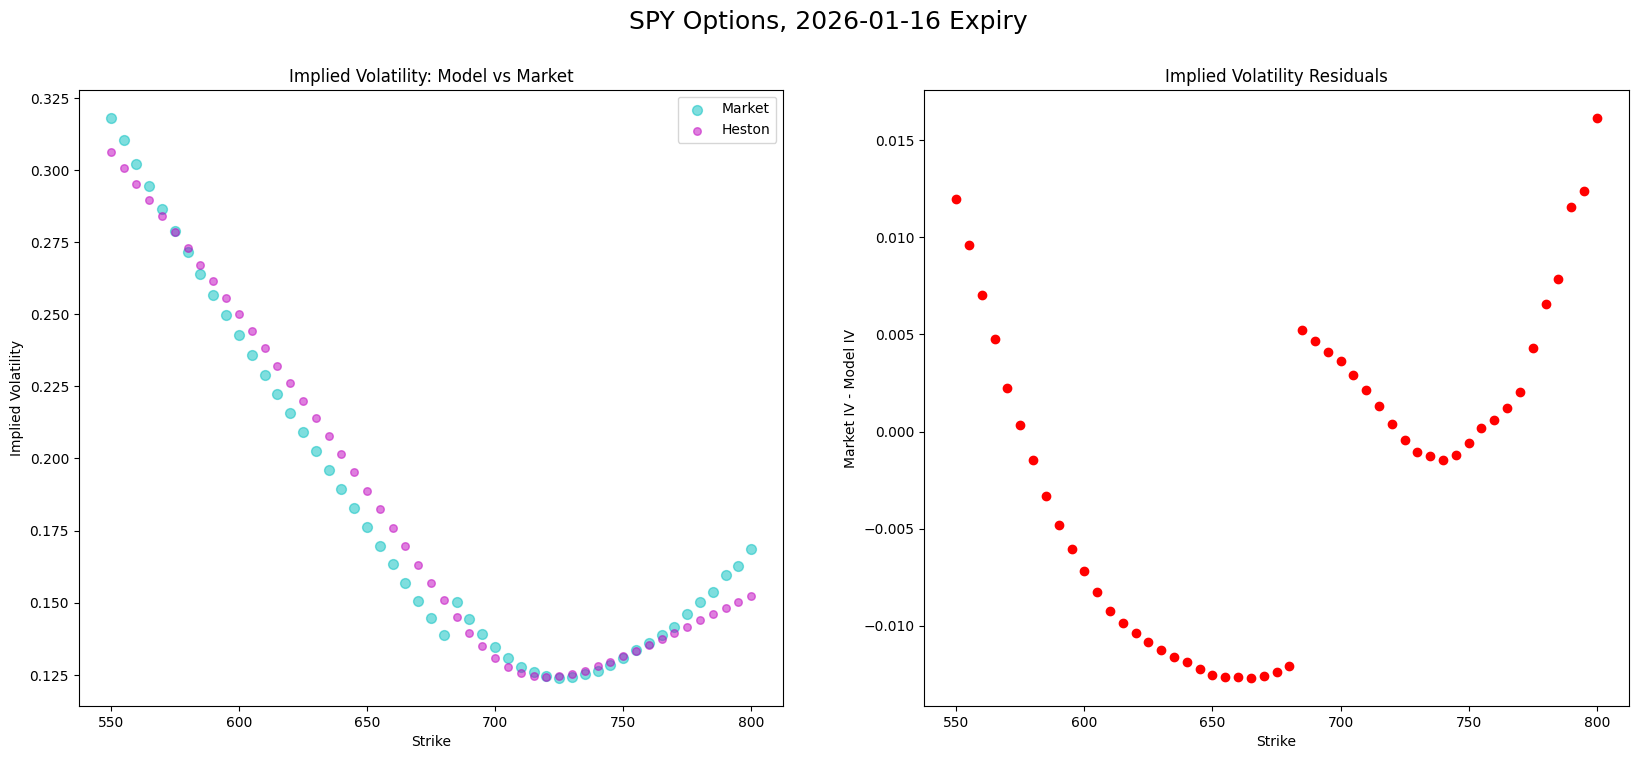

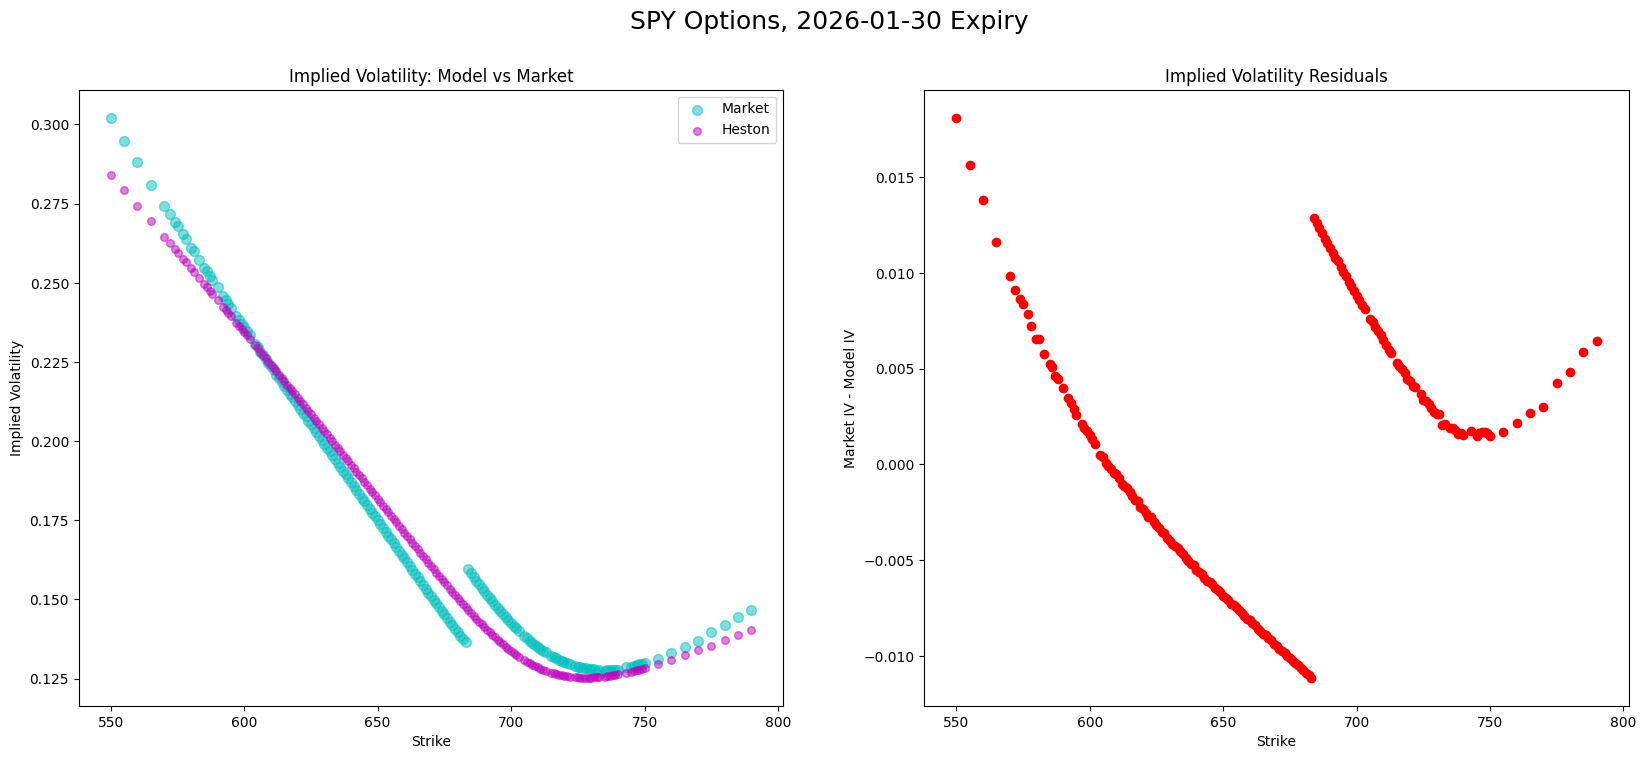

In [10]:
for liq_expiry in most_liquid_expiries: 
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]
    plot_model_iv(exp_option_chain_df, TICKER, 1, OPTION_TYPE, liq_expiry)

### Simulate Volatility Paths

In [ ]:
time_grids_by_exp = {}
S_paths_by_exp = {}
S_path_quantiles_by_exp = {}
v_paths_by_exp = {}
v_path_quantiles_by_exp = {}
vol_paths_by_exp = {}
vol_path_quantiles_by_exp = {}
S_T_by_exp = {}
sigma_T_by_exp = {}
mc_est_by_exp = {}

for liq_expiry in most_liquid_expiries: 
    
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]

    # ---------- Simulate Volatility Paths from Calibrated Heston ----------

    # Simulation horizon
    T_sim = float(exp_option_chain_df["T"].max())
    
    # Trading days to expiry
    trading_days_to_exp = int(exp_option_chain_df["trading_days_to_exp"].max())

    # Monte Carlo settings
    N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
    N_PATHS_MC = 10000                              # number of simulated paths

    # Simulate under today’s calibrated risk-neutral Heston dynamics
    time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
    vol_paths = np.sqrt(v_paths)
    time_grids_by_exp[liq_expiry] = time_grid
    S_paths_by_exp[liq_expiry] = S_paths
    v_paths_by_exp[liq_expiry] = v_paths
    vol_paths_by_exp[liq_expiry] = vol_paths

    # Simulated spot prices and instantaneous vol at maturity
    S_T = S_paths[:, -1]
    S_T_by_exp[liq_expiry] = S_T
    sigma_T = vol_paths[:, -1]
    sigma_T_by_exp[liq_expiry] = sigma_T

    # ---------- Monte Carlo Option Price Estimates & CI ----------

    exp_option_chain_df = est_mc_option_prices(exp_option_chain_df, S_T, T_sim, r_curve, N_PATHS_MC, 1 - CI_ALPHA)
    mc_est_by_exp[liq_expiry] = exp_option_chain_df

    # ---------- 5%–95% Quantile Bands for Simulated Paths ----------

    # Spot price paths
    S_path_p05 = np.percentile(S_paths, 5, axis = 0)
    S_path_p50 = np.percentile(S_paths, 50, axis = 0)
    S_path_p95 = np.percentile(S_paths, 95, axis = 0)
    S_path_quantiles = (S_path_p05, S_path_p50, S_path_p95)
    S_path_quantiles_by_exp[liq_expiry] = S_path_quantiles

    # Variance paths
    v_path_p05 = np.percentile(v_paths, 5, axis = 0)
    v_path_p50 = np.percentile(v_paths, 50, axis = 0)
    v_path_p95 = np.percentile(v_paths, 95, axis = 0)
    v_path_quantiles = (v_path_p05, v_path_p50, v_path_p95)
    v_path_quantiles_by_exp[liq_expiry] = v_path_quantiles

    # Volatility paths
    vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
    vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
    vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)
    vol_path_quantiles = (vol_path_p05, vol_path_p50, vol_path_p95)
    vol_path_quantiles_by_exp[liq_expiry] = vol_path_quantiles

#### Plots

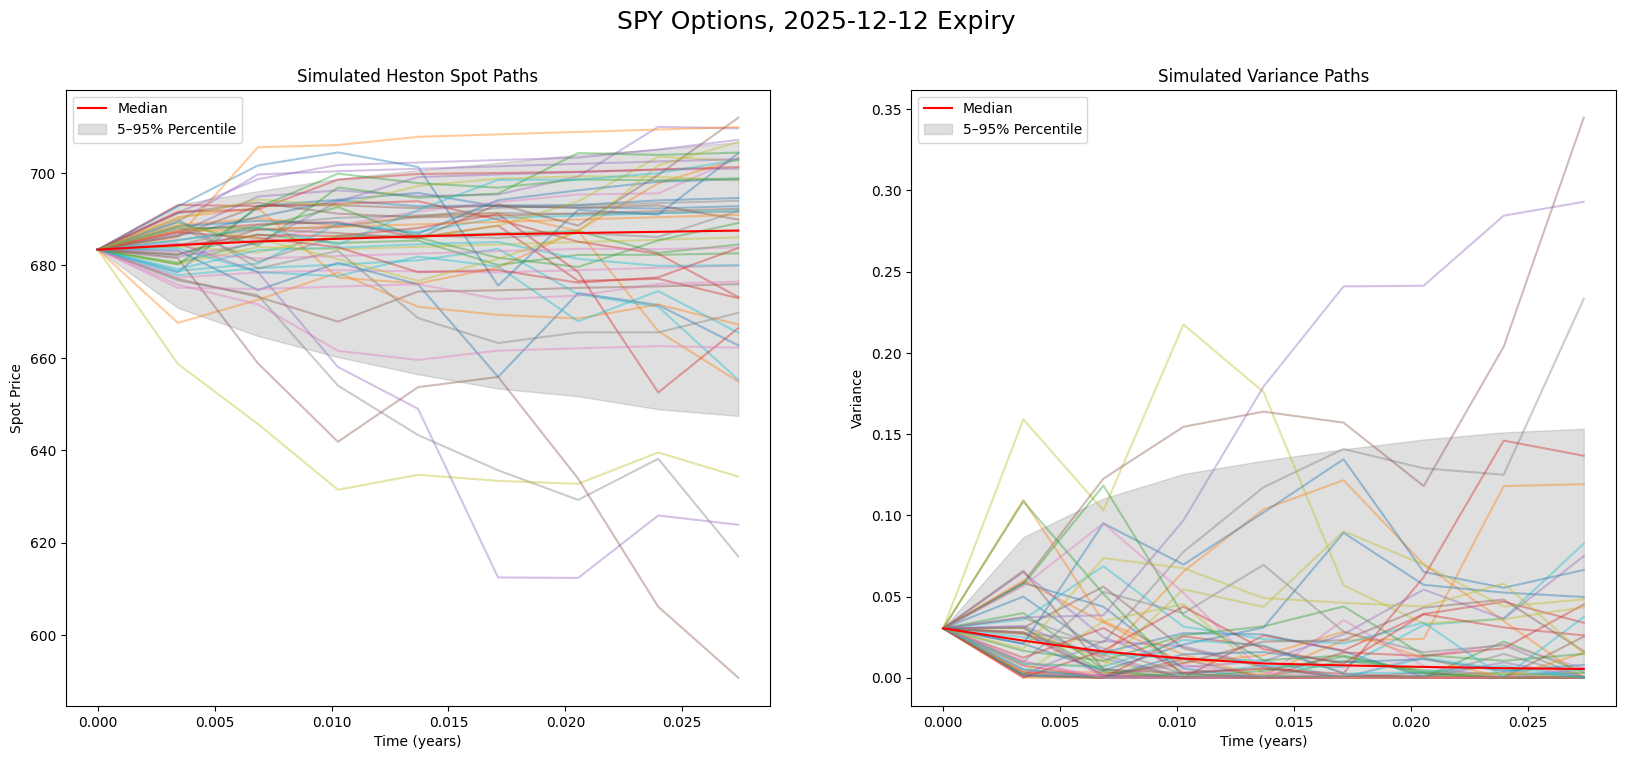

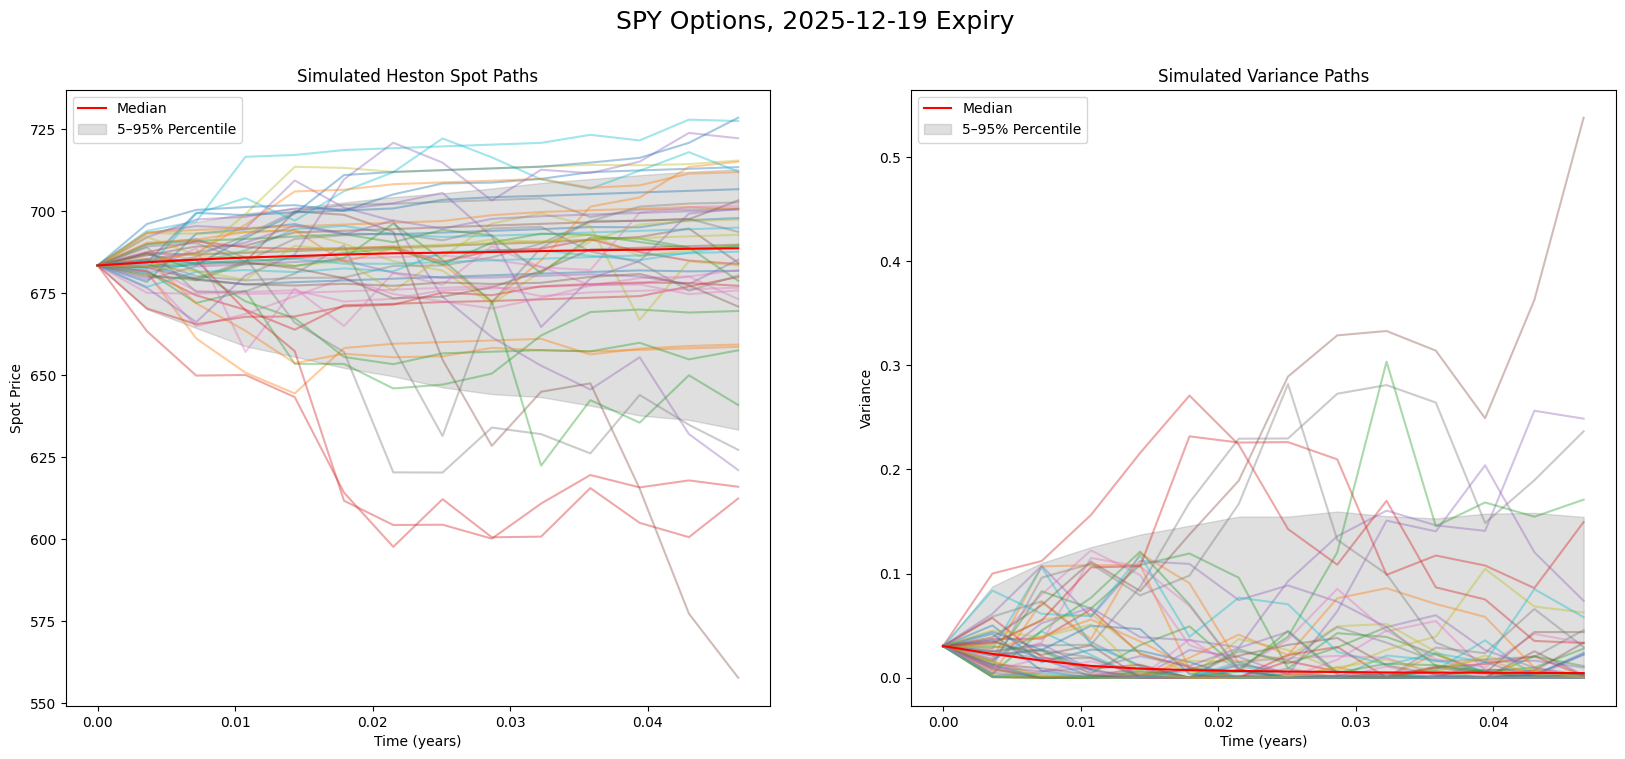

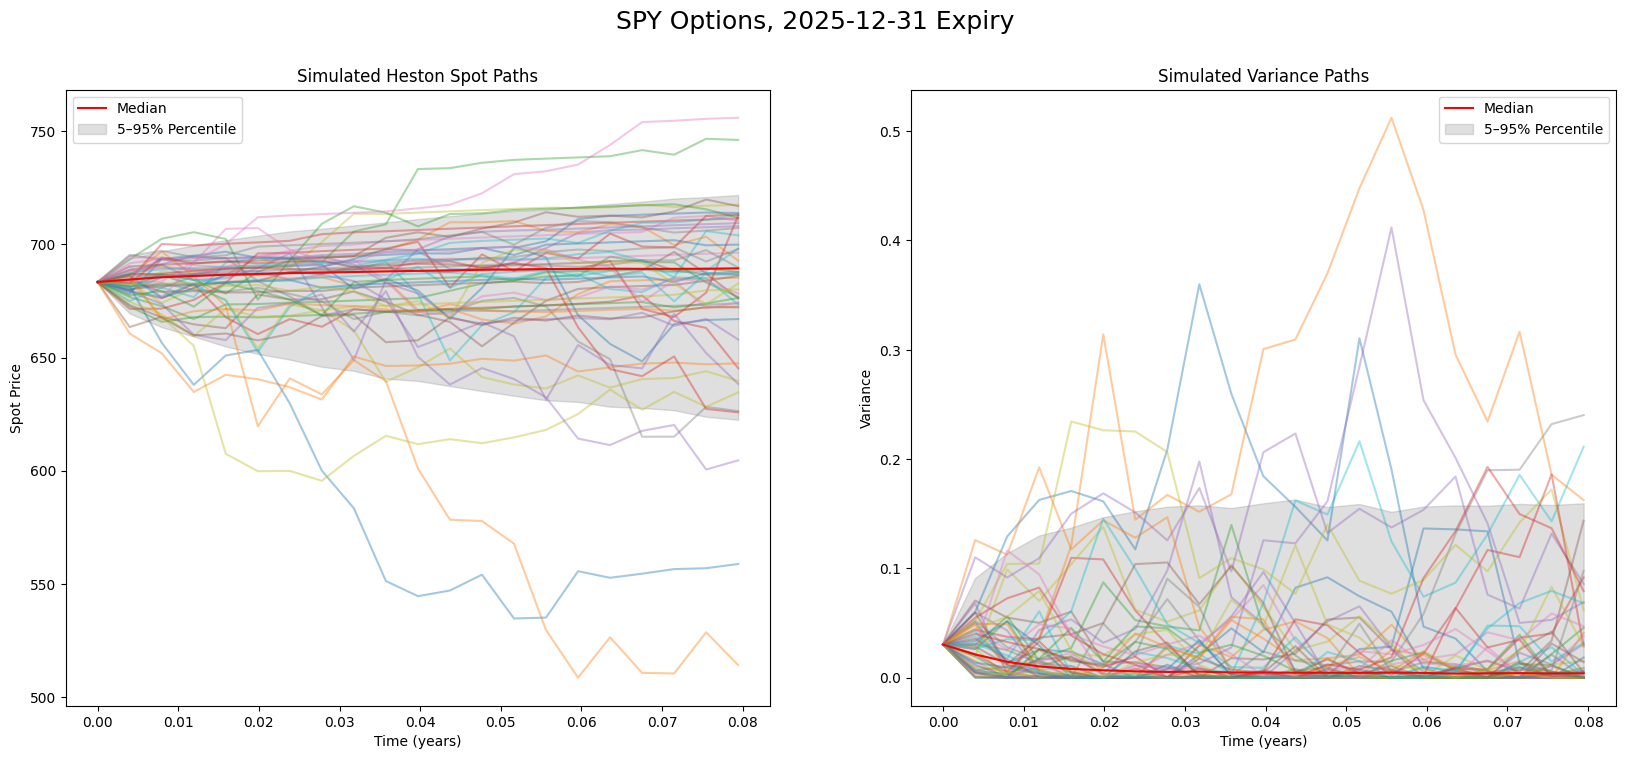

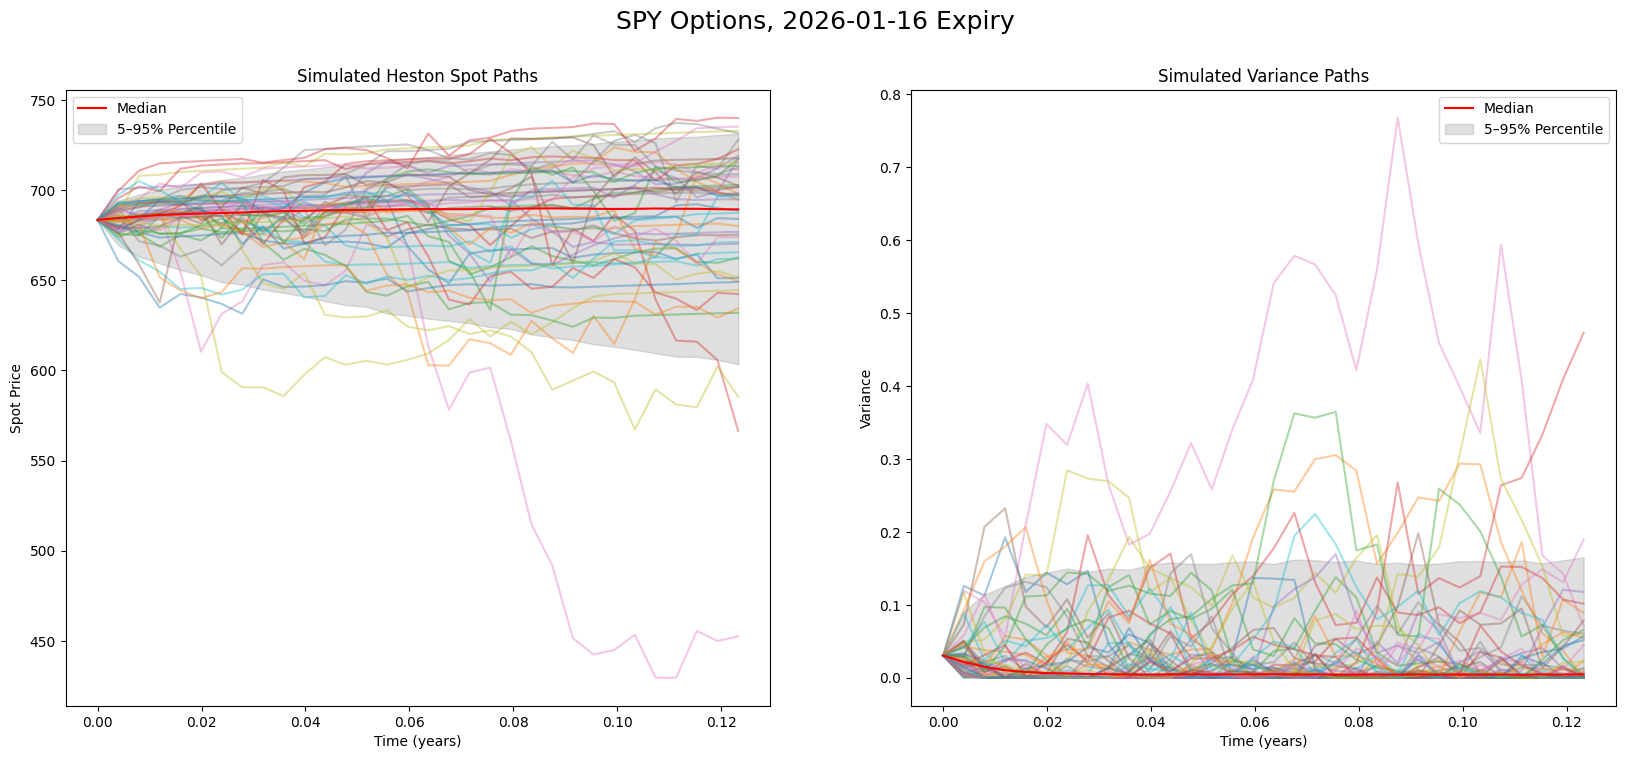

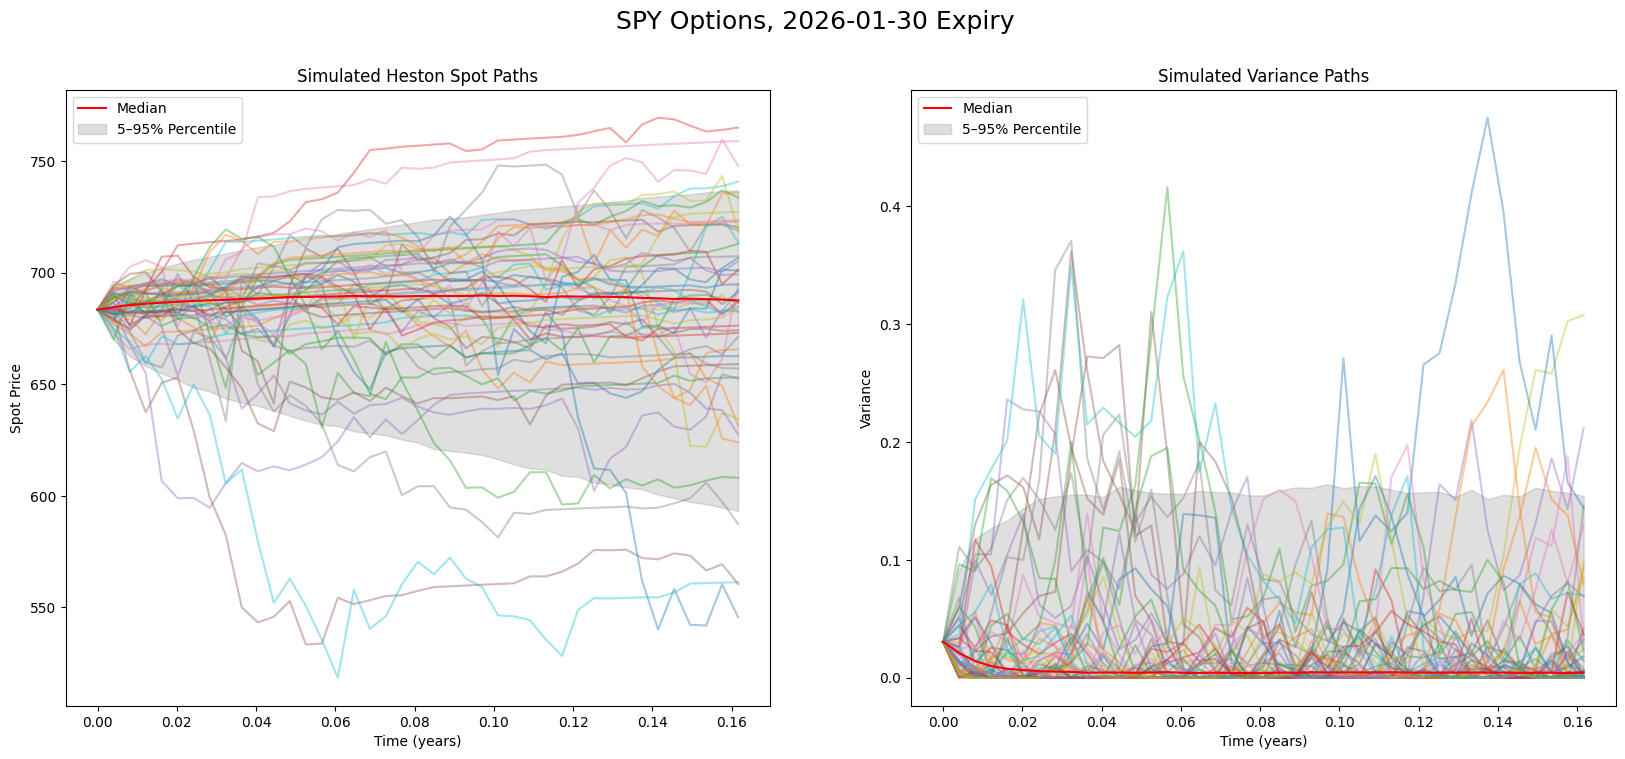

In [12]:
for liq_expiry in most_liquid_expiries: 
    plot_sim_paths(time_grids_by_exp[liq_expiry], S_paths_by_exp[liq_expiry], v_paths_by_exp[liq_expiry], 
                   S_path_quantiles_by_exp[liq_expiry], v_path_quantiles_by_exp[liq_expiry], 
                   TICKER, liq_expiry, OPTION_TYPE)

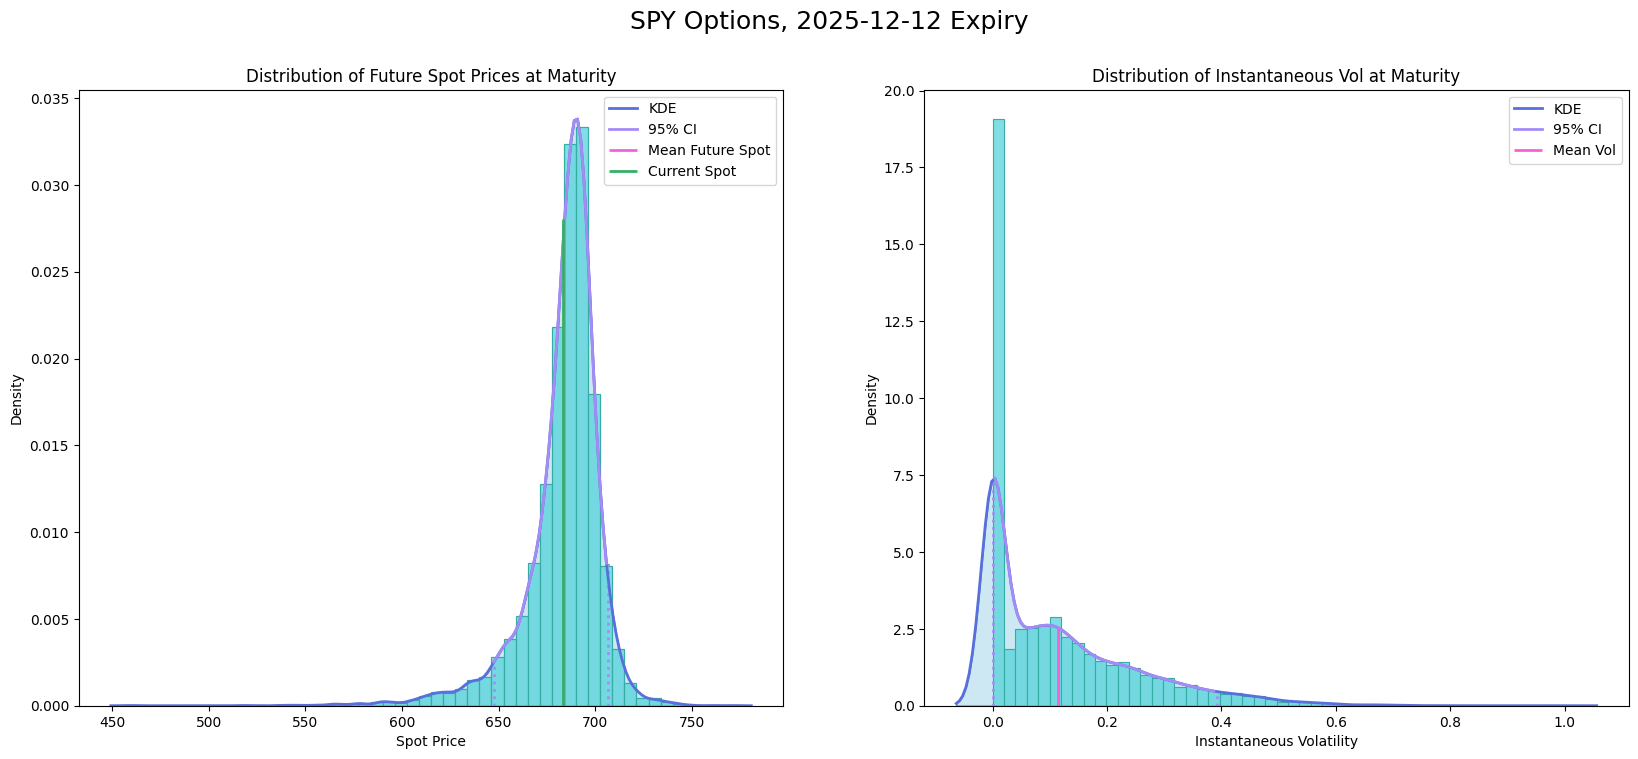

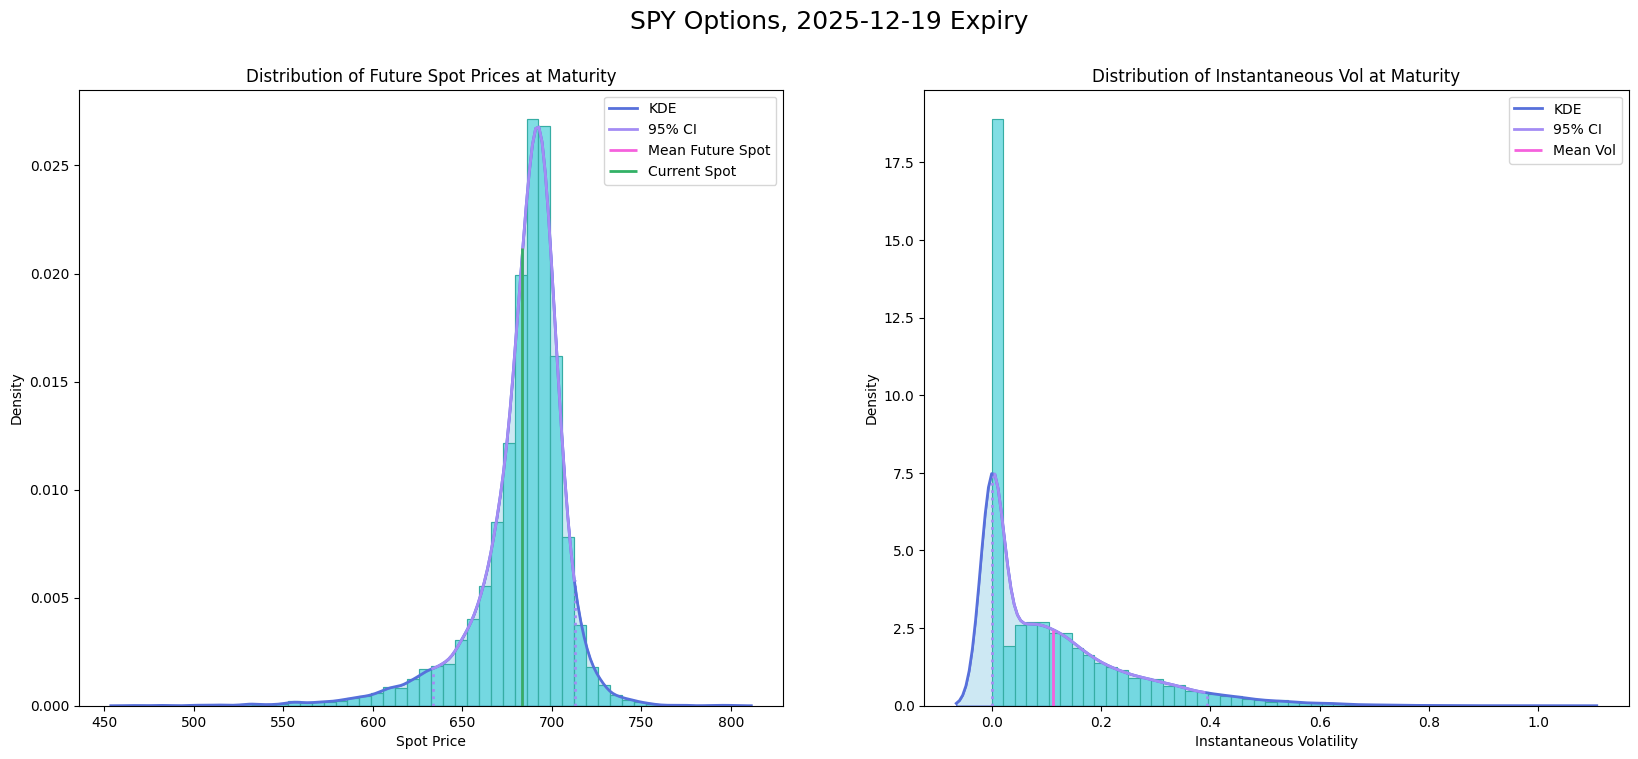

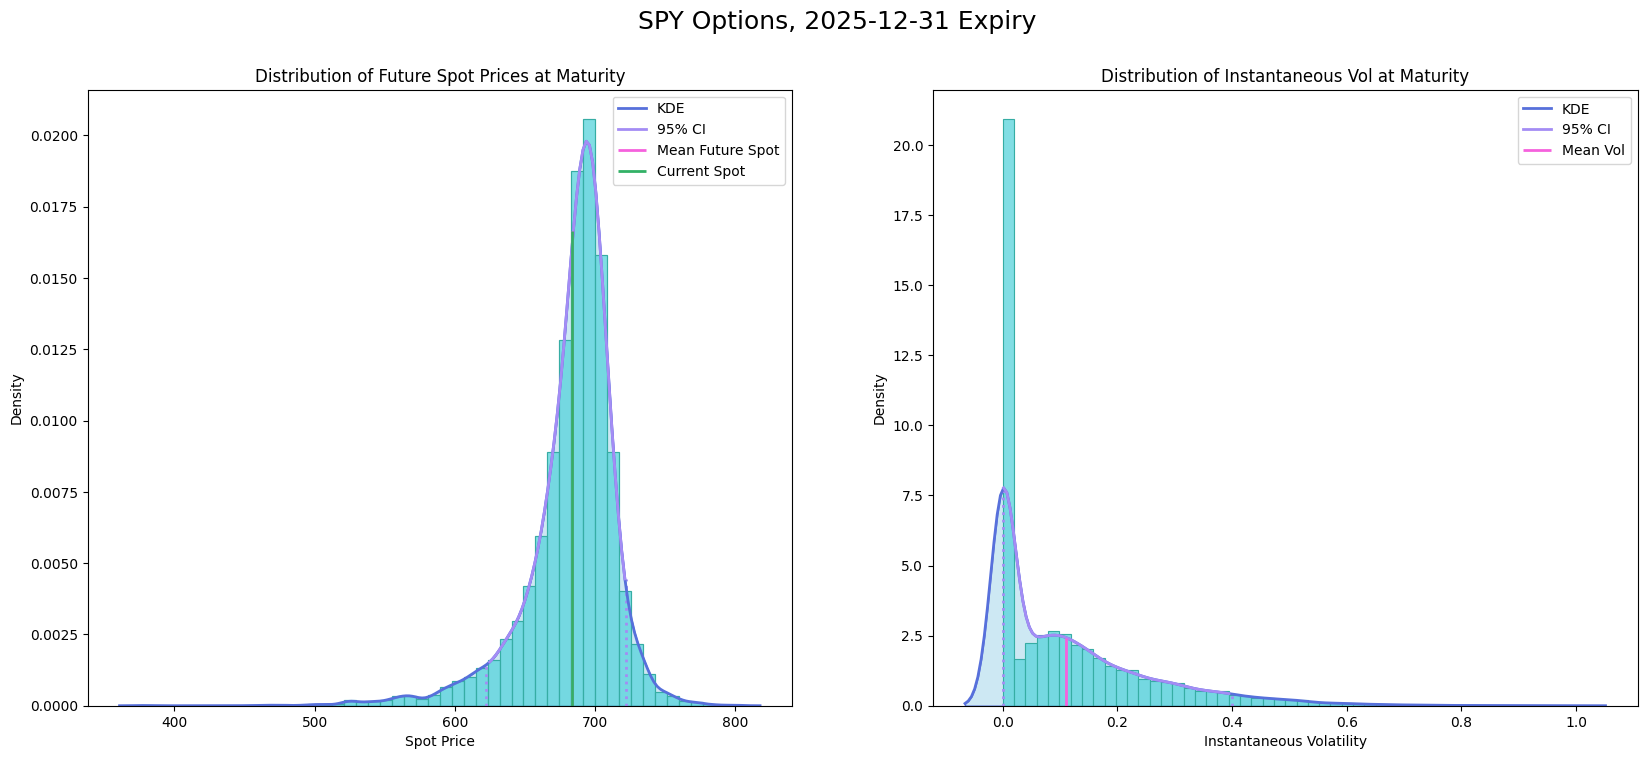

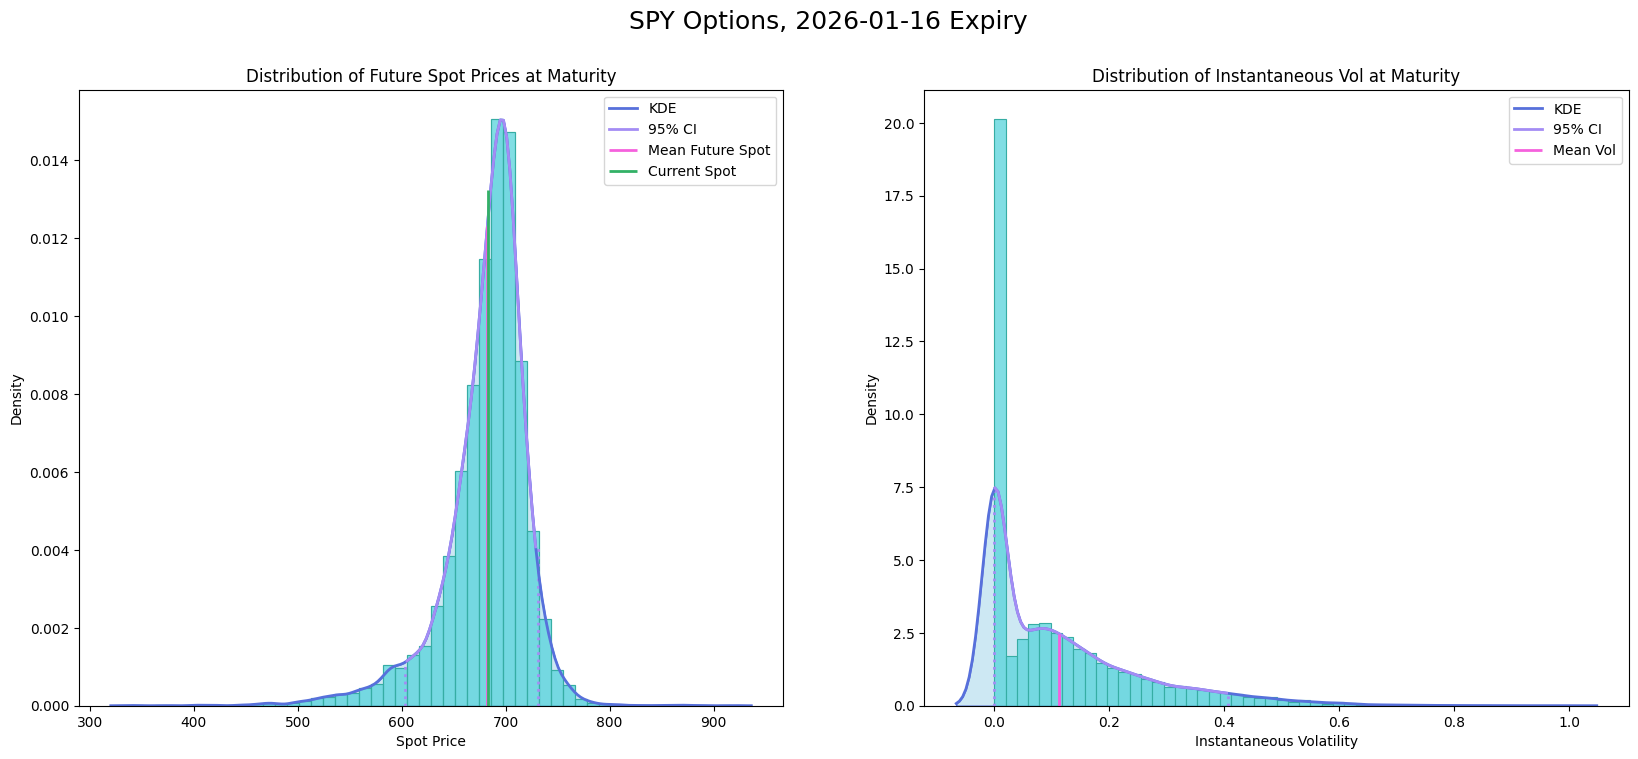

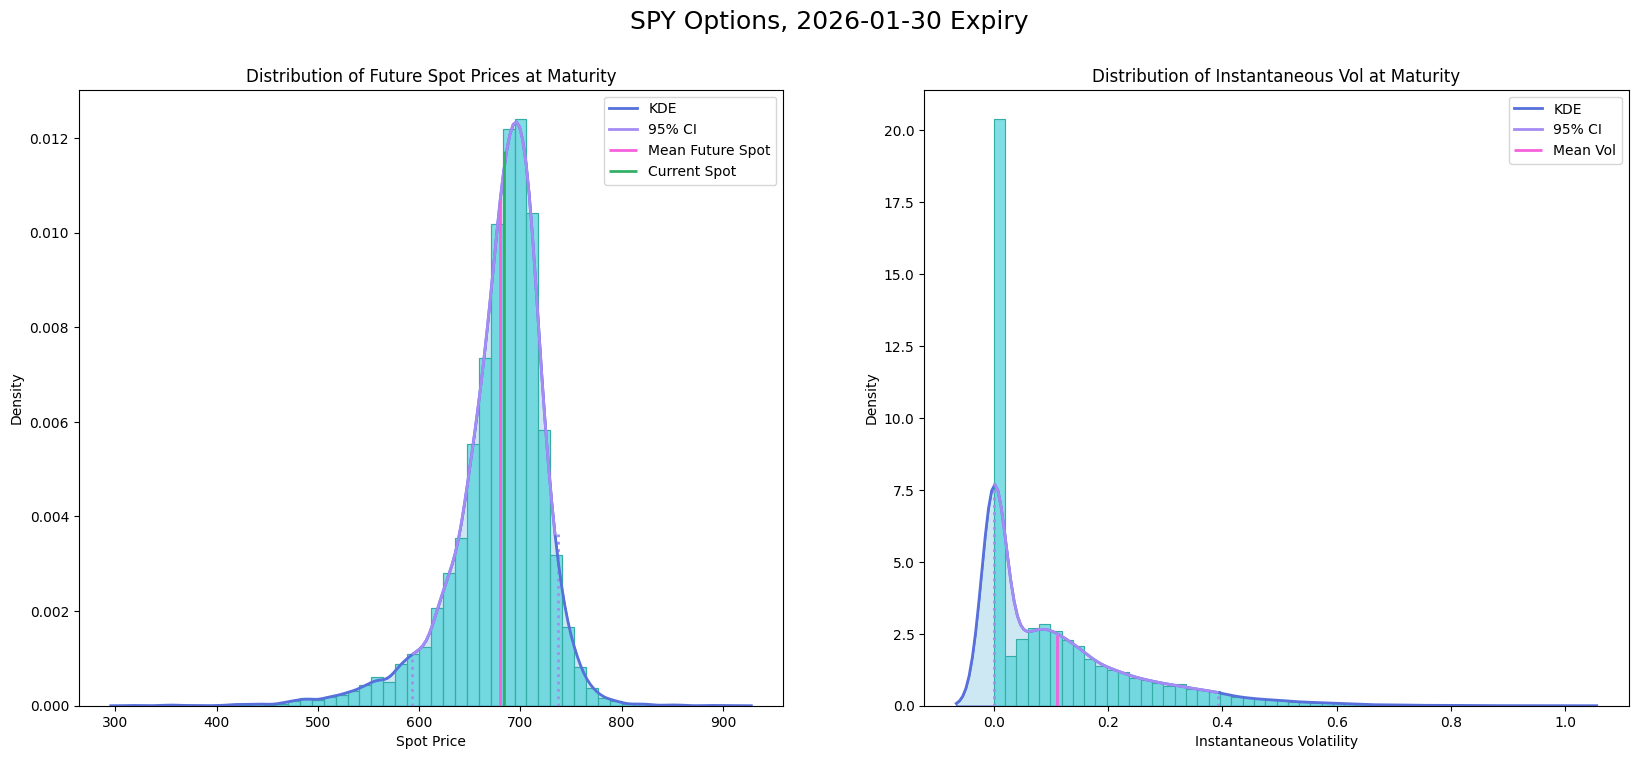

In [13]:
for liq_expiry in most_liquid_expiries: 
    plot_distr_at_maturity(S_T_by_exp[liq_expiry], sigma_T_by_exp[liq_expiry], S0, TICKER, liq_expiry, OPTION_TYPE)

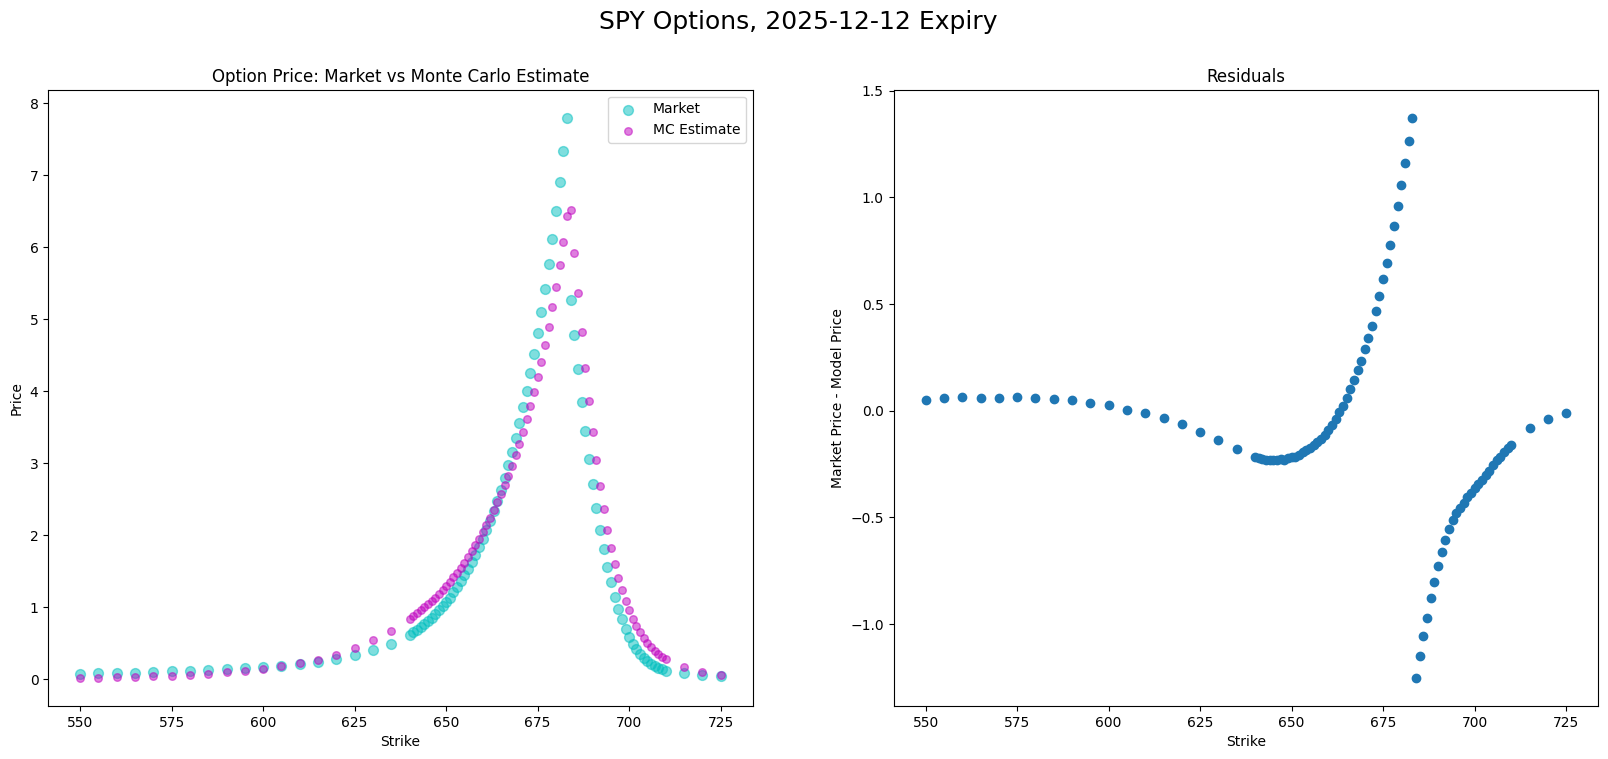

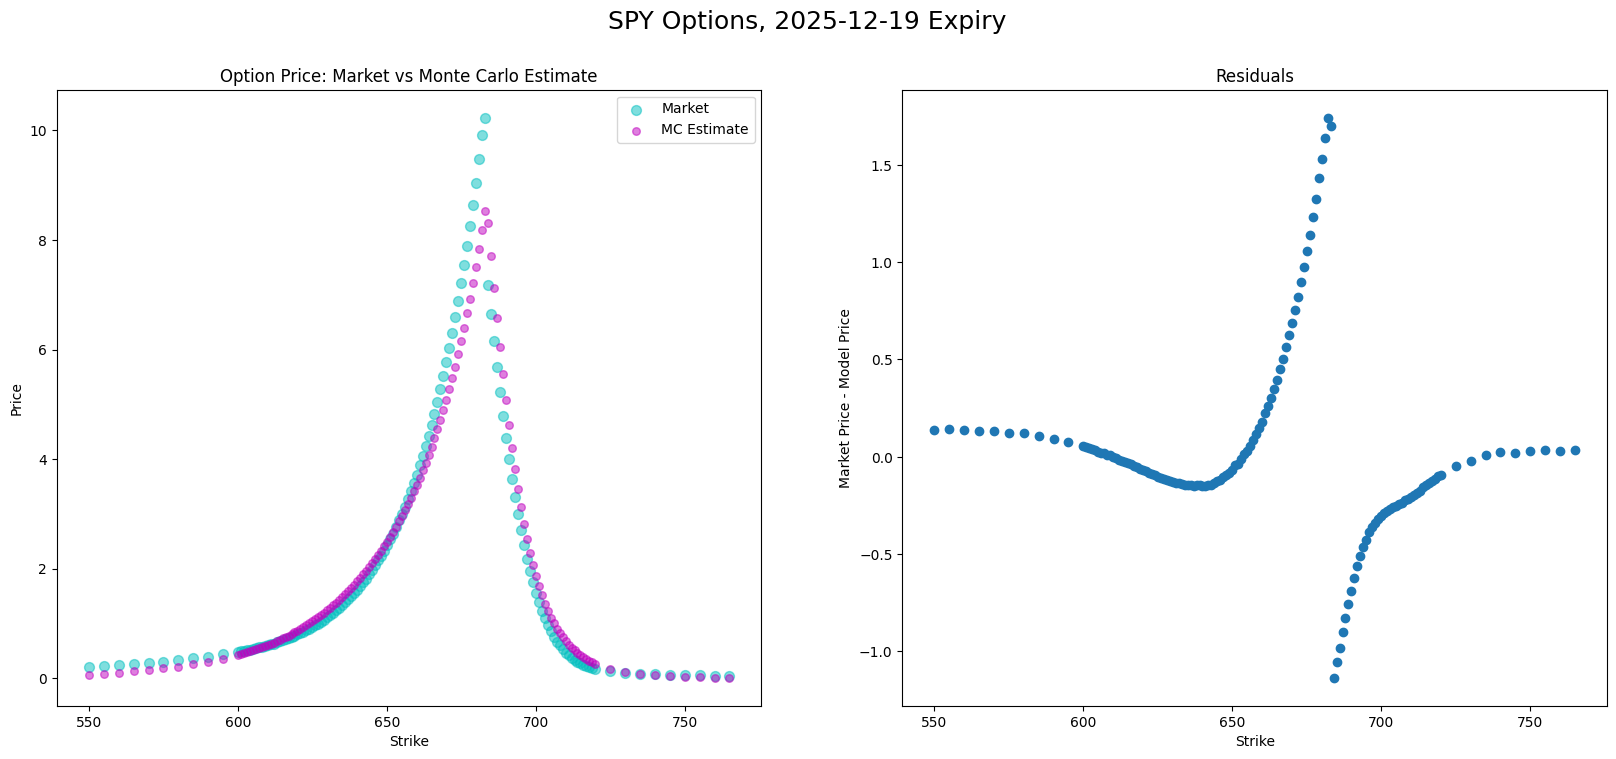

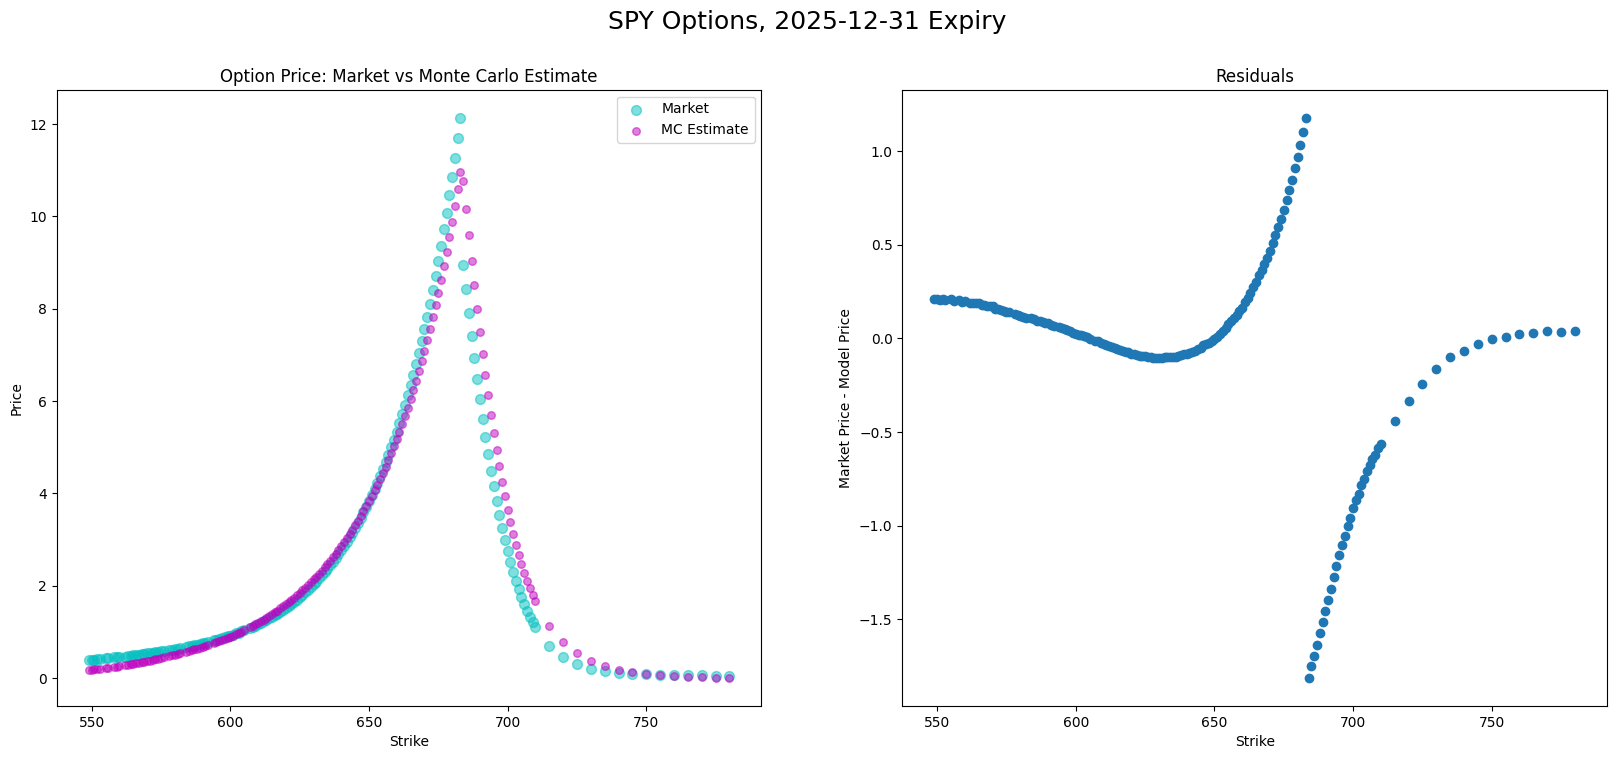

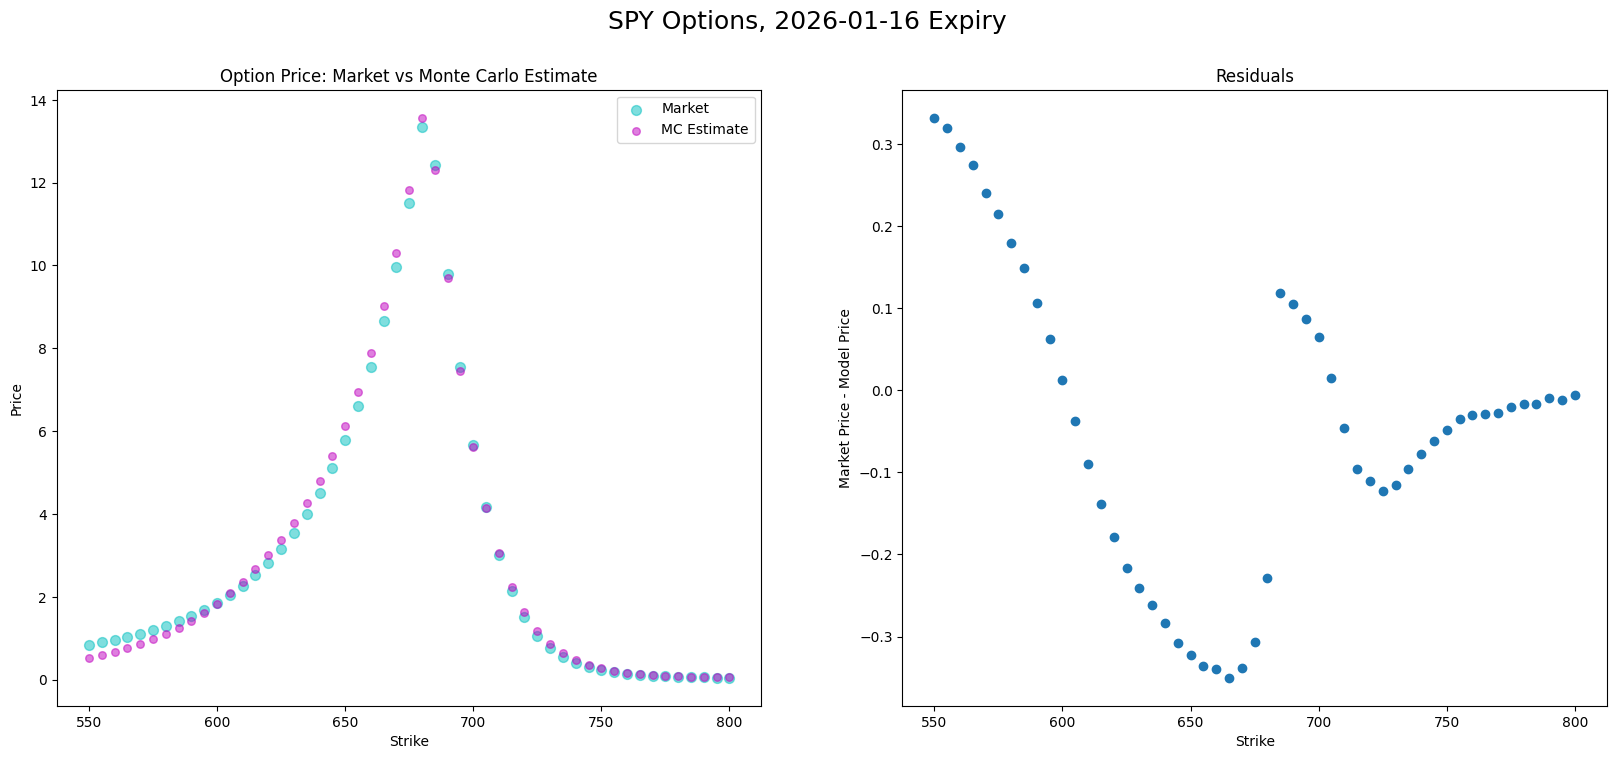

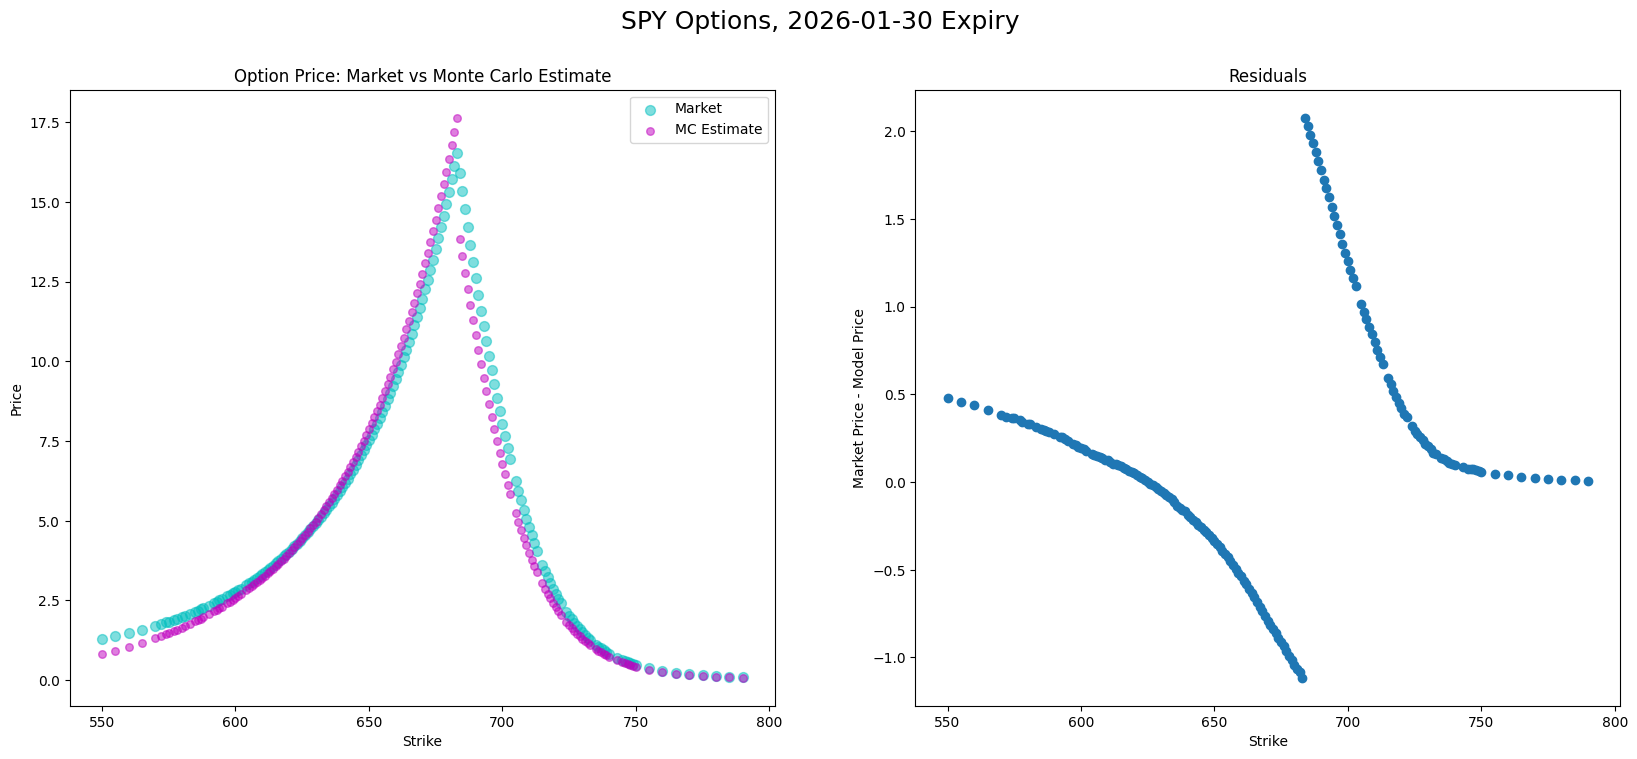

In [14]:
for liq_expiry in most_liquid_expiries: 
    plot_mc_est_prices(mc_est_by_exp[liq_expiry], TICKER, liq_expiry, OPTION_TYPE)

## Most Liquid Call Expiries

### Calibrate Heston

In [ ]:
# ---------- Input Arguments ----------

option_chain_df = liq_calls_df
NUM_EXPIRIES = N_LIQ_EXP
OPTION_TYPE = "c"

# ---------- Calibrate Heston ----------

# Compute Option Greeks
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)
option_chain_df = compute_greeks_and_bs_price(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve)

# Calibration weighting
option_chain_df = calibration_weighting(option_chain_df, LAMBDA_WING)
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)

# Initial Heston Parameter Seeds
atm_option_chain_df = option_chain_df[(option_chain_df["moneyness_spot"] >= 0.95) & 
                                      (option_chain_df["moneyness_spot"] <= 1.05)].copy()
atm_iv  = float(atm_option_chain_df["iv_mkt"].median())

KAPPA_SEED  = 2.0                               # [0.05, 30]
THETA_SEED  = max(1e-4, (atm_iv * 1.1) ** 2)    # [1e-6, 2]
SIGMA_SEED  = 0.5                               # [0.05, 5.00]
RHO_SEED    = -0.5                              # [-0.999, -1e-3]
V0_SEED     = max(1e-4, atm_iv ** 2)            # [1e-6, 1.0]
HESTON_PARAM_SEEDS = [KAPPA_SEED, THETA_SEED, SIGMA_SEED, RHO_SEED, V0_SEED]

# Fit Heston Model
heston_params, params_ci, std_errors = fit_heston_ls(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve, 
                                                     HESTON_PARAM_SEEDS, PARAM_LB, PARAM_UB, CI_ALPHA) 
kappa, theta, sigma, rho, v0 = heston_params
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()

# Compute Model Prices & IV
option_chain_df = compute_model_prices_and_ivs(option_chain_df, heston_pricing_engine, today, S_quote, r_curve, q_curve)
option_chain_df = compute_residuals(option_chain_df)
rmse_price = compute_price_rmse(option_chain_df) 

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f},   \n          [{float(params_ci["kappa"][0]):.4f}, {float(params_ci["kappa"][1]):.4f}]")
print(f"  theta = {float(theta):.8f},   \n          [{float(params_ci["theta"][0]):.4f}, {float(params_ci["theta"][1]):.4f}]")
print(f"  sigma = {float(sigma):.8f},   \n          [{float(params_ci["sigma"][0]):.4f}, {float(params_ci["sigma"][1]):.4f}]")
print(f"  rho   = {float(rho):.8f},     \n          [{float(params_ci["rho"][0]):.4f}, {float(params_ci["rho"][1]):.4f}]")
print(f"  v0    = {float(v0):.8f},      \n          [{float(params_ci["v0"][0]):.4f}, {float(params_ci["v0"][1]):.4f}]")

#### Plots

In [ ]:
plot_model_prices(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE)

In [ ]:
for liq_expiry in most_liquid_call_expiries: 
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]
    plot_model_prices(exp_option_chain_df, TICKER, 1, OPTION_TYPE, liq_expiry)

In [ ]:
plot_model_iv(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE)

In [ ]:
for liq_expiry in most_liquid_call_expiries: 
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]
    plot_model_iv(exp_option_chain_df, TICKER, 1, OPTION_TYPE, liq_expiry)

### Simulate Volatility Paths

In [ ]:
time_grids_by_exp = {}
S_paths_by_exp = {}
S_path_quantiles_by_exp = {}
v_paths_by_exp = {}
v_path_quantiles_by_exp = {}
vol_paths_by_exp = {}
vol_path_quantiles_by_exp = {}
S_T_by_exp = {}
sigma_T_by_exp = {}
mc_est_by_exp = {}

for liq_expiry in most_liquid_call_expiries: 
    
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]

    # ---------- Simulate Volatility Paths from Calibrated Heston ----------

    # Simulation horizon
    T_sim = float(exp_option_chain_df["T"].max())
    
    # Trading days to expiry
    trading_days_to_exp = int(exp_option_chain_df["trading_days_to_exp"].max())

    # Monte Carlo settings
    N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
    N_PATHS_MC = 10000                              # number of simulated paths

    # Simulate under today’s calibrated risk-neutral Heston dynamics
    time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
    vol_paths = np.sqrt(v_paths)
    time_grids_by_exp[liq_expiry] = time_grid
    S_paths_by_exp[liq_expiry] = S_paths
    v_paths_by_exp[liq_expiry] = v_paths
    vol_paths_by_exp[liq_expiry] = vol_paths

    # Simulated spot prices and instantaneous vol at maturity
    S_T = S_paths[:, -1]
    S_T_by_exp[liq_expiry] = S_T
    sigma_T = vol_paths[:, -1]
    sigma_T_by_exp[liq_expiry] = sigma_T

    # ---------- Monte Carlo Option Price Estimates & CI ----------

    exp_option_chain_df = est_mc_option_prices(exp_option_chain_df, S_T, T_sim, r_curve, N_PATHS_MC, 1 - CI_ALPHA)
    mc_est_by_exp[liq_expiry] = exp_option_chain_df

    # ---------- 5%–95% Quantile Bands for Simulated Paths ----------

    # Spot price paths
    S_path_p05 = np.percentile(S_paths, 5, axis = 0)
    S_path_p50 = np.percentile(S_paths, 50, axis = 0)
    S_path_p95 = np.percentile(S_paths, 95, axis = 0)
    S_path_quantiles = (S_path_p05, S_path_p50, S_path_p95)
    S_path_quantiles_by_exp[liq_expiry] = S_path_quantiles

    # Variance paths
    v_path_p05 = np.percentile(v_paths, 5, axis = 0)
    v_path_p50 = np.percentile(v_paths, 50, axis = 0)
    v_path_p95 = np.percentile(v_paths, 95, axis = 0)
    v_path_quantiles = (v_path_p05, v_path_p50, v_path_p95)
    v_path_quantiles_by_exp[liq_expiry] = v_path_quantiles

    # Volatility paths
    vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
    vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
    vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)
    vol_path_quantiles = (vol_path_p05, vol_path_p50, vol_path_p95)
    vol_path_quantiles_by_exp[liq_expiry] = vol_path_quantiles

#### Plots

In [ ]:
for liq_expiry in most_liquid_call_expiries: 
    plot_sim_paths(time_grids_by_exp[liq_expiry], S_paths_by_exp[liq_expiry], v_paths_by_exp[liq_expiry], 
                   S_path_quantiles_by_exp[liq_expiry], v_path_quantiles_by_exp[liq_expiry], 
                   TICKER, liq_expiry, OPTION_TYPE)

In [ ]:
for liq_expiry in most_liquid_call_expiries: 
    plot_distr_at_maturity(S_T_by_exp[liq_expiry], sigma_T_by_exp[liq_expiry], S0, TICKER, liq_expiry, OPTION_TYPE)

In [ ]:
for liq_expiry in most_liquid_call_expiries: 
    plot_mc_est_prices(mc_est_by_exp[liq_expiry], TICKER, liq_expiry, OPTION_TYPE)

## Most Liquid Put Expiries

### Calibrate Heston

In [ ]:
# ---------- Input Arguments ----------

option_chain_df = liq_puts_df
NUM_EXPIRIES = N_LIQ_EXP
OPTION_TYPE = "p"

# ---------- Calibrate Heston ----------

# Compute Option Greeks
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)
option_chain_df = compute_greeks_and_bs_price(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve)

# Calibration weighting
option_chain_df = calibration_weighting(option_chain_df, LAMBDA_WING)
vanilla_options_list = build_vanilla_instruments(option_chain_df, today)

# Initial Heston Parameter Seeds
atm_option_chain_df = option_chain_df[(option_chain_df["moneyness_spot"] >= 0.95) & 
                                      (option_chain_df["moneyness_spot"] <= 1.05)].copy()
atm_iv  = float(atm_option_chain_df["iv_mkt"].median())

KAPPA_SEED  = 2.0                               # [0.05, 30]
THETA_SEED  = max(1e-4, (atm_iv * 1.1) ** 2)    # [1e-6, 2]
SIGMA_SEED  = 0.5                               # [0.05, 5.00]
RHO_SEED    = -0.5                              # [-0.999, -1e-3]
V0_SEED     = max(1e-4, atm_iv ** 2)            # [1e-6, 1.0]
HESTON_PARAM_SEEDS = [KAPPA_SEED, THETA_SEED, SIGMA_SEED, RHO_SEED, V0_SEED]

# Fit Heston Model
heston_params, params_ci, std_errors = fit_heston_ls(option_chain_df, vanilla_options_list, S_quote, r_curve, q_curve, 
                                                     HESTON_PARAM_SEEDS, PARAM_LB, PARAM_UB, CI_ALPHA) 
kappa, theta, sigma, rho, v0 = heston_params
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()

# Compute Model Prices & IV
option_chain_df = compute_model_prices_and_ivs(option_chain_df, heston_pricing_engine, today, S_quote, r_curve, q_curve)
option_chain_df = compute_residuals(option_chain_df)
rmse_price = compute_price_rmse(option_chain_df) 

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f},   \n          [{float(params_ci["kappa"][0]):.4f}, {float(params_ci["kappa"][1]):.4f}]")
print(f"  theta = {float(theta):.8f},   \n          [{float(params_ci["theta"][0]):.4f}, {float(params_ci["theta"][1]):.4f}]")
print(f"  sigma = {float(sigma):.8f},   \n          [{float(params_ci["sigma"][0]):.4f}, {float(params_ci["sigma"][1]):.4f}]")
print(f"  rho   = {float(rho):.8f},     \n          [{float(params_ci["rho"][0]):.4f}, {float(params_ci["rho"][1]):.4f}]")
print(f"  v0    = {float(v0):.8f},      \n          [{float(params_ci["v0"][0]):.4f}, {float(params_ci["v0"][1]):.4f}]")

#### Plots

In [ ]:
plot_model_prices(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE)

In [ ]:
for liq_expiry in most_liquid_put_expiries: 
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]
    plot_model_prices(exp_option_chain_df, TICKER, 1, OPTION_TYPE, liq_expiry)

In [ ]:
plot_model_iv(option_chain_df, TICKER, NUM_EXPIRIES, OPTION_TYPE)

In [ ]:
for liq_expiry in most_liquid_put_expiries: 
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]
    plot_model_iv(exp_option_chain_df, TICKER, 1, OPTION_TYPE, liq_expiry)

### Simulate Volatility Paths

In [ ]:
time_grids_by_exp = {}
S_paths_by_exp = {}
S_path_quantiles_by_exp = {}
v_paths_by_exp = {}
v_path_quantiles_by_exp = {}
vol_paths_by_exp = {}
vol_path_quantiles_by_exp = {}
S_T_by_exp = {}
sigma_T_by_exp = {}
mc_est_by_exp = {}

for liq_expiry in most_liquid_put_expiries: 
    
    exp_option_chain_df = option_chain_df[option_chain_df["expiry"] == liq_expiry]

    # ---------- Simulate Volatility Paths from Calibrated Heston ----------

    # Simulation horizon
    T_sim = float(exp_option_chain_df["T"].max())
    
    # Trading days to expiry
    trading_days_to_exp = int(exp_option_chain_df["trading_days_to_exp"].max())

    # Monte Carlo settings
    N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
    N_PATHS_MC = 10000                              # number of simulated paths

    # Simulate under today’s calibrated risk-neutral Heston dynamics
    time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
    vol_paths = np.sqrt(v_paths)
    time_grids_by_exp[liq_expiry] = time_grid
    S_paths_by_exp[liq_expiry] = S_paths
    v_paths_by_exp[liq_expiry] = v_paths
    vol_paths_by_exp[liq_expiry] = vol_paths

    # Simulated spot prices and instantaneous vol at maturity
    S_T = S_paths[:, -1]
    S_T_by_exp[liq_expiry] = S_T
    sigma_T = vol_paths[:, -1]
    sigma_T_by_exp[liq_expiry] = sigma_T

    # ---------- Monte Carlo Option Price Estimates & CI ----------

    exp_option_chain_df = est_mc_option_prices(exp_option_chain_df, S_T, T_sim, r_curve, N_PATHS_MC, 1 - CI_ALPHA)
    mc_est_by_exp[liq_expiry] = exp_option_chain_df

    # ---------- 5%–95% Quantile Bands for Simulated Paths ----------

    # Spot price paths
    S_path_p05 = np.percentile(S_paths, 5, axis = 0)
    S_path_p50 = np.percentile(S_paths, 50, axis = 0)
    S_path_p95 = np.percentile(S_paths, 95, axis = 0)
    S_path_quantiles = (S_path_p05, S_path_p50, S_path_p95)
    S_path_quantiles_by_exp[liq_expiry] = S_path_quantiles

    # Variance paths
    v_path_p05 = np.percentile(v_paths, 5, axis = 0)
    v_path_p50 = np.percentile(v_paths, 50, axis = 0)
    v_path_p95 = np.percentile(v_paths, 95, axis = 0)
    v_path_quantiles = (v_path_p05, v_path_p50, v_path_p95)
    v_path_quantiles_by_exp[liq_expiry] = v_path_quantiles

    # Volatility paths
    vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
    vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
    vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)
    vol_path_quantiles = (vol_path_p05, vol_path_p50, vol_path_p95)
    vol_path_quantiles_by_exp[liq_expiry] = vol_path_quantiles

#### Plots

In [ ]:
for liq_expiry in most_liquid_put_expiries: 
    plot_sim_paths(time_grids_by_exp[liq_expiry], S_paths_by_exp[liq_expiry], v_paths_by_exp[liq_expiry], 
                   S_path_quantiles_by_exp[liq_expiry], v_path_quantiles_by_exp[liq_expiry], 
                   TICKER, liq_expiry, OPTION_TYPE)

In [ ]:
for liq_expiry in most_liquid_put_expiries: 
    plot_distr_at_maturity(S_T_by_exp[liq_expiry], sigma_T_by_exp[liq_expiry], S0, TICKER, liq_expiry, OPTION_TYPE)

In [ ]:
for liq_expiry in most_liquid_put_expiries: 
    plot_mc_est_prices(mc_est_by_exp[liq_expiry], TICKER, liq_expiry, OPTION_TYPE)